In [94]:

import warnings
warnings.filterwarnings("ignore")

import pickle
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.dates as mdates
from matplotlib.patches import Circle
from matplotlib.lines import Line2D


import seaborn as sns

from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import squareform
from scipy.stats import norm

from joblib import Parallel, delayed

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

import shap

from sklearn.base import BaseEstimator
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier
from sklearn.metrics import (
    f1_score,
    roc_auc_score,
    log_loss,
    average_precision_score,
)
from sklearn.tree import DecisionTreeClassifier



# Walk-Forward Purged K-Fold CV

---

### Проблема обычного K-Fold в финансах

```
Стандартный K-Fold:
fold 1: [train][TEST][train]  ← train из БУДУЩЕГО
fold 2: [train][TEST][train]  ← leakage

Purged K-Fold по dePrado:
fold 1: [train][TEST][train]  ← purge убирает overlap
                               ← но train всё ещё из будущего!
```

Обе схемы нарушают временную причинность —
модель видит данные которые были бы недоступны
в момент принятия торгового решения.

---

### Решение — Expanding Window Walk-Forward CV

```
fold 1: [=====train=====][purge][test][embargo]
fold 2: [========train========][purge][test][embargo]
fold 3: [===========train===========][purge][test][embargo]
fold 4: [==============train==============][purge][test][embargo]
fold 5: [=================train=================][purge][test][embargo]
```

Train всегда только из прошлого.
Каждый следующий fold добавляет предыдущий test в train.
Это точная имитация реальной торговли.

---

### Три механизма защиты от leakage

**1. Expanding window** — нет данных из будущего в train:
```
train_i = все данные от начала до test_i
```

**2. Purge** — убираем из train наблюдения чьи метки
перекрываются с началом test:
```
если t1[train_j] > t0[test_первый]:
    убираем train_j из обучения
```
Наши метки имеют горизонт 1 день (~48 баров).
Значит purge убирает ~48 баров перед test.

**3. Embargo** — убираем первые h баров train
которые идут после test (для Rolling CV неактуально,
но оставляем для корректности):
```
h = pct_embargo * N  ≈ 0.01 * 122061 ≈ 1220 баров (~25 дней)
```

---

### Разбивка на фолды для нашего датасета

```
Период данных: 2020-03-26 → 2026-04-01 (~6 лет)
N баров:       122,061

Минимальный train: 1 год (~17,000 баров)
Test размер:       6 месяцев (~8,500 баров)
Шаг:               6 месяцев
```

| Fold | Train начало | Train конец | Test начало | Test конец |
|------|-------------|-------------|-------------|------------|
| 1 | 2020-03 | 2021-03 | 2021-03 | 2021-09 |
| 2 | 2020-03 | 2021-09 | 2021-09 | 2022-03 |
| 3 | 2020-03 | 2022-03 | 2022-03 | 2022-09 |
| 4 | 2020-03 | 2022-09 | 2022-09 | 2023-03 |
| 5 | 2020-03 | 2023-03 | 2023-03 | 2023-09 |
| 6 | 2020-03 | 2023-09 | 2023-09 | 2024-03 |
| 7 | 2020-03 | 2024-03 | 2024-03 | 2024-09 |
| 8 | 2020-03 | 2024-09 | 2024-09 | 2025-03 |
| 9 | 2020-03 | 2025-03 | 2025-03 | 2025-09 |
| 10 | 2020-03 | 2025-09 | 2025-09 | 2026-04 |

---

### Режимы рынка в фолдах

```
Fold 1-2:  Режим 1→2 (ранний + начало институционального)
Fold 3-5:  Режим 2 (институциональный bull/bear цикл)
Fold 6-7:  Режим 2→3 (переход, ETF approval)
Fold 8-9:  Режим 3 (пост-ETF)
```

Это важно — каждый fold проверяет модель
на принципиально разном рыночном режиме.

---

### Sklearn-совместимый класс

Реализуем как `WalkForwardPurgedCV` совместимый
с sklearn API — метод `split(X, y, groups)`:

```python
cv = WalkForwardPurgedCV(
    n_splits    = 9,
    min_train_size = 0.15,   # минимум 15% данных в train
    test_size   = 1/12,      # ~6 месяцев
    pct_embargo = 0.01,      # 1% embargo
)

for train_idx, test_idx in cv.split(X, y, t1=df['t1']):
    X_train = X.iloc[train_idx]
    X_test  = X.iloc[test_idx]
    ...
```

---

### Как используется при обучении

```python
scores = []

for train_idx, test_idx in cv.split(X, y, t1=df['t1']):

    model.fit(
        X.iloc[train_idx],
        y.iloc[train_idx],
        sample_weight = w.iloc[train_idx]  # ← наши w_final
    )

    pred = model.predict(X.iloc[test_idx])
    scores.append(f1_score(y.iloc[test_idx], pred))

print(f"CV F1: {np.mean(scores):.4f} ± {np.std(scores):.4f}")
```

---

### Что получаем на выходе

```
9 независимых оценок качества модели
→ mean F1 и std F1

Если std F1 высокий → модель нестабильна по режимам
Если fold 8-9 (пост-ETF) сильно хуже fold 3-5 →
    модель не адаптируется к новому режиму →
    нужен time decay или переобучение только на свежих данных
```



Фолдов: 5
  F1: train 2020-03-26→2021-03-09 (23,750)  test 2021-03-10→2021-12-10 (15,257)  purged=52  Режим 2
  F2: train 2020-03-26→2022-03-16 (44,443)  test 2022-03-16→2023-01-12 (15,257)  purged=109  Режим 2
  F3: train 2020-03-26→2023-03-29 (65,226)  test 2023-03-29→2024-01-10 (15,257)  purged=76  Режим 3
  F4: train 2020-03-26→2024-04-09 (85,974)  test 2024-04-10→2025-02-06 (15,257)  purged=78  Режим 3
  F5: train 2020-03-26→2025-05-23 (106,711)  test 2025-05-23→2026-04-01 (15,257)  purged=91  Режим 3


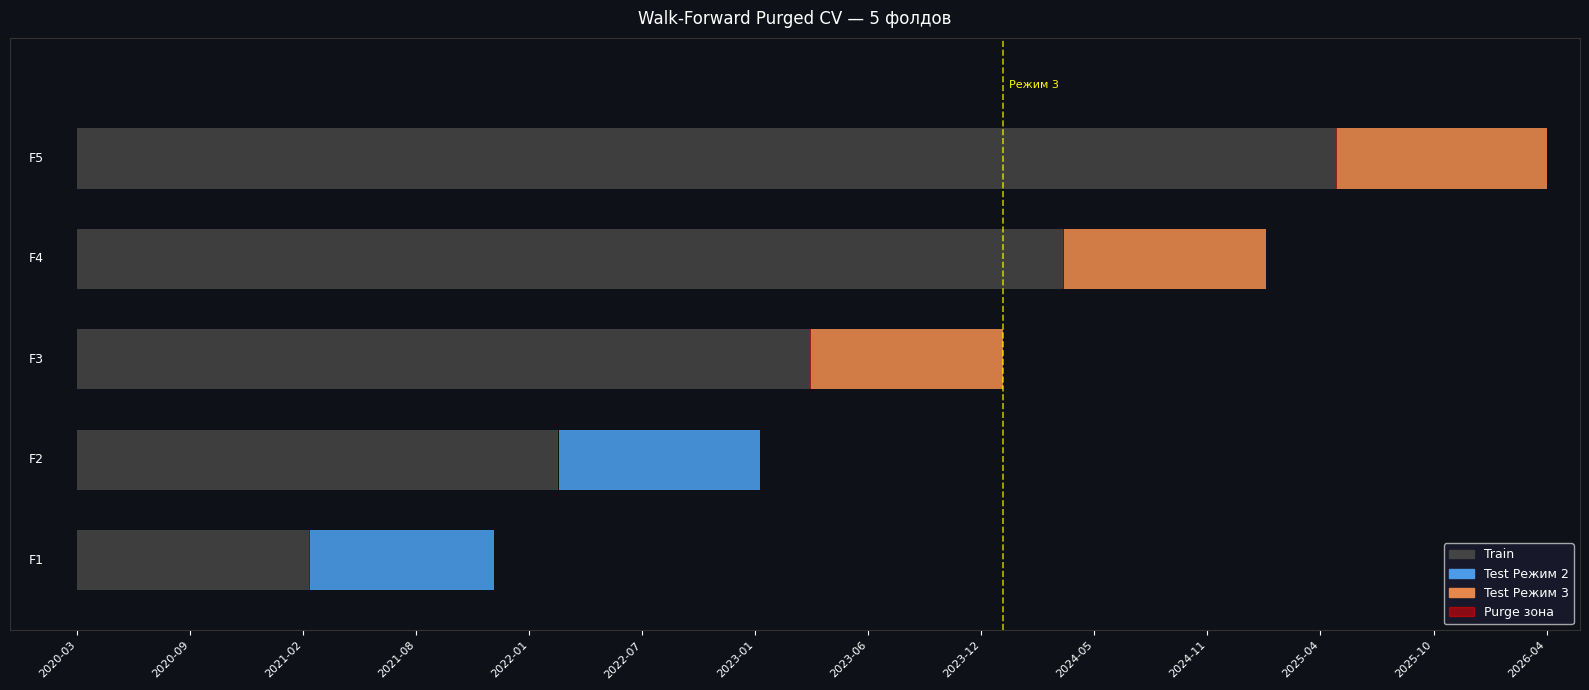

In [2]:

BARS_DIR = Path("data/bars")

df = pd.read_parquet(BARS_DIR / "dataset_v5.parquet")
df.index = pd.to_datetime(df.index)


class WalkForwardPurgedCV(BaseEstimator):

    def __init__(self, n_splits=5, min_train_pct=0.15,
                 test_pct=1/20, pct_embargo=0.01):
        self.n_splits      = n_splits
        self.min_train_pct = min_train_pct
        self.test_pct      = test_pct
        self.pct_embargo   = pct_embargo

    def split(self, X, y=None, t1=None):
        N         = len(X)
        test_size = max(1, int(N * self.test_pct))
        min_train = max(1, int(N * self.min_train_pct))
        embargo_n = max(1, int(N * self.pct_embargo))

        total_test_range = N - min_train
        step = max(1, total_test_range // self.n_splits)

        if t1 is not None:
            t1_clean = pd.to_datetime(t1)
            if t1_clean.dt.tz is not None:
                t1_clean = t1_clean.dt.tz_localize(None)
            t1_arr = t1_clean.values
        else:
            t1_arr = None

        idx = pd.to_datetime(X.index)
        if idx.tz is not None:
            idx = idx.tz_localize(None)
        idx_arr = idx.values

        for i in range(self.n_splits):
            test_end   = min(min_train + (i + 1) * step, N)
            test_start = max(min_train, test_end - test_size)

            if test_start >= test_end:
                continue

            test_idx         = np.arange(test_start, test_end)
            train_candidates = np.arange(0, test_start)

            if t1_arr is not None and len(train_candidates) > 0:
                t0_test    = idx_arr[test_start]
                t1_train   = t1_arr[train_candidates]
                purge_mask = t1_train >= t0_test
                train_idx  = train_candidates[~purge_mask]
            else:
                train_idx = train_candidates

            if len(train_idx) == 0 or len(test_idx) == 0:
                continue

            yield train_idx, test_idx

    def get_n_splits(self, X=None, y=None, groups=None):
        return self.n_splits


cv = WalkForwardPurgedCV(
    n_splits      = 5,
    min_train_pct = 0.15,
    test_pct      = 1/8,
    pct_embargo   = 0.005,
)

t1_series = pd.to_datetime(df["t1"])
if t1_series.dt.tz is not None:
    t1_series = t1_series.dt.tz_localize(None)
t1_series.index = df.index

fold_info = []
for i, (train_idx, test_idx) in enumerate(cv.split(df, t1=t1_series)):
    train_start = df.index[train_idx[0]].date()
    train_end   = df.index[train_idx[-1]].date()
    test_start  = df.index[test_idx[0]].date()
    test_end    = df.index[test_idx[-1]].date()
    purged_n    = test_idx[0] - len(train_idx)

    regime = ("Режим 2" if test_end < pd.Timestamp("2024-01-10").date()
              else "Режим 3")

    fold_info.append({
        "fold":        i + 1,
        "train_start": train_start,
        "train_end":   train_end,
        "test_start":  test_start,
        "test_end":    test_end,
        "n_train":     len(train_idx),
        "n_test":      len(test_idx),
        "purged":      purged_n,
        "regime":      regime,
        "train_idx":   train_idx,
        "test_idx":    test_idx,
    })

folds = [{"train_idx": fi["train_idx"], "test_idx": fi["test_idx"]}
         for fi in fold_info]
with open(BARS_DIR / "cv_folds.pkl", "wb") as f:
    pickle.dump(folds, f)

print(f"Фолдов: {len(fold_info)}")
for fi in fold_info:
    print(f"  F{fi['fold']}: train {fi['train_start']}→{fi['train_end']} "
          f"({fi['n_train']:,})  test {fi['test_start']}→{fi['test_end']} "
          f"({fi['n_test']:,})  purged={fi['purged']:,}  {fi['regime']}")

regime_colors = {"Режим 2": "#4C9BE8", "Режим 3": "#E8874C"}
date_min      = df.index[0]
total_days    = (df.index[-1] - date_min).days
BG            = "#0e1117"

fig, ax = plt.subplots(figsize=(16, 7))
fig.patch.set_facecolor(BG)
ax.set_facecolor(BG)

for info in fold_info:
    fp      = info["fold"]
    train_s = df.index[info["train_idx"][0]]
    train_e = df.index[info["train_idx"][-1]]
    ax.barh(fp, (train_e - train_s).days,
            left=(train_s - date_min).days,
            height=0.6, color="#444", alpha=0.9)

    test_s = df.index[info["test_idx"][0]]
    test_e = df.index[info["test_idx"][-1]]
    ax.barh(fp, (test_e - test_s).days,
            left=(test_s - date_min).days,
            height=0.6, color=regime_colors[info["regime"]], alpha=0.9)

    if info["purged"] > 0:
        ps_idx = info["test_idx"][0] - info["purged"]
        if ps_idx >= 0:
            ps = df.index[ps_idx]
            ax.barh(fp, (test_s - ps).days,
                    left=(ps - date_min).days,
                    height=0.6, color="red", alpha=0.5)

    ax.text(-50, fp, f"F{fp}", color="white", fontsize=9,
            va="center", ha="right")

x_etf = (pd.Timestamp("2024-01-10") - date_min).days
ax.axvline(x_etf, color="yellow", linewidth=1.2, linestyle="--", alpha=0.7)
ax.text(x_etf + 10, len(fold_info) + 0.7, "Режим 3",
        color="yellow", fontsize=8)

tick_days  = np.linspace(0, total_days, 14).astype(int)
tick_dates = [date_min + pd.Timedelta(days=int(d)) for d in tick_days]
ax.set_xticks(tick_days)
ax.set_xticklabels([d.strftime("%Y-%m") for d in tick_dates],
                   rotation=45, ha="right", color="white", fontsize=8)
ax.set_yticks([])
ax.set_xlim(-100, total_days + 50)
ax.set_ylim(0.3, len(fold_info) + 1.2)
ax.set_title("Walk-Forward Purged CV — 5 фолдов",
             color="white", fontsize=12, pad=10)
ax.legend(handles=[
    mpatches.Patch(color="#444",           label="Train"),
    mpatches.Patch(color="#4C9BE8",        label="Test Режим 2"),
    mpatches.Patch(color="#E8874C",        label="Test Режим 3"),
    mpatches.Patch(color="red", alpha=0.5, label="Purge зона"),
], facecolor="#1a1a2e", labelcolor="white", fontsize=9, loc="lower right")
for sp in ["top", "right", "left", "bottom"]:
    ax.spines[sp].set_color("#333")
ax.tick_params(colors="white")

plt.tight_layout()
plt.show()


## Сохранение фолдов

Сохраняем индексы train/test для каждого из 5 фолдов в `cv_folds.pkl`. Это позволяет воспроизвести точно такое же разбиение при обучении модели, отборе признаков и бэктестинге — без риска случайно получить другие фолды при повторном запуске.

In [3]:


folds = [{"train_idx": tr, "test_idx": te}
         for tr, te in cv.split(df, t1=t1_series)]

path_folds = BARS_DIR / "cv_folds.pkl"
with open(path_folds, "wb") as f:
    pickle.dump(folds, f)




# Feature Importance — архитектура

---

### Цель

В датасете ~200 признаков. Часть из них шум — они не несут
предсказательной силы и только вредят модели через
переобучение. Feature Importance позволяет отобрать
только значимые признаки перед финальным обучением.

---

### Метод 1 — MDI (Mean Decrease Impurity)

**Как работает:**

Random Forest при каждом сплите выбирает признак который
максимально уменьшает impurity (Gini или Entropy).
MDI суммирует это уменьшение по всем деревьям и нормирует.

```python
rf.fit(X_train, y_train, sample_weight=w_train)
importance = rf.feature_importances_  # встроено в sklearn
```

**Плюсы:**
- Очень быстро — считается при обучении
- Не требует дополнительных прогонов

**Минусы:**
- Substitution effects — коррелированные признаки
  делят важность между собой
- Переоценивает признаки с высокой кардинальностью
- Смещённая оценка на in-bag данных

**Используем для:** быстрого первичного скрининга.
Отсеиваем явный мусор.

---

### Метод 2 — MDA (Mean Decrease Accuracy)

**Как работает:**

```
1. Обучаем RF на train fold
2. Считаем baseline score на test fold
3. Для каждого признака:
   → перемешиваем его значения (shuffle)
   → считаем score снова
   → MDA[feature] = baseline_score - shuffled_score
4. Усредняем по всем CV фолдам
```

Shuffle разрушает связь признака с таргетом.
Если score сильно упал → признак важен.
Если score не изменился → признак бесполезен.
Если score вырос → признак вреден (добавляет шум).

**Плюсы:**
- Не зависит от структуры модели
- Может давать отрицательные значения
  (признак хуже чем случайный шум)
- Честная оценка на OOS данных

**Минусы:**
- Медленнее MDI — N_features × N_folds прогонов
- Substitution effects частично остаются

**Используем для:** основного отбора признаков.

---

### Как используем наш Walk-Forward CV

```
для каждого fold [1..10]:
    обучаем RF на train_idx с w_final весами
    считаем baseline F1 на test_idx

    для каждого признака:
        shuffle признак в test_idx
        считаем F1 снова
        MDA[feature, fold] = baseline_F1 - shuffled_F1

итоговый MDA[feature] = mean по фолдам
std MDA[feature]       = std по фолдам
```

Важно: shuffle делаем только в **test** — не трогаем train.
Это OOS оценка без leakage.

---

### Отдельные модели для Long и Short

У нас двухмодельная архитектура:

```
Long model:  y = bin_long  (0/1)
Short model: y = bin_short (0/1)
```

Feature Importance считаем отдельно для каждой модели —
признаки важные для лонга могут отличаться от признаков
важных для шорта.

---

### Признаки которые исключаем до обучения

Некоторые колонки не являются признаками:

```python
EXCLUDE_COLS = [
    # таргеты
    "bin", "bin_long", "bin_short", "t1", "ret",
    # веса
    "w", "decay", "w_final",
    # служебные
    "mult", "h_days", "n_ticks_micro",
    # сырые цены (нестационарные)
    "open", "high", "low", "close", "vwap",
    "mark_close", "index_close",
    # дубликаты
    "dollar_volume",  # уже есть в признаках
]
```

---

### Порядок реализации

```
1. Подготовка feature matrix X
   → исключаем EXCLUDE_COLS
   → fillna(0) для NaN
   → проверяем что нет inf

2. MDI — быстрый скрининг
   → обучаем RF на fold 1
   → строим график топ-50 признаков
   → убираем признаки с MDI < threshold

3. MDA — основной отбор
   → прогоняем по всем 10 фолдам
   → считаем mean ± std для каждого признака
   → строим график с error bars
   → отбираем признаки с MDA > 0

4. Финальный список признаков
   → пересечение MDI > 0 и MDA > 0
   → сохраняем в selected_features.pkl
```



---

```

# Выбор архитектуры модели

### Почему Random Forest а не Boosting

```
Bagging (RF):  уменьшает variance → борется с переобучением
Boosting:      уменьшает bias     → борется с недообучением
```

В финансах главная угроза — переобучение, а не недообучение. Причина: низкий signal-to-noise ratio. Модель легко запоминает шум вместо сигнала. Дополнительно: Boosting работает последовательно и не параллелится. **Вывод de Prado: RF предпочтительнее для финансовых задач.**

---

### Проблема стандартного RF при overlapping labels

Стандартный RF использует bootstrap с заменой. При overlapping labels (наш случай — Triple Barrier с горизонтом 1 день):

```
метки перекрываются → соседние наблюдения почти идентичны
→ bootstrap семплирует похожие наблюдения
→ все деревья строятся на почти одинаковых данных
→ ρ̄ ≈ 1 → variance не снижается → OOB accuracy завышена
```

---

### Решение — BaggingClassifier с `max_samples = avgU`

Вместо стандартного bootstrap используем `max_samples = avgU` — среднюю уникальность метки из главы 4 AFML:

```python
# Вариант 1 — стандартный (не рекомендуется)
clf = RandomForestClassifier(n_estimators=1000,
                             class_weight="balanced_subsample",
                             criterion="entropy")

# Вариант 2 — BaggingClassifier на DecisionTree с avgU
bc = BaggingClassifier(
    estimator    = DecisionTreeClassifier(criterion="entropy",
                                          class_weight="balanced"),
    n_estimators = 1000,
    max_samples  = avgU
)

# Вариант 3 — BaggingClassifier на RF с avgU (оптимальный)
bc = BaggingClassifier(
    estimator    = RandomForestClassifier(n_estimators=1,
                                          criterion="entropy",
                                          bootstrap=False,
                                          class_weight="balanced_subsample"),
    n_estimators = 1000,
    max_samples  = avgU,
    max_features = 1.0
)
```

Каждое дерево обучается на подвыборке размером `avgU × N` — реальном числе независимых наблюдений в датасете.

---

### Ключевые параметры против переобучения

```python
max_features             = "sqrt"   # декоррелирует деревья
min_weight_fraction_leaf = 0.05     # ранняя остановка, минимум 5% суммарного веса в листе
class_weight             = "balanced_subsample"  # компенсирует дисбаланс классов
max_samples              = avgU     # bootstrap = реально независимые наблюдения
criterion                = "entropy"  # чувствительнее к малым классам чем Gini
```

---

### Связь с нашими данными

```
avgU из главы 4:
  горизонт 1d (~48 баров), бары ~30m → ū_i ≈ 0.03

max_samples = avgU ≈ 0.03
  → каждое дерево на 0.03 × 122,061 ≈ 3,662 барах
  → bootstrap не дублирует информацию

sample_weight = w_final
  → взвешены по уникальности и return attribution
  → свежие данные весят больше (time decay c=0)
```

In [4]:

EXCLUDE_COLS = {
    "bin", "bin_long", "bin_short", "t1", "ret",
    "w", "decay", "w_final", "mult", "h_days", "n_ticks_micro",
    "open", "high", "low", "close", "vwap",
    "mark_close", "index_close",
    "dollar_volume", "bb_upper", "bb_lower",
    "y_trade", "w_raw", "w_from_weights",
}

y      = df["y_trade"].copy()
w_final = df["w_final"].copy()

feature_cols = [c for c in df.columns
                if c not in EXCLUDE_COLS
                and df[c].dtype in [np.float64, np.float32,
                                    np.int64, np.int32, np.int8]]

X = df[feature_cols].replace([np.inf, -np.inf], np.nan).fillna(0)

df_w  = pd.read_parquet(BARS_DIR / "sample_weights_final_c0.parquet")
avgU  = float(df_w["decay"].mean().clip(0.01, 1.0))

with open(BARS_DIR / "cv_folds.pkl", "rb") as f:
    folds = pickle.load(f)

print(f"X: {X.shape}  |  avgU: {avgU:.4f}  |  "
      f"max_samples: {int(avgU * len(X)):,}  |  фолдов: {len(folds)}")


X: (122061, 223)  |  avgU: 0.4886  |  max_samples: 59,641  |  фолдов: 5


# MDI отбор

  Fold 1: F1=0.6670
  Fold 2: F1=0.6545
  Fold 3: F1=0.6379
  Fold 4: F1=0.7256
  Fold 5: F1=0.7589

Mean F1:          0.6888 ± 0.0459
MDI > 0:          175 признаков
MDI > 1/N:        52 признаков
После MDI:        175 признаков


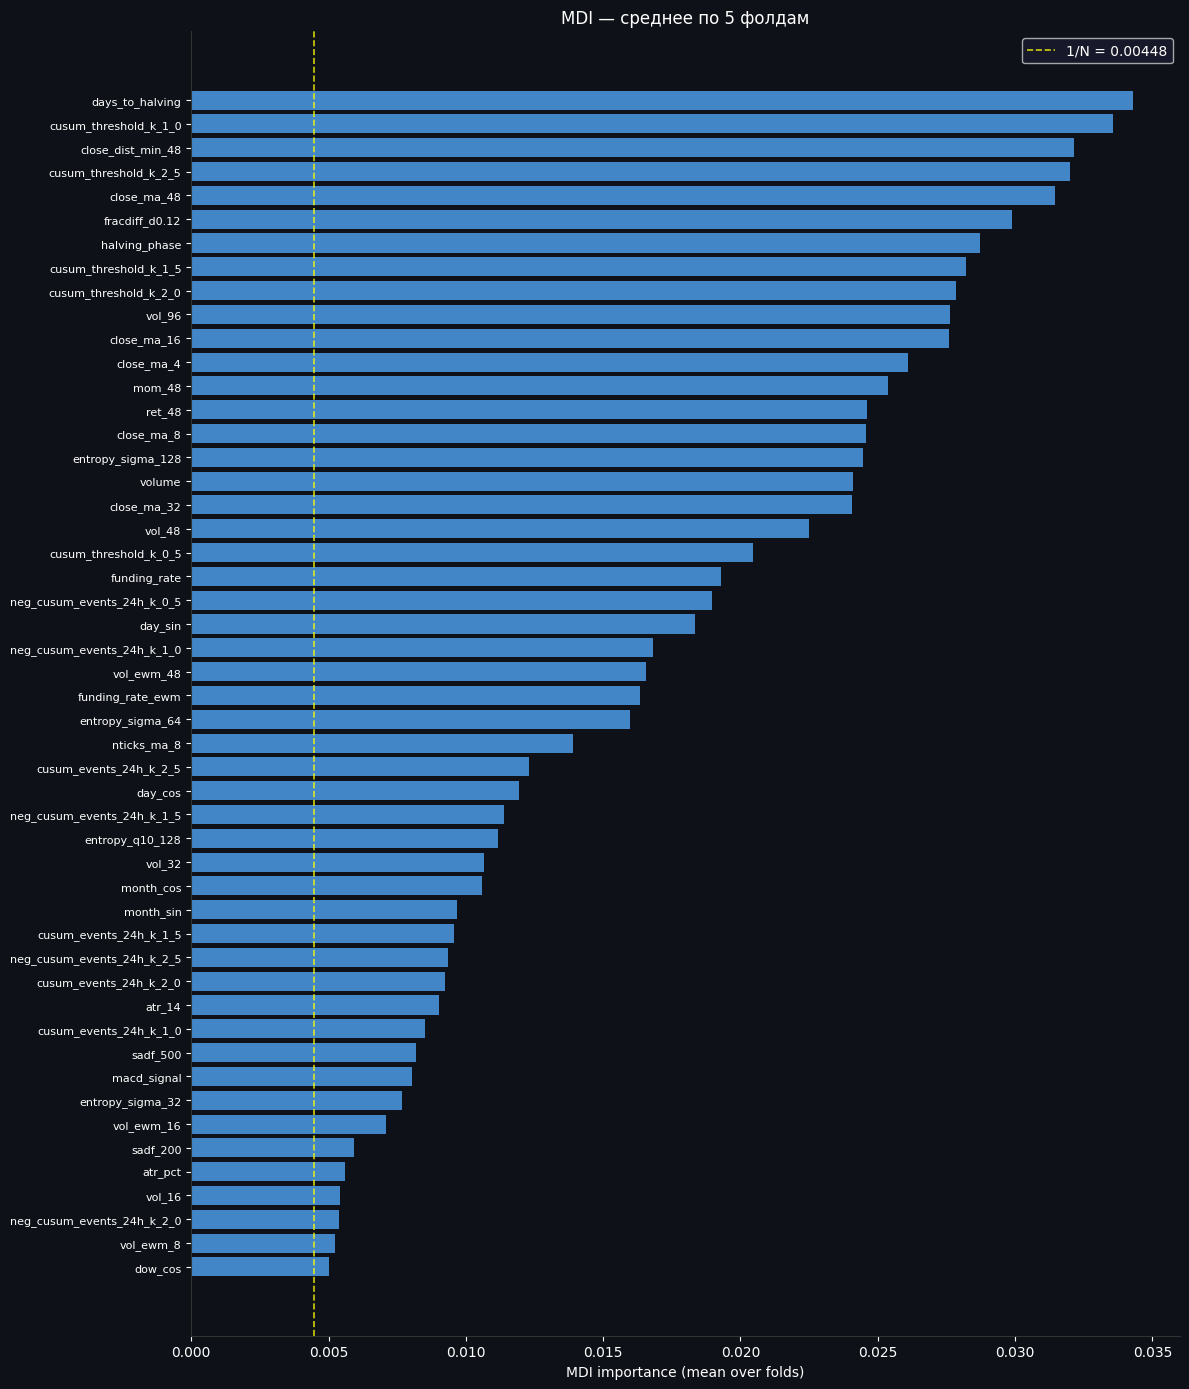

In [5]:
RF_BASE = dict(
    n_estimators             = 100,
    max_depth                = 6,
    min_weight_fraction_leaf = 0.05,
    max_features             = "sqrt",
    criterion                = "entropy",
    class_weight             = "balanced",
    bootstrap                = False,
    n_jobs                   = -1,
    random_state             = 42,
)

threshold = 1.0 / len(feature_cols)
mdi_all   = []
f1_scores = []

for i, fold in enumerate(folds):
    X_tr = X.iloc[fold["train_idx"]]
    y_tr = y.iloc[fold["train_idx"]]
    w_tr = w_final.iloc[fold["train_idx"]]
    X_te = X.iloc[fold["test_idx"]]
    y_te = y.iloc[fold["test_idx"]]

    rf = RandomForestClassifier(**RF_BASE)
    rf.fit(X_tr, y_tr, sample_weight=w_tr)

    mdi_all.append(rf.feature_importances_)
    f1_scores.append(f1_score(y_te, rf.predict(X_te), average="weighted"))
    print(f"  Fold {i+1}: F1={f1_scores[-1]:.4f}")

mdi = pd.Series(
    np.mean(mdi_all, axis=0),
    index=feature_cols
).sort_values(ascending=False)

mdi_selected = mdi[mdi > 0].index.tolist()

print(f"\nMean F1:          {np.mean(f1_scores):.4f} ± {np.std(f1_scores):.4f}")
print(f"MDI > 0:          {(mdi > 0).sum()} признаков")
print(f"MDI > 1/N:        {(mdi > threshold).sum()} признаков")
print(f"После MDI:        {len(mdi_selected)} признаков")


BG = "#0e1117"
fig, ax = plt.subplots(figsize=(12, 14))
fig.patch.set_facecolor(BG)
ax.set_facecolor(BG)

top50  = mdi.head(50)
colors = ["#4C9BE8" if v > threshold else "#E8874C" for v in top50.values]
ax.barh(range(len(top50)), top50.values, color=colors, alpha=0.85)
ax.axvline(threshold, color="yellow", linewidth=1.2, linestyle="--",
           alpha=0.8, label=f"1/N = {threshold:.5f}")
ax.set_yticks(range(len(top50)))
ax.set_yticklabels(top50.index, fontsize=8, color="white")
ax.set_xlabel("MDI importance (mean over folds)", color="white")
ax.set_title(f"MDI — среднее по {len(folds)} фолдам", color="white", fontsize=12)
ax.tick_params(colors="white")
ax.legend(facecolor="#1a1a2e", labelcolor="white")
ax.invert_yaxis()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color("#333")
ax.spines["bottom"].set_color("#333")

plt.tight_layout()
plt.show()


## Метрика качества — Weighted F1

F1 — гармоническое среднее precision и recall. В отличие от accuracy не игнорирует дисбаланс классов.

Наш датасет несбалансирован: 78% класс 1 (событие), 22% класс 0 (timeout). Accuracy была бы завышена — модель могла бы предсказывать всегда 1 и получать 78% accuracy ничему не научившись. F1 такой трюк не пропустит.

**Weighted** вариант взвешивает F1 каждого класса пропорционально его поддержке в тестовой выборке — итоговая метрика учитывает оба класса в соответствии с их реальным распределением.

```
F1 = 2 × (precision × recall) / (precision + recall)
weighted F1 = Σ (support_i / N) × F1_i
```

На каждом фолде считаем F1 отдельно — это позволяет видеть стабильность модели во времени, а не только среднее качество.

# MDA отбор

MDA: 5 фолдов × 175 признаков
  Fold 1: F1=0.6655
  Fold 2: F1=0.6545
  Fold 3: F1=0.6379
  Fold 4: F1=0.7256
  Fold 5: F1=0.7589

CV F1:       0.6885 ± 0.0460
MDA > 0:     39 признаков
MDA <= 0:    136 признаков


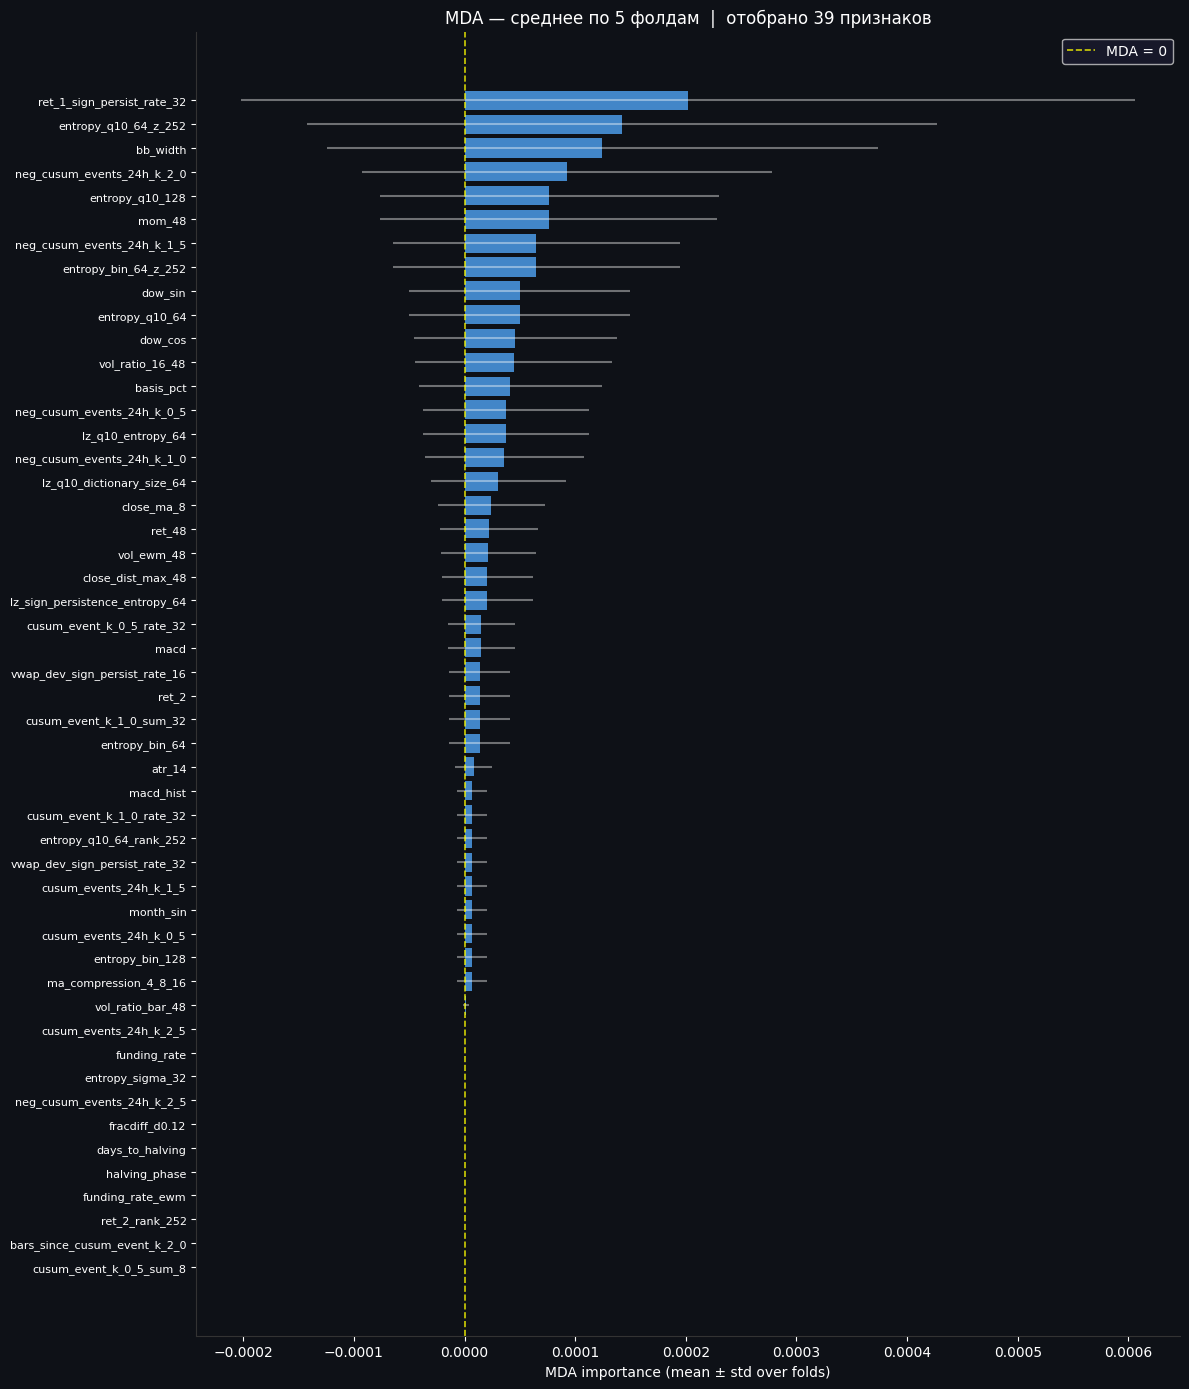

In [7]:


RF_MDA = dict(
    n_estimators             = 100,
    max_depth                = 8,
    min_weight_fraction_leaf = 0.05,
    max_features             = "sqrt",
    criterion                = "entropy",
    class_weight             = "balanced",
    bootstrap                = False,
    n_jobs                   = 1,
    random_state             = 42,
)

X_mdi = X[mdi_selected].values
y_arr = y.values
w_arr = w_final.values
cols  = mdi_selected
rng   = np.random.default_rng(42)

print(f"MDA: {len(folds)} фолдов × {len(cols)} признаков")


def score_feature(col_i, X_te, y_te, model, base_score, seed):
    X_shuf            = X_te.copy()
    X_shuf[:, col_i]  = np.random.default_rng(seed).permutation(X_shuf[:, col_i])
    return base_score - f1_score(y_te, model.predict(X_shuf), average="weighted")


mda_scores      = np.zeros((len(cols), len(folds)))
baseline_scores = []

for fold_i, fold in enumerate(folds):
    tr, te = fold["train_idx"], fold["test_idx"]

    rf = RandomForestClassifier(**RF_MDA)
    rf.fit(X_mdi[tr], y_arr[tr], sample_weight=w_arr[tr])

    base_score = f1_score(y_arr[te], rf.predict(X_mdi[te]), average="weighted")
    baseline_scores.append(base_score)

    seeds   = rng.integers(0, 99999, size=len(cols))
    results = Parallel(n_jobs=-1, prefer="threads")(
        delayed(score_feature)(i, X_mdi[te], y_arr[te], rf, base_score, int(seeds[i]))
        for i in range(len(cols))
    )

    mda_scores[:, fold_i] = results
    print(f"  Fold {fold_i+1}: F1={base_score:.4f}")

mda_mean = pd.Series(mda_scores.mean(axis=1), index=cols).sort_values(ascending=False)
mda_std  = pd.Series(mda_scores.std(axis=1),  index=cols)
mda_selected = mda_mean[mda_mean > 0].index.tolist()

print(f"\nCV F1:       {np.mean(baseline_scores):.4f} ± {np.std(baseline_scores):.4f}")
print(f"MDA > 0:     {len(mda_selected)} признаков")
print(f"MDA <= 0:    {(mda_mean <= 0).sum()} признаков")


threshold_mda = 0.0
BG = "#0e1117"

fig, ax = plt.subplots(figsize=(12, 14))
fig.patch.set_facecolor(BG)
ax.set_facecolor(BG)

top50  = mda_mean.head(50)
errors = mda_std[top50.index]
colors = ["#4C9BE8" if v > threshold_mda else "#E8874C" for v in top50.values]

ax.barh(range(len(top50)), top50.values, xerr=errors.values,
        color=colors, alpha=0.85, error_kw={"ecolor": "white", "alpha": 0.4})
ax.axvline(0, color="yellow", linewidth=1.2, linestyle="--", alpha=0.8, label="MDA = 0")
ax.set_yticks(range(len(top50)))
ax.set_yticklabels(top50.index, fontsize=8, color="white")
ax.set_xlabel("MDA importance (mean ± std over folds)", color="white")
ax.set_title(f"MDA — среднее по {len(folds)} фолдам  |  "
             f"отобрано {len(mda_selected)} признаков",
             color="white", fontsize=12)
ax.tick_params(colors="white")
ax.legend(facecolor="#1a1a2e", labelcolor="white")
ax.invert_yaxis()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color("#333")
ax.spines["bottom"].set_color("#333")

plt.tight_layout()
plt.show()


## Отбор признаков — дополнительная фильтрация

MDI отобрал 175 признаков из 204+, MDA сократил до 39. Это уже значительный прогресс — убраны признаки которые либо не используются деревьями вообще (MDI = 0) либо не влияют на качество предсказания при перемешивании (MDA ≤ 0).

Однако 39 признаков всё ещё могут содержать избыточность. Часть из них вероятно коррелирует между собой — например несколько энтропийных признаков на разных окнах или несколько CUSUM признаков с разными k. Избыточные признаки не улучшают модель, но увеличивают дисперсию оценок и замедляют обучение.

Цель следующего шага — оставить только признаки с наибольшим независимым вкладом. Прогоняем SHAP: в отличие от MDI он не смещён в сторону высококардинальных признаков, а в отличие от MDA учитывает направление и величину вклада каждого признака в каждое предсказание.

# Shap отбор

  Fold 1: done
  Fold 2: done
  Fold 3: done
  Fold 4: done
  Fold 5: done

SHAP > mean: 12 признаков


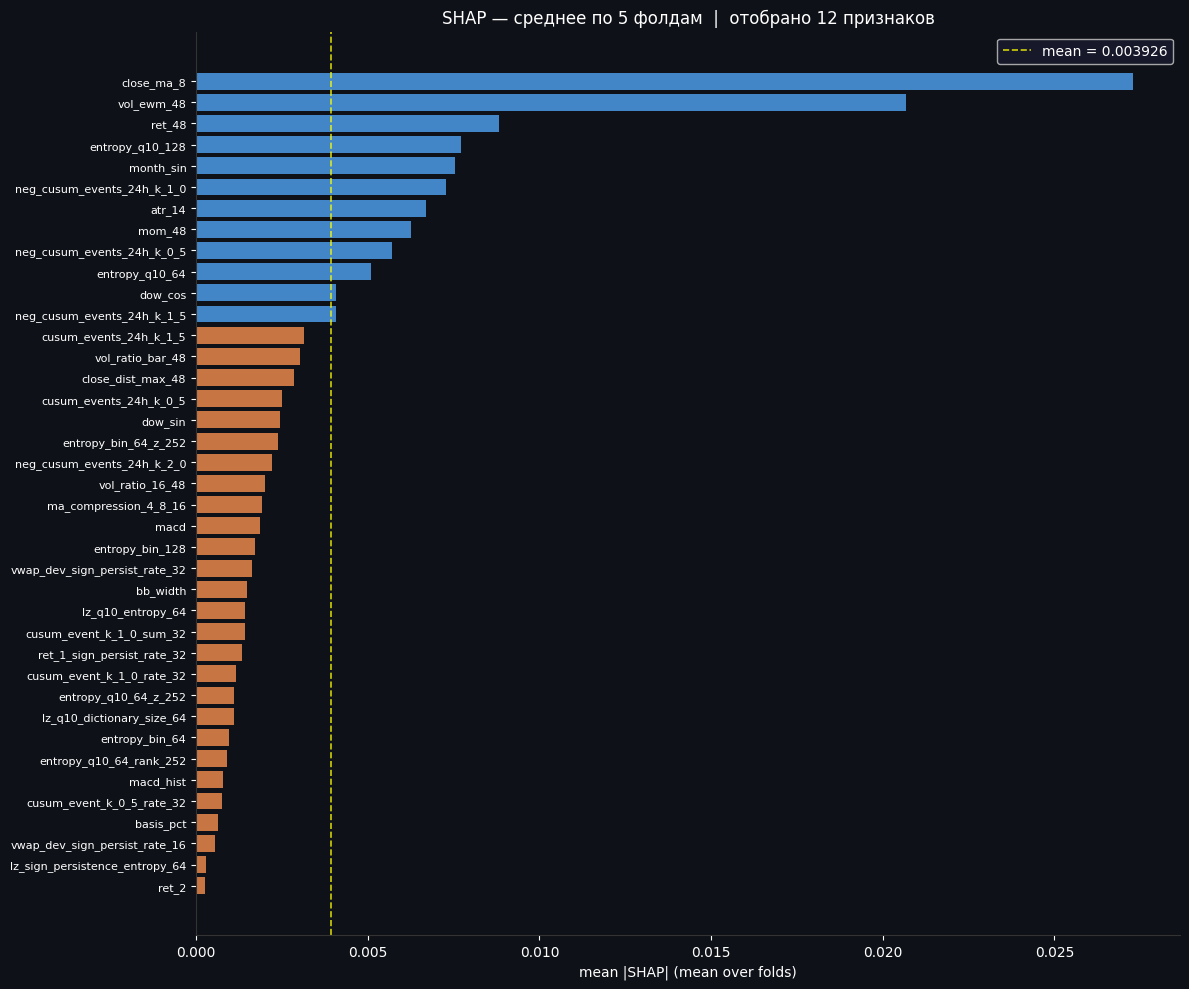

In [13]:


RF_SHAP = dict(
    n_estimators             = 100,
    max_depth                = 8,
    min_weight_fraction_leaf = 0.05,
    max_features             = "sqrt",
    criterion                = "entropy",
    class_weight             = "balanced",
    bootstrap                = False,
    n_jobs                   = -1,
    random_state             = 42,
)

X_mda     = X[mda_selected]
shap_all  = np.zeros((len(mda_selected),))

for fold_i, fold in enumerate(folds):
    tr, te = fold["train_idx"], fold["test_idx"]

    rf = RandomForestClassifier(**RF_SHAP)
    rf.fit(X_mda.iloc[tr], y.iloc[tr], sample_weight=w_final.iloc[tr])

    explainer   = shap.TreeExplainer(rf)
    shap_values = explainer.shap_values(X_mda.iloc[te])

    # для бинарной классификации берём класс 1
    if isinstance(shap_values, list):
        sv = shap_values[1]
    else:
        # новый API shap возвращает array shape (n, features, classes)
        if shap_values.ndim == 3:
            sv = shap_values[:, :, 1]
        else:
            sv = shap_values

    shap_all += np.abs(sv).mean(axis=0)
    print(f"  Fold {fold_i+1}: done")

shap_mean = pd.Series(shap_all / len(folds),
                      index=mda_selected).sort_values(ascending=False)

shap_selected = shap_mean[shap_mean > shap_mean.mean()].index.tolist()

print(f"\nSHAP > mean: {len(shap_selected)} признаков")


BG = "#0e1117"
fig, ax = plt.subplots(figsize=(12, 10))
fig.patch.set_facecolor(BG)
ax.set_facecolor(BG)

threshold_shap = shap_mean.mean()
colors = ["#4C9BE8" if v > threshold_shap else "#E8874C"
          for v in shap_mean.values]

ax.barh(range(len(shap_mean)), shap_mean.values, color=colors, alpha=0.85)
ax.axvline(threshold_shap, color="yellow", linewidth=1.2, linestyle="--",
           alpha=0.8, label=f"mean = {threshold_shap:.6f}")
ax.set_yticks(range(len(shap_mean)))
ax.set_yticklabels(shap_mean.index, fontsize=8, color="white")
ax.set_xlabel("mean |SHAP| (mean over folds)", color="white")
ax.set_title(f"SHAP — среднее по {len(folds)} фолдам  |  "
             f"отобрано {len(shap_selected)} признаков",
             color="white", fontsize=12)
ax.tick_params(colors="white")
ax.legend(facecolor="#1a1a2e", labelcolor="white")
ax.invert_yaxis()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color("#333")
ax.spines["bottom"].set_color("#333")

plt.tight_layout()
plt.show()


## Выводы SHAP

SHAP отобрал **12 признаков** из 39 — те что превышают среднее значение |SHAP| по всем фолдам.

Топ-3 признака с большим отрывом: `close_ma_8`, `vol_ewm_48`, `ret_48`. Это среднесрочные ценовые и волатильностные признаки — модель в первую очередь смотрит на текущее положение цены относительно скользящей средней и уровень волатильности за последний день.

Из энтропийных признаков выжили `entropy_q10_128` и `entropy_q10_64` — информационная сложность ряда на средних горизонтах. Краткосрочные окна (32) не прошли порог.

CUSUM признаки представлены тремя вариантами `neg_cusum_events_24h` с разными k — модель ориентируется именно на накопленные нисходящие события, не восходящие. Это логично для задачи предсказания срабатывания барьера: периоды накопленного падения предшествуют сильным движениям.

Временные признаки `month_sin` и `dow_cos` выжили — сезонность и день недели несут реальную предсказательную силу на BTC.

`atr_14` и `mom_48` — классические технические признаки, подтверждённые тремя методами отбора подряд (MDI → MDA → SHAP).

# Корреляционный анализ финальных признаков

После трёх этапов отбора (MDI → MDA → SHAP) осталось 12 признаков. Прежде чем обучать финальную модель — проверяем их на мультиколлинеарность.

Проблема коррелирующих признаков в Random Forest: если два признака несут одинаковую информацию, дерево случайно выбирает один из них при каждом сплите. В результате важность обоих занижается — каждый получает примерно половину реального вклада. Модель работает, но интерпретация MDI и SHAP искажается.

Используем **Spearman корреляцию** — она улавливает монотонные нелинейные зависимости, а не только линейные как Pearson. Для финансовых рядов это важно: признаки могут быть связаны нелинейно.

Порог: `|corr| > 0.75` — пары выше этого значения считаем избыточными. Из каждой такой пары оставляем признак с более высоким средним |SHAP|.

Пар с |corr| > 0.5: 12
  mom_48                                   ret_48                                    1.000
  atr_14                                   close_ma_8                                0.859
  neg_cusum_events_24h_k_1_5               neg_cusum_events_24h_k_1_0                0.844
  neg_cusum_events_24h_k_0_5               neg_cusum_events_24h_k_1_0                0.830
  entropy_q10_64                           entropy_q10_128                           0.826
  neg_cusum_events_24h_k_1_5               neg_cusum_events_24h_k_0_5                0.791
  neg_cusum_events_24h_k_0_5               ret_48                                   -0.777
  neg_cusum_events_24h_k_0_5               mom_48                                   -0.777
  neg_cusum_events_24h_k_1_5               mom_48                                   -0.763
  neg_cusum_events_24h_k_1_5               ret_48                                   -0.763
  neg_cusum_events_24h_k_1_0               ret_48                  

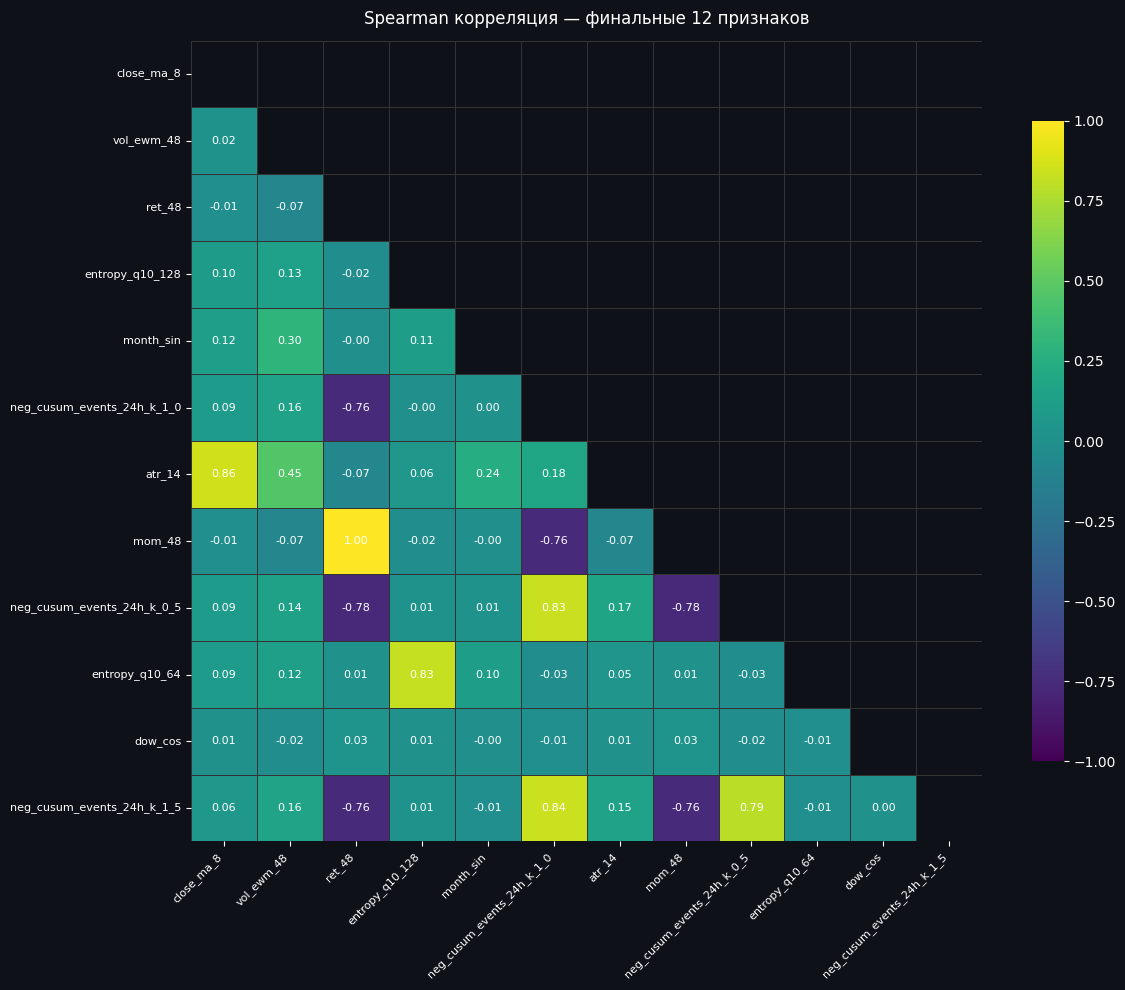

In [19]:

X_final = X[shap_selected].copy()
corr    = X_final.corr(method="spearman")

BG = "#0e1117"
fig, ax = plt.subplots(figsize=(12, 10))
fig.patch.set_facecolor(BG)
ax.set_facecolor(BG)

mask = np.zeros_like(corr, dtype=bool)
mask[np.triu_indices_from(mask)] = True

sns.heatmap(
    corr,
    mask=mask,
    ax=ax,
    cmap="viridis",
    vmin=-1, vmax=1,
    center=0,
    annot=True,
    fmt=".2f",
    annot_kws={"size": 8, "color": "white"},
    linewidths=0.5,
    linecolor="#333",
    cbar_kws={"shrink": 0.8},
)

ax.set_title("Spearman корреляция — финальные 12 признаков",
             color="white", fontsize=12, pad=12)
ax.tick_params(colors="white", labelsize=8)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", color="white")
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, color="white")

cbar = ax.collections[0].colorbar
cbar.ax.tick_params(colors="white")
cbar.ax.yaxis.label.set_color("white")

high_corr = [(corr.index[i], corr.columns[j], corr.iloc[i,j])
             for i in range(len(corr))
             for j in range(i)
             if abs(corr.iloc[i,j]) > 0.5]

print(f"Пар с |corr| > 0.5: {len(high_corr)}")
for a, b, v in sorted(high_corr, key=lambda x: -abs(x[2])):
    print(f"  {a:<40} {b:<40} {v:>6.3f}")

plt.tight_layout()
plt.show()


## Выводы корреляционного анализа

Обнаружено несколько высококоррелирующих кластеров:

**`mom_48` ≈ `ret_48` (corr=1.00)** — фактически одно и то же. Momentum за 1 день это сумма ret_1 за 48 баров, что математически близко к ret_48. Оставляем `ret_48` — более прямой признак.

**`atr_14` и `close_ma_8` (corr=0.86)** — ATR растёт вместе с ценой на бычьем рынке, поэтому коррелирует с MA. Оставляем `close_ma_8` — выше средний |SHAP|.

**Три CUSUM признака коррелируют между собой (0.79–0.84)** — `neg_cusum_events_24h_k_0_5`, `k_1_0`, `k_1_5` измеряют одно и то же с разной чувствительностью. Оставляем один с наибольшим средним |SHAP| — `neg_cusum_events_24h_k_1_0`.

**`entropy_q10_64` и `entropy_q10_128` (corr=0.83)** — энтропия на разных окнах коррелирует. Оставляем `entropy_q10_128` — длиннее окно, устойчивее оценка.

**`ret_48` и `neg_cusum_events_24h_k_1_0` (corr=-0.76)** — сильная отрицательная корреляция: рост цены за день ↔ мало нисходящих CUSUM событий. Несут частично одну и ту же информацию с разных сторон. Убираем `neg_cusum_events_24h_k_1_0`, оставляем `ret_48`.

---

Итоговый набор после трёх итераций дедупликации:

```python
final_features = [
    "close_ma_8",
    "vol_ewm_48",
    "ret_48",
    "entropy_q10_128",
    "month_sin",
    "dow_cos",
]
```

**6 признаков** — все пары ниже порога 0.75, подтверждены тремя методами отбора (MDI → MDA → SHAP). Можно обучать финальную модель.

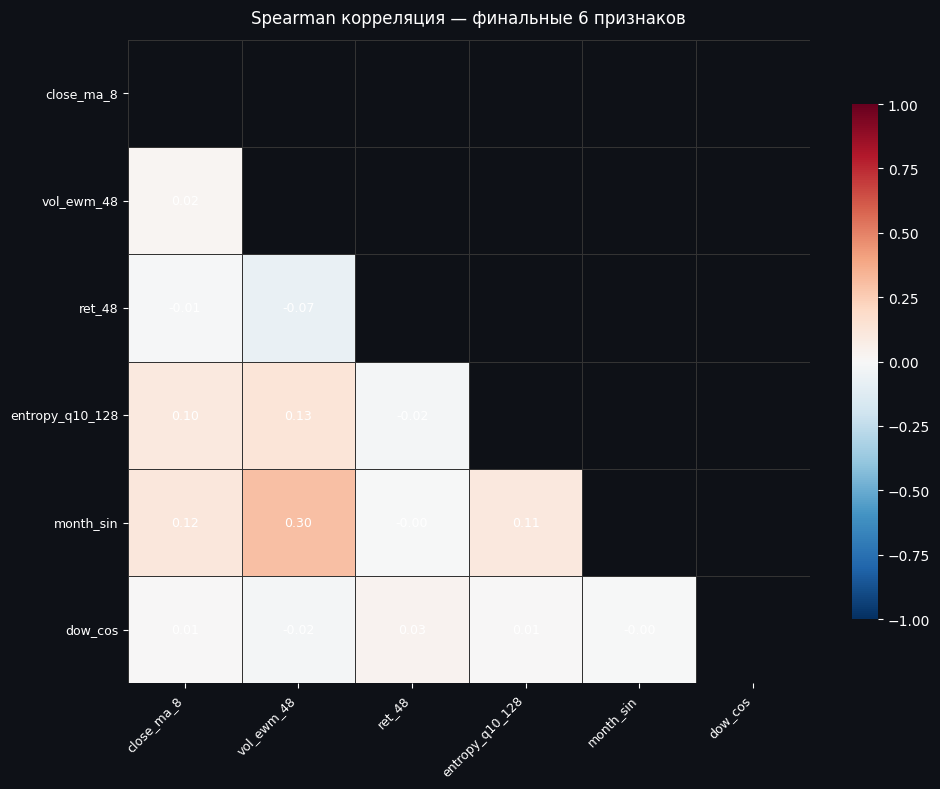

In [24]:
final_features = [
    "close_ma_8",
    "vol_ewm_48",
    "ret_48",
    "entropy_q10_128",
    "month_sin",
    "dow_cos",
]

corr_final = X[final_features].corr(method="spearman")

BG = "#0e1117"
fig, ax = plt.subplots(figsize=(10, 8))
fig.patch.set_facecolor(BG)
ax.set_facecolor(BG)

mask = np.triu(np.ones_like(corr_final, dtype=bool))

sns.heatmap(
    corr_final,
    mask=mask,
    ax=ax,
    cmap="RdBu_r",
    vmin=-1, vmax=1,
    center=0,
    annot=True,
    fmt=".2f",
    annot_kws={"size": 9, "color": "white"},
    linewidths=0.5,
    linecolor="#333",
    cbar_kws={"shrink": 0.8},
)

ax.set_title("Spearman корреляция — финальные 6 признаков",
             color="white", fontsize=12, pad=12)
ax.tick_params(colors="white", labelsize=9)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", color="white")
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, color="white")

cbar = ax.collections[0].colorbar
cbar.ax.tick_params(colors="white")

plt.tight_layout()
plt.show()

# Обучение Trade Model — Попытка 1

Обучаем финальную модель на 6 отобранных признаках и валидируем через Walk-Forward CV.

### Архитектура модели

`BaggingClassifier` с `RandomForestClassifier` как base estimator — вариант 3 по de Prado. Ключевой параметр `max_samples=avgU≈0.49` — каждое дерево обучается на подвыборке размером ~60K наблюдений, что соответствует реальному числу независимых наблюдений с учётом overlap меток. `sample_weight=w_final` передаёт веса из return attribution и time decay — свежие информативные наблюдения влияют на обучение сильнее.

### Валидация

Прогоняем модель по всем 5 фолдам Walk-Forward CV. На каждом фолде:

```
train → всё что до test (с purge)
test  → никогда не видели при обучении
```

Считаем два показателя: **F1 weighted** — качество бинарного решения с учётом дисбаланса классов, **ROC-AUC** — разделяющая способность модели по вероятностям.

Последний фолд (F5) — самый честный: модель обучена на 2020–2025, тестируется на данных которые никогда не видела. Именно его метрики наиболее репрезентативны для реальной торговли.

## Sequential Bootstrap через BaggingClassifier

Стандартный Random Forest использует bootstrap с заменой — при высоком overlap меток это приводит к тому что все деревья строятся на почти одинаковых данных и ансамбль не даёт реального снижения дисперсии.

De Prado предлагает заменить стандартный bootstrap на **sequential bootstrap** — семплирование с учётом уникальности наблюдений. Реализуем через `BaggingClassifier`:

```python
# каждый Bagging итератор = одно дерево на подвыборке avgU×N
rf_base = RandomForestClassifier(
    n_estimators = 1,        # одно дерево на подвыборку
    bootstrap    = False,    # без замены внутри подвыборки
    ...
)

model = BaggingClassifier(
    estimator   = rf_base,
    n_estimators = 500,      # 500 независимых деревьев
    max_samples  = avgU,     # размер подвыборки = средняя уникальность
)
```

Каждый из 500 Bagging итераторов строит одно дерево на случайной подвыборке размером `avgU × N ≈ 60K` наблюдений. Это соответствует реальному числу независимых наблюдений в датасете с учётом overlap Triple Barrier меток.

Результат: деревья максимально декоррелированы между собой — ансамбль действительно снижает дисперсию, а не просто усредняет одинаковые деревья.

  Fold 1: F1=0.6722  AUC=0.5868  
  Fold 2: F1=0.6534  AUC=0.4358  
  Fold 3: F1=0.6417  AUC=0.4951  
  Fold 4: F1=0.7304  AUC=0.5723  
  Fold 5: F1=0.7630  AUC=0.5224  ← last (OOS)

CV F1:  0.6921 ± 0.0468
CV AUC: 0.5225 ± 0.0546

Last fold (честный OOS):
  F1  = 0.7630
  AUC = 0.5224


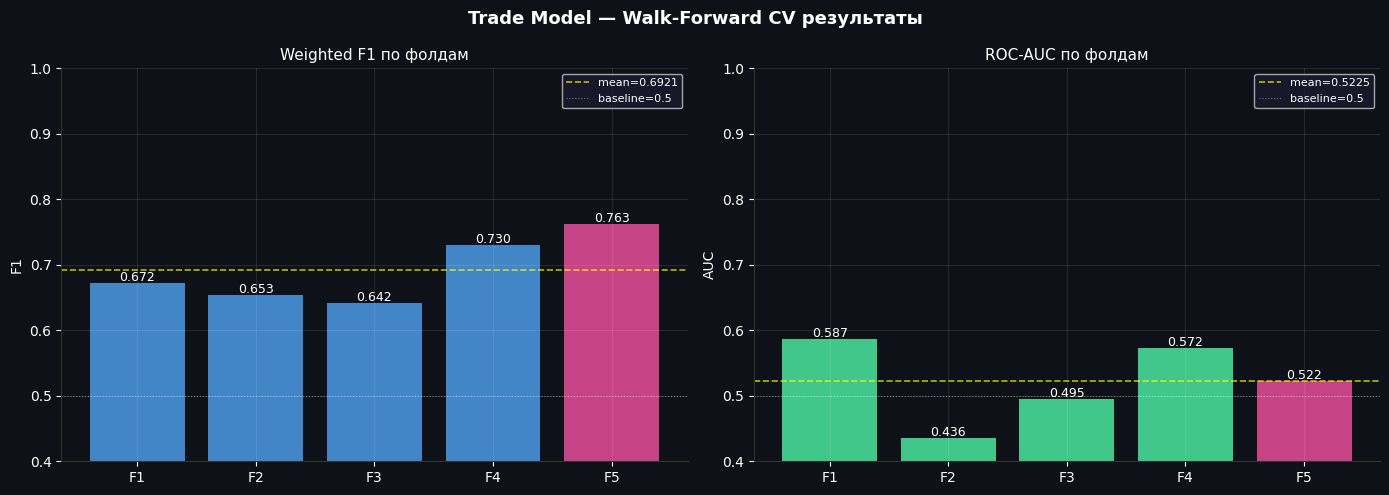

In [27]:

X_final = X[final_features].values
y_arr   = y.values
w_arr   = w_final.values

rf_base = RandomForestClassifier(
    n_estimators             = 1,
    criterion                = "entropy",
    bootstrap                = False,
    class_weight             = "balanced_subsample",
    n_jobs                   = 1,
    random_state             = 42,
)

model = BaggingClassifier(
    estimator    = rf_base,
    n_estimators = 500,
    max_samples  = avgU,
    max_features = 1.0,
    random_state = 42,
    n_jobs       = -1,
)

f1_scores  = []
auc_scores = []
oof_proba  = np.full(len(y_arr), np.nan)

for fold_i, fold in enumerate(folds):
    tr, te = fold["train_idx"], fold["test_idx"]

    model.fit(X_final[tr], y_arr[tr], sample_weight=w_arr[tr])

    proba        = model.predict_proba(X_final[te])[:, 1]
    pred         = (proba > 0.5).astype(int)
    oof_proba[te] = proba

    f1  = f1_score(y_arr[te],  pred,  average="weighted")
    auc = roc_auc_score(y_arr[te], proba)

    f1_scores.append(f1)
    auc_scores.append(auc)

    is_last = fold_i == len(folds) - 1
    tag     = "← last (OOS)" if is_last else ""
    print(f"  Fold {fold_i+1}: F1={f1:.4f}  AUC={auc:.4f}  {tag}")

print(f"\nCV F1:  {np.mean(f1_scores):.4f} ± {np.std(f1_scores):.4f}")
print(f"CV AUC: {np.mean(auc_scores):.4f} ± {np.std(auc_scores):.4f}")
print(f"\nLast fold (честный OOS):")
print(f"  F1  = {f1_scores[-1]:.4f}")
print(f"  AUC = {auc_scores[-1]:.4f}")


fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor("#0e1117")

fold_labels = [f"F{i+1}" for i in range(len(folds))]
colors_f1  = ["#E84C9B" if i == len(folds)-1 else "#4C9BE8"
               for i in range(len(folds))]
colors_auc = ["#E84C9B" if i == len(folds)-1 else "#4CE8A0"
               for i in range(len(folds))]

for ax, scores, colors, title, metric in [
    (axes[0], f1_scores,  colors_f1,  "Weighted F1 по фолдам",  "F1"),
    (axes[1], auc_scores, colors_auc, "ROC-AUC по фолдам",      "AUC"),
]:
    ax.set_facecolor("#0e1117")
    bars = ax.bar(fold_labels, scores, color=colors, alpha=0.85)
    ax.axhline(np.mean(scores), color="yellow", linewidth=1.2,
               linestyle="--", alpha=0.7,
               label=f"mean={np.mean(scores):.4f}")
    ax.axhline(0.5, color="white", linewidth=0.8,
               linestyle=":", alpha=0.4, label="baseline=0.5")
    for bar, v in zip(bars, scores):
        ax.text(bar.get_x() + bar.get_width()/2, v + 0.003,
                f"{v:.3f}", ha="center", color="white", fontsize=9)
    ax.set_title(title, color="white", fontsize=11)
    ax.set_ylabel(metric, color="white")
    ax.tick_params(colors="white")
    ax.legend(facecolor="#1a1a2e", labelcolor="white", fontsize=8)
    ax.set_ylim(0.4, 1.0)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color("#333")
    ax.spines["bottom"].set_color("#333")
    ax.grid(alpha=0.1, color="white")

plt.suptitle("Trade Model — Walk-Forward CV результаты",
             color="white", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## Оценка результатов

### F1 = 0.692 — неплохо, но с оговорками

F1 выше baseline (0.5) на всех фолдах. Последний фолд F5 = 0.763 — лучший результат, что хорошо: модель не деградирует на свежих данных, а улучшается. Это может говорить о том что признаки работают в режиме 3 (пост-ETF) лучше чем в режиме 2.

Но важно помнить: дисбаланс классов 78%/22%. Модель которая всегда предсказывает 1 получит weighted F1 ≈ 0.68 просто за счёт доминирующего класса. Наши 0.692 лишь немного выше этого тривиального baseline.

### ROC-AUC = 0.522 — слабо

Это почти случайный классификатор. AUC = 0.5 означает что модель не умеет ранжировать вероятности лучше случайного. F2 = 0.436 вообще хуже случайного. Это говорит о том что `predict_proba` ненадёжны — модель принимает правильные бинарные решения но не умеет калибровать уверенность.

### Что это значит практически

Порог 0.5 работает нормально по F1, но крутить порог вероятности в бэктестинге смысла мало 

# Обучение Trade Model — Попытка 2

## Trade Model — план переработки

### Что не так с текущей версией

Текущая модель обучена на `y_trade` из Triple Barrier (`bin != 0`) с дисбалансом 78%/22%. ROC-AUC = 0.52 — почти случайный классификатор. Проблема не в модели а в таргете и признаках.

---

### Шаг 1 — Пересобрать таргет

Заменяем Triple Barrier таргет на meta-labeling через forward return:

```python
y_trade = 1  если  abs(ret_forward_24) > cost_proxy * 12
y_trade = 0  иначе
```

Это даёт сбалансированный датасет ~53%/47% и чистую постановку задачи — есть ли значимое движение с учётом издержек.

---

### Шаг 2 — Убрать cost features из X

`roll_spread` и `amihud_illiquidity` участвуют в формуле таргета — оставлять их в признаках значит давать модели подсказку. Убираем из X, оставляем только в таргете.

---

### Шаг 3 — Пересобрать признаки

Пересобрать фолды под новый датасет с правильным `t1 = t0 + 24 баров`. Прогнать SHAP → MDA последовательно на новых фолдах.

---

### Шаг 4 - Обучить trade модель и добиться ROC AUC > 0.80

N:       122,037
y=1:     64,320  (52.7%)
y=0:     57,717  (47.3%)
Период:  2020-03-26 → 2026-04-01


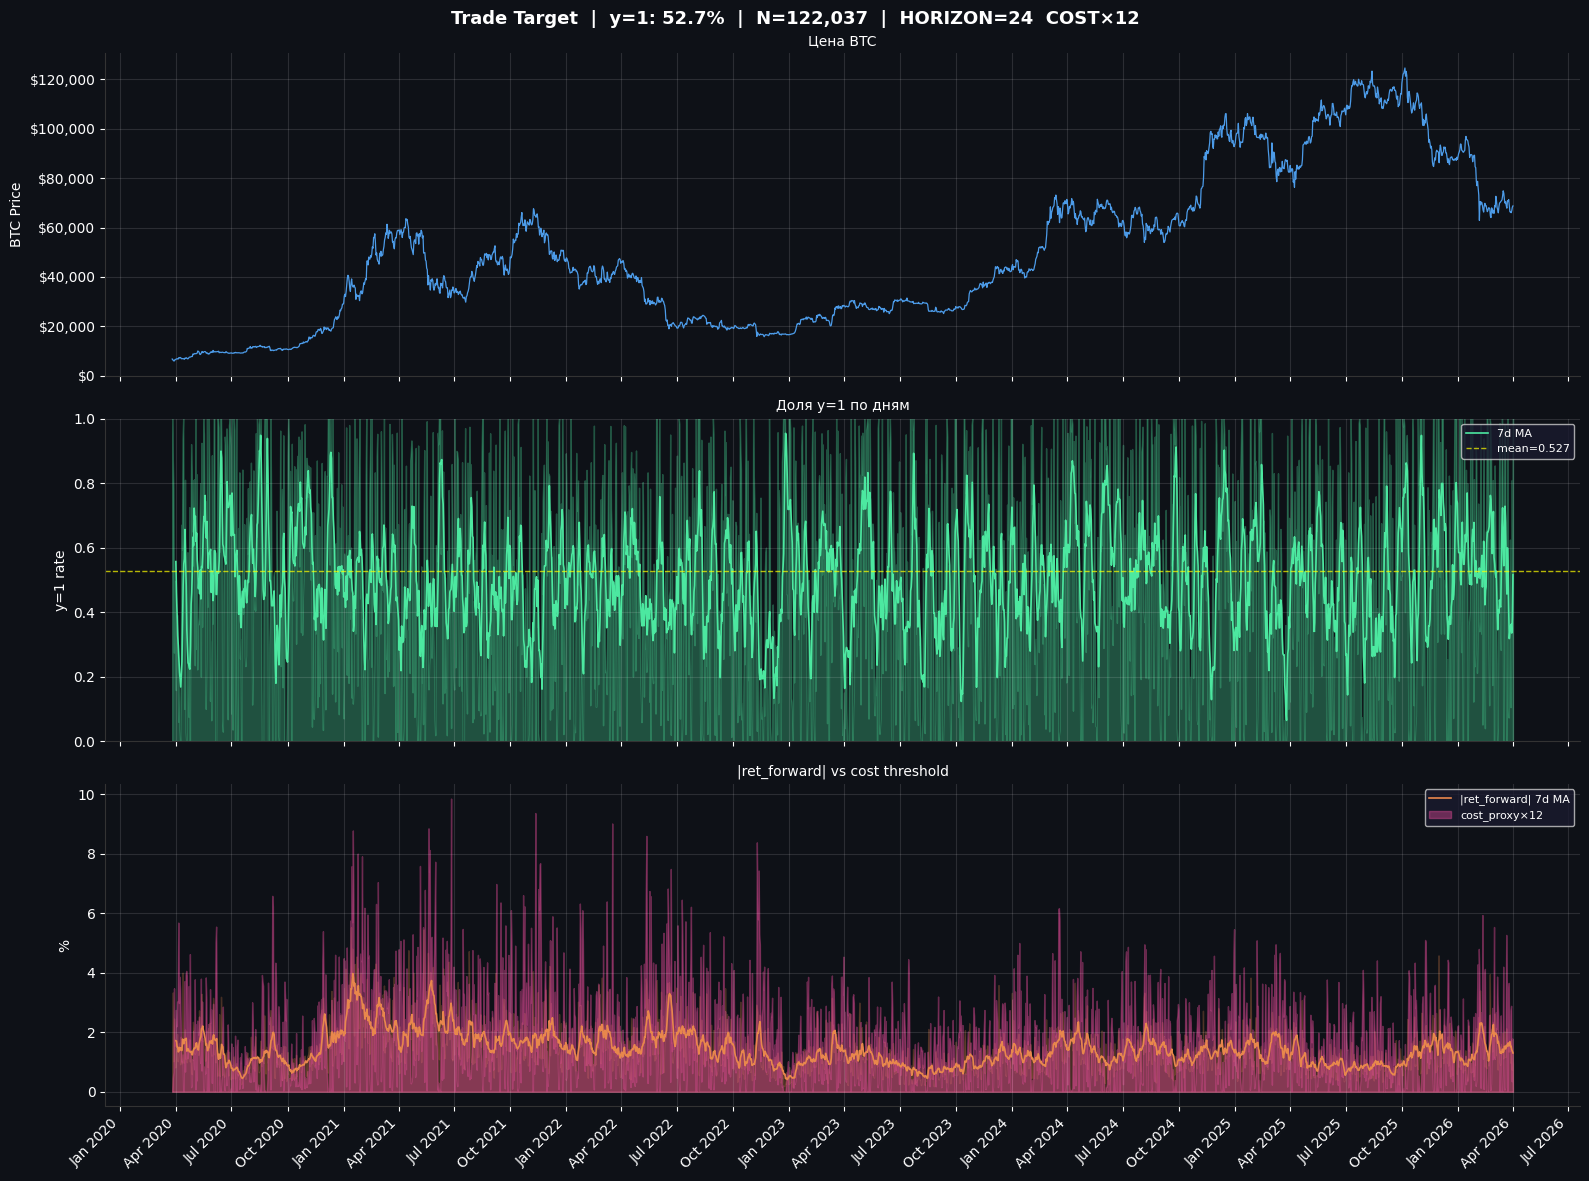


ret_forward:  mean=1.5581%  median=1.1914%  p95=4.2677%
cost_proxy:   mean=0.152009%  threshold=1.824104%


In [37]:
BARS_DIR  = Path("data/bars")
HORIZON   = 24
COST_MULT = 12

df = pd.read_parquet(BARS_DIR / "dataset_v5.parquet")
df.index = pd.to_datetime(df.index)
df = df.sort_index()

# пересчитываем roll_spread и amihud на месте
ret_col   = df["ret"].fillna(0)
roll_var  = ret_col.rolling(48).var()
roll_cov  = ret_col.rolling(48).cov(ret_col.shift(1))
df["roll_spread"]        = 2 * np.sqrt(np.maximum(0, -roll_cov))
df["roll_sigma_u"]       = np.sqrt(np.maximum(0, roll_var + 2 * roll_cov))
df["amihud_illiquidity"] = df["ret"].abs() / df["dollar_volume"].replace(0, np.nan)

df["ret_forward"] = df["close"].shift(-HORIZON) / df["close"] - 1.0
df["cost_proxy"]  = (df["roll_spread"].abs().fillna(0) +
                     df["amihud_illiquidity"].clip(lower=0).fillna(0))
df["y_trade"]     = (df["ret_forward"].abs() > df["cost_proxy"] * COST_MULT).astype("int8")
df = df[df["ret_forward"].notna()].copy()

n       = len(df)
n1      = int(df["y_trade"].sum())
balance = n1 / n

print(f"N:       {n:,}")
print(f"y=1:     {n1:,}  ({balance*100:.1f}%)")
print(f"y=0:     {n - n1:,}  ({(1-balance)*100:.1f}%)")
print(f"Период:  {df.index[0].date()} → {df.index[-1].date()}")

daily = df.resample("1D").agg(
    y1_rate     =("y_trade",     "mean"),
    ret_fwd_abs =("ret_forward", lambda x: x.abs().mean()),
    cost_proxy  =("cost_proxy",  "mean"),
)
daily["ret_fwd_7d"] = daily["ret_fwd_abs"].rolling(7).mean()
daily["y1_7d"]      = daily["y1_rate"].rolling(7).mean()
if daily.index.tz:
    daily.index = daily.index.tz_localize(None)

close_daily = df["close"].resample("1D").last().dropna()
if close_daily.index.tz:
    close_daily.index = close_daily.index.tz_localize(None)

BG = "#0e1117"
fig, axes = plt.subplots(3, 1, figsize=(16, 12), sharex=True)
fig.patch.set_facecolor(BG)
fig.suptitle(f"Trade Target  |  y=1: {balance*100:.1f}%  |  N={n:,}  |  HORIZON={HORIZON}  COST×{COST_MULT}",
             color="white", fontsize=13, fontweight="bold")

def style(ax):
    ax.set_facecolor(BG)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color("#333")
    ax.spines["bottom"].set_color("#333")
    ax.tick_params(colors="white")
    ax.grid(alpha=0.12, color="white")

style(axes[0])
axes[0].plot(close_daily.index, close_daily.values, color="#4C9BE8", linewidth=0.9)
axes[0].set_ylabel("BTC Price", color="white")
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f"${x:,.0f}"))
axes[0].set_title("Цена BTC", color="white", fontsize=10)

style(axes[1])
axes[1].fill_between(daily.index, daily["y1_rate"], alpha=0.3, color="#4CE8A0")
axes[1].plot(daily.index, daily["y1_7d"], color="#4CE8A0", linewidth=1.2, label="7d MA")
axes[1].axhline(balance, color="yellow", linewidth=1, linestyle="--",
                alpha=0.7, label=f"mean={balance:.3f}")
axes[1].set_ylabel("y=1 rate", color="white")
axes[1].set_title("Доля y=1 по дням", color="white", fontsize=10)
axes[1].legend(facecolor="#1a1a2e", labelcolor="white", fontsize=8)
axes[1].set_ylim(0, 1)

style(axes[2])
axes[2].fill_between(daily.index, daily["ret_fwd_abs"] * 100, alpha=0.25, color="#E8874C")
axes[2].plot(daily.index, daily["ret_fwd_7d"] * 100, color="#E8874C",
             linewidth=1.2, label="|ret_forward| 7d MA")
axes[2].fill_between(daily.index, daily["cost_proxy"] * COST_MULT * 100,
                     alpha=0.4, color="#E84C9B", label=f"cost_proxy×{COST_MULT}")
axes[2].set_ylabel("%", color="white")
axes[2].set_title("|ret_forward| vs cost threshold", color="white", fontsize=10)
axes[2].legend(facecolor="#1a1a2e", labelcolor="white", fontsize=8)

axes[2].xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 4, 7, 10]))
axes[2].xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
plt.setp(axes[2].xaxis.get_majorticklabels(), rotation=45, ha="right", color="white")

plt.tight_layout()
plt.show()

print(f"\nret_forward:  mean={df['ret_forward'].abs().mean()*100:.4f}%  "
      f"median={df['ret_forward'].abs().median()*100:.4f}%  "
      f"p95={df['ret_forward'].abs().quantile(0.95)*100:.4f}%")
print(f"cost_proxy:   mean={df['cost_proxy'].mean()*100:.6f}%  "
      f"threshold={df['cost_proxy'].mean()*COST_MULT*100:.6f}%")


## Выводы по таргету

**Баланс классов отличный** — 52.7% / 47.3%. Это почти идеальный баланс, нет нужды в специальной обработке дисбаланса. Сравни с прежним Triple Barrier таргетом где было 78%/22%.

**Порог работает корректно.** Средний `|ret_forward|` = 1.56% против порога `cost_proxy×12` = 1.82%. Они близки — это значит порог не тривиальный: модель не может просто предсказывать всегда 1 или всегда 0.

**p95 = 4.27%** — самые сильные движения за 12 часов. Именно их модель должна ловить в первую очередь.

**Нижний график** показывает что `cost_proxy×12` (розовый) почти всегда ниже `|ret_forward|` — но не всегда. В периоды низкой волатильности (2023 боковик) cost threshold превышает forward return чаще, отсюда больше y=0. Это правильное поведение — в тихом рынке торговать не стоит.

**Средний график** — высокая дисперсия доли y=1 по дням говорит о том что таргет нестационарен во времени. Это нормально для финансовых данных и подчёркивает важность Walk-Forward CV.



In [38]:
EXCLUDE_COLS = {
    # таргет и производные
    "y_trade", "ret_forward", "cost_proxy",

    # участвуют в расчёте cost_proxy / taргета — убираем из X
    "roll_spread", "amihud_illiquidity", "roll_sigma_u",

    # служебные метки из Triple Barrier
    "bin", "t1", "ret",

    # веса
    "w", "w_raw", "w_final", "decay", "w_from_weights",

    # сырые ценовые колонки — leakage
    "open", "high", "low", "close", "vwap",
    "mark_close", "index_close",

    # объём в абсолюте — коррелирует с amihud
    "dollar_volume", "volume",

    # вспомогательные
    "bb_upper", "bb_lower",
    "y_trade", "w_raw", "w_from_weights",

    # производные от roll_spread / amihud
    "ret_1_over_roll_spread",
    "vwap_dev_over_roll_spread",
    "tick_imbalance_over_amihud",
    "signed_dollar_volume_over_roll_sigma_u",
}

y      = df["y_trade"].copy()
w_final = df["w_final"].copy()

feature_cols = [
    c for c in df.columns
    if c not in EXCLUDE_COLS
    and df[c].dtype in [np.float64, np.float32,
                        np.int64, np.int32, np.int8]
]

X = df[feature_cols].replace([np.inf, -np.inf], np.nan).fillna(0)

print(f"X:        {X.shape}")
print(f"y=1:      {y.sum():,}  ({y.mean()*100:.1f}%)")
print(f"\nИсключено: {len(EXCLUDE_COLS)} колонок")
print(f"Осталось:  {len(feature_cols)} признаков")

X:        (122037, 222)
y=1:      64,320  (52.7%)

Исключено: 29 колонок
Осталось:  222 признаков


In [40]:

cv = WalkForwardPurgedCV(n_splits=5, min_train_pct=0.15,
                         test_pct=1/8, pct_embargo=0.005)

t1_series = pd.to_datetime(df.index) + pd.Timedelta(hours=12)
t1_series = pd.Series(t1_series.values, index=df.index)

folds = [{"train_idx": tr, "test_idx": te}
         for tr, te in cv.split(df, t1=t1_series)]

print(f"Фолдов: {len(folds)}")
for i, f in enumerate(folds):
    print(f"  F{i+1}: train={len(f['train_idx']):,}  test={len(f['test_idx']):,}")


Фолдов: 5
  F1: train=23,774  test=15,254
  F2: train=44,511  test=15,254
  F3: train=65,260  test=15,254
  F4: train=86,005  test=15,254
  F5: train=106,755  test=15,254


## Clustered Feature Importance — подход de Prado

### Проблема текущего подхода

Стандартный порядок MDI → MDA → удаление коррелированных признаков имеет фундаментальный изъян: важность считается **до** очистки от корреляции. Когда два признака коррелируют между собой, дерево случайно выбирает один из них при каждом сплите — важность размывается между ними пополам. В результате оба выглядят менее важными чем они есть на самом деле, и мы рискуем выбросить "не ту" фичу из пары.

Альтернатива — сначала убрать корреляцию, потом считать важность — тоже не идеальна: мы можем выбросить более информативный признак из пары просто потому что не знали их важности заранее.

---

### Решение — Clustered Feature Importance

De Prado предлагает гибридный подход который решает обе проблемы одновременно:

```
1. Кластеризация по корреляции (иерархическая)
         ↓
2. MDI / MDA на уровне кластеров
   — важность не размывается внутри кластера
   — видим какие группы признаков реально важны
         ↓
3. Внутри важных кластеров — выбираем лучший признак по MDA
   — теперь знаем важность и можем выбрать правильно
```

---

### Почему это лучше

Мы не выбрасываем ничего до оценки важности — кластеризация убирает только **redundancy**, а не signal. Важность каждого кластера считается честно, без bias от мультиколлинеарности. Финальный отбор признака внутри кластера опирается на реальную важность, а не на случайность.

---

### Что делаем

Берём все ~220 признаков из X, строим иерархическую кластеризацию по Spearman корреляции, выбираем порог — получаем K кластеров. Считаем MDI на уровне кластеров, отбираем важные. Внутри каждого важного кластера запускаем MDA и берём лучший признак.

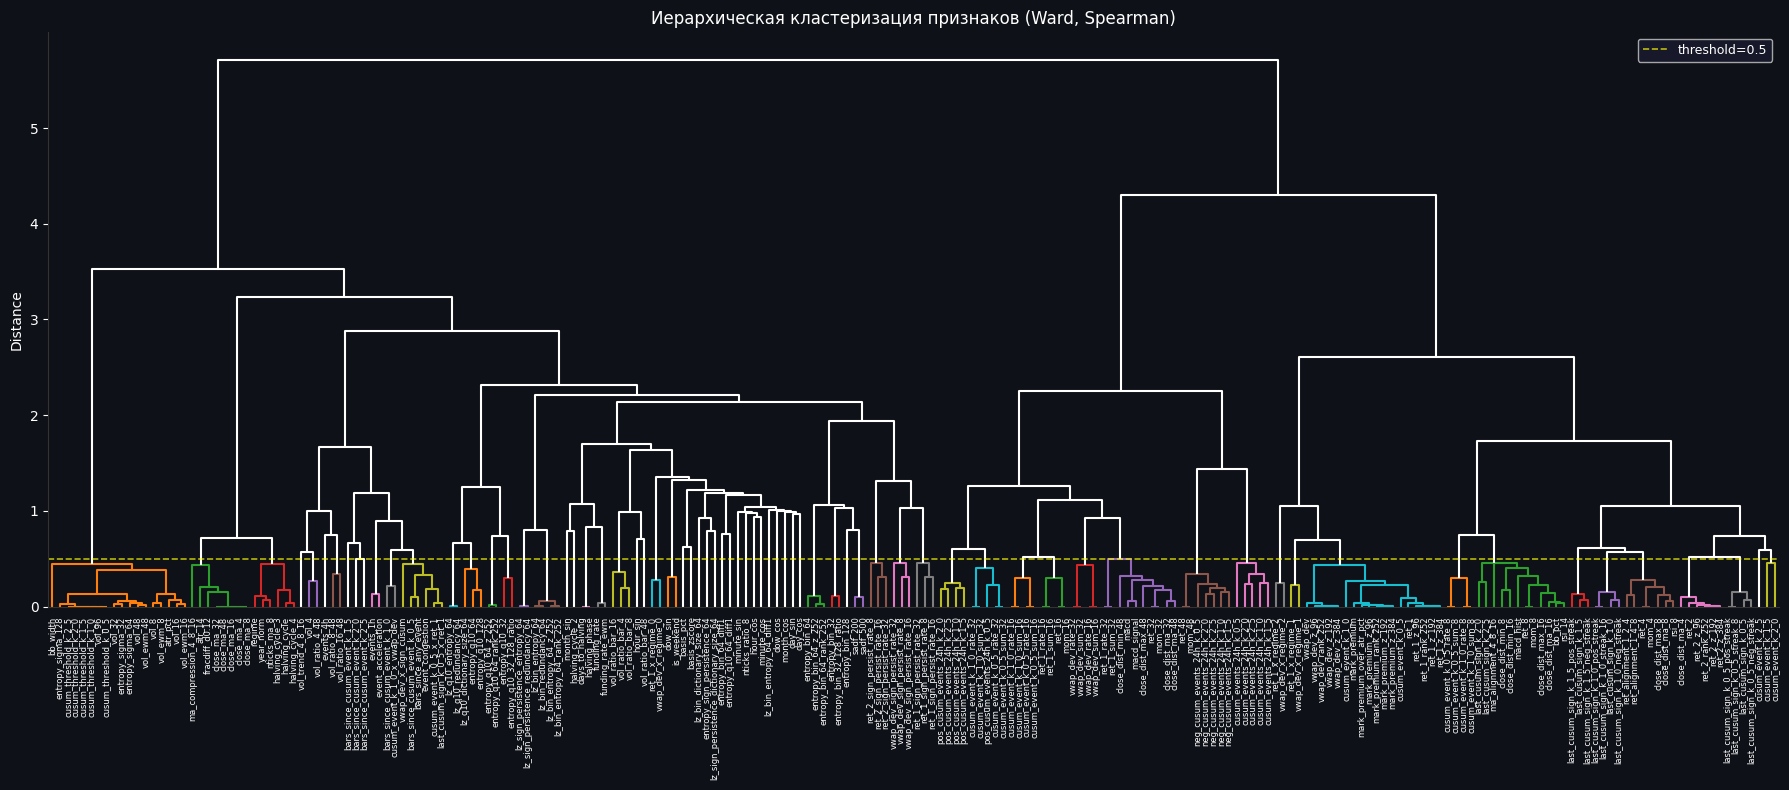

Порог:     0.5
Кластеров: 71
Признаков: 222

Размер кластеров:
cluster
1     18
2      8
3      6
4      2
5      1
6      2
7      1
8      1
9      1
10     1
11     2
12     2
13     6
14     2
15     3
16     2
17     2
18     2
19     4
20     1
21     1
22     2
23     2
24     3
25     1
26     1
27     2
28     2
29     1
30     1
31     1
32     1
33     1
34     1
35     1
36     1
37     1
38     1
39     1
40     1
41     1
42     1
43     1
44     1
45     3
46     2
47     2
48     1
49     3
50     3
51     3
52     4
53     5
54     4
55     4
56     4
57    10
58     7
59     5
60     2
61     2
62    18
63     4
64    12
65     3
66     4
67     7
68     6
69     4
70     2
71     1


In [48]:

from scipy.cluster.hierarchy import linkage, fcluster, dendrogram
from scipy.spatial.distance import squareform

# ── корреляционная матрица ──────────────────────────────────────────────────
corr = X.corr(method="spearman").abs()
dist = 1 - corr
np.fill_diagonal(dist.values, 0)
dist = np.maximum(dist, dist.T)  # симметрия

condensed = squareform(dist.values, checks=False)
Z         = linkage(condensed, method="ward")

# ── дендрограмма ─────────────────────────────────────────────────────────────
BG = "#0e1117"
fig, ax = plt.subplots(figsize=(18, 8))
fig.patch.set_facecolor(BG)
ax.set_facecolor(BG)

dendrogram(Z, labels=X.columns.tolist(), ax=ax,
           leaf_rotation=90, leaf_font_size=6,
           color_threshold=0.5,
           above_threshold_color="white")

ax.axhline(0.5, color="yellow", linewidth=1.2, linestyle="--",
           alpha=0.7, label="threshold=0.5")
ax.set_title("Иерархическая кластеризация признаков (Ward, Spearman)",
             color="white", fontsize=12)
ax.tick_params(colors="white")
ax.set_ylabel("Distance", color="white")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color("#333")
ax.spines["bottom"].set_color("#333")
ax.legend(facecolor="#1a1a2e", labelcolor="white", fontsize=9)

plt.tight_layout()
plt.show()

# ── нарезаем кластеры ────────────────────────────────────────────────────────
THRESHOLD = 0.5
labels    = fcluster(Z, t=THRESHOLD, criterion="distance")
clusters  = pd.Series(labels, index=X.columns, name="cluster")

n_clusters = clusters.nunique()
print(f"Порог:     {THRESHOLD}")
print(f"Кластеров: {n_clusters}")
print(f"Признаков: {len(X.columns)}")
print(f"\nРазмер кластеров:")
print(clusters.value_counts().sort_index().to_string())


## Выводы кластеризации

71 кластер из 222 признаков при пороге 0.5. Структура неоднородная:

**Крупные кластеры** (размер ≥ 5) — это группы сильно коррелирующих признаков где важность размывается между членами. Именно здесь MDI давал искажённую картину:
- Кластер 1 (18 признаков) и кластер 62 (18) — скорее всего persistence/streak признаки на разных окнах
- Кластер 57 (10), 64 (12) — вероятно CUSUM и энтропийные группы

**Одиночные кластеры** (размер = 1, их 27) — уникальные признаки без коррелятов. Их MDI уже был честным.

---

### Что делаем дальше

```
1. Из каждого кластера берём одного представителя
   → выбираем по дисперсии (наиболее информативный)
   → получаем ~71 независимый признак

2. MDI на представителях кластеров
   → честная важность без размытия

3. Отбираем важные кластеры (MDI > 1/N)

4. Внутри каждого важного кластера — MDA
   → выбираем лучший признак из кластера
```


Кластеров:      71
Представителей: 71

MDI на 71 представителях × 5 фолдов
  Fold 1: done
  Fold 2: done
  Fold 3: done
  Fold 4: done
  Fold 5: done

MDI > 1/N:        16 кластеров
Порог:            0.01408

MDA внутри 16 важных кластеров...

Финальных признаков: 16
  ma_compression_4_8_16                         кластер=2  размер=8
  nticks_ma_8                                   кластер=3  размер=6
  bars_since_cusum_event_k_2_5                  кластер=9  размер=1
  entropy_q10_64_rank_252                       кластер=16  размер=2
  days_to_halving                               кластер=22  размер=2
  entropy_sign_persistence_64                   кластер=31  размер=1
  day_sin                                       кластер=40  размер=1
  dow_cos                                       кластер=43  размер=1
  sadf_200                                      кластер=47  размер=2
  ret_2_sign_persist_rate_32                    кластер=49  размер=3
  vwap_dev_sign_persist_rate_32              

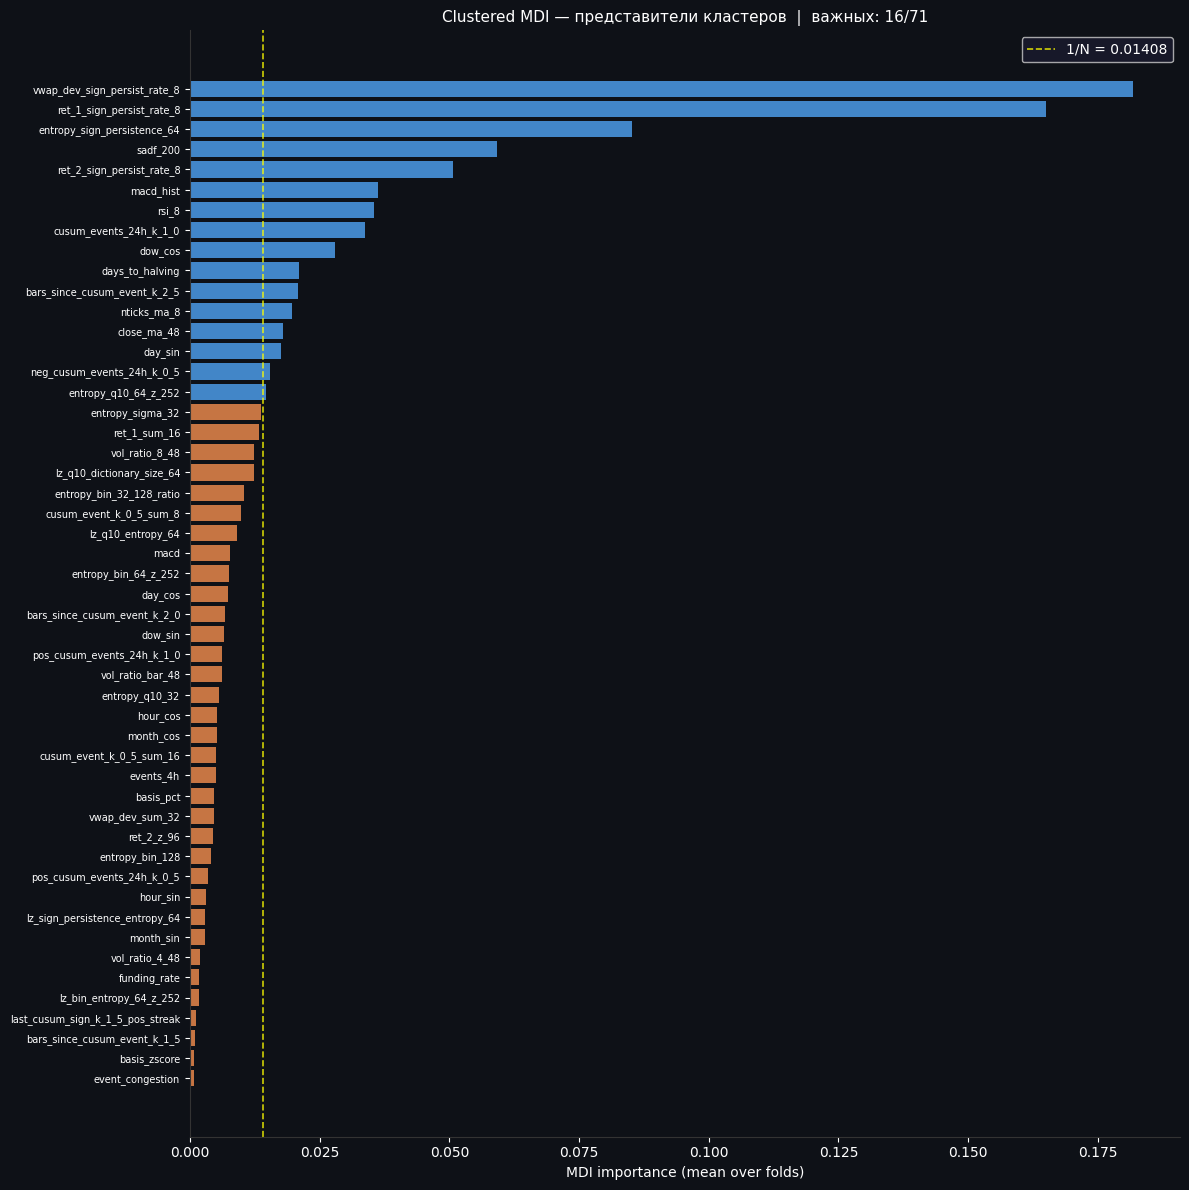

In [49]:

cluster_representatives = {}
cluster_members         = {}

for c in sorted(clusters.unique()):
    members = clusters[clusters == c].index.tolist()
    cluster_members[c] = members
    if len(members) == 1:
        cluster_representatives[c] = members[0]
    else:
        variances = X[members].var()
        cluster_representatives[c] = variances.idxmax()

repr_features = list(cluster_representatives.values())
print(f"Кластеров:      {len(cluster_representatives)}")
print(f"Представителей: {len(repr_features)}")

# ── 2. MDI на представителях ─────────────────────────────────────────────────
X_repr = X[repr_features]

RF_MDI = dict(
    n_estimators             = 100,
    max_depth                = 6,
    min_weight_fraction_leaf = 0.05,
    max_features             = "sqrt",
    criterion                = "entropy",
    class_weight             = "balanced",
    bootstrap                = False,
    n_jobs                   = -1,
    random_state             = 42,
)

threshold_repr = 1.0 / len(repr_features)
mdi_repr_all   = []

print(f"\nMDI на {len(repr_features)} представителях × {len(folds)} фолдов")

for i, fold in enumerate(folds):
    X_tr = X_repr.iloc[fold["train_idx"]]
    y_tr = y.iloc[fold["train_idx"]]
    w_tr = w_final.iloc[fold["train_idx"]]

    rf = RandomForestClassifier(**RF_MDI)
    rf.fit(X_tr, y_tr, sample_weight=w_tr)
    mdi_repr_all.append(rf.feature_importances_)
    print(f"  Fold {i+1}: done")

mdi_repr = pd.Series(
    np.mean(mdi_repr_all, axis=0),
    index=repr_features
).sort_values(ascending=False)

important_reprs   = mdi_repr[mdi_repr > threshold_repr].index.tolist()
important_clusters = [c for c, r in cluster_representatives.items()
                      if r in important_reprs]

print(f"\nMDI > 1/N:        {len(important_reprs)} кластеров")
print(f"Порог:            {threshold_repr:.5f}")

# ── 3. MDA внутри важных кластеров ───────────────────────────────────────────
print(f"\nMDA внутри {len(important_clusters)} важных кластеров...")

final_features = []

for c in important_clusters:
    members = cluster_members[c]

    if len(members) == 1:
        final_features.append(members[0])
        continue

    X_c   = X[members].values
    y_arr = y.values
    w_arr = w_final.values
    rng   = np.random.default_rng(42 + c)

    mda_c = np.zeros(len(members))

    for fold in folds:
        tr, te = fold["train_idx"], fold["test_idx"]
        rf = RandomForestClassifier(**{**RF_MDI, "n_jobs": -1})
        rf.fit(X_c[tr], y_arr[tr], sample_weight=w_arr[tr])
        base = f1_score(y_arr[te], rf.predict(X_c[te]), average="weighted")

        for j in range(len(members)):
            X_s = X_c[te].copy()
            X_s[:, j] = rng.permutation(X_s[:, j])
            mda_c[j] += base - f1_score(y_arr[te], rf.predict(X_s),
                                         average="weighted")

    best = members[np.argmax(mda_c)]
    final_features.append(best)

print(f"\nФинальных признаков: {len(final_features)}")
for f in final_features:
    c = clusters[f]
    sz = len(cluster_members[c])
    print(f"  {f:<45} кластер={c}  размер={sz}")

# ── 4. график MDI на представителях ──────────────────────────────────────────
BG = "#0e1117"
fig, ax = plt.subplots(figsize=(12, 12))
fig.patch.set_facecolor(BG)
ax.set_facecolor(BG)

top_n  = min(50, len(mdi_repr))
top_r  = mdi_repr.head(top_n)
colors = ["#4C9BE8" if v > threshold_repr else "#E8874C" for v in top_r.values]

ax.barh(range(top_n), top_r.values, color=colors, alpha=0.85)
ax.axvline(threshold_repr, color="yellow", linewidth=1.2, linestyle="--",
           alpha=0.8, label=f"1/N = {threshold_repr:.5f}")
ax.set_yticks(range(top_n))
ax.set_yticklabels(top_r.index, fontsize=7, color="white")
ax.set_xlabel("MDI importance (mean over folds)", color="white")
ax.set_title(f"Clustered MDI — представители кластеров  |  "
             f"важных: {len(important_reprs)}/{len(repr_features)}",
             color="white", fontsize=11)
ax.tick_params(colors="white")
ax.legend(facecolor="#1a1a2e", labelcolor="white")
ax.invert_yaxis()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color("#333")
ax.spines["bottom"].set_color("#333")

plt.tight_layout()
plt.show()


  Fold 1: F1=0.6653  AUC=0.7257  
  Fold 2: F1=0.6494  AUC=0.7107  
  Fold 3: F1=0.6572  AUC=0.7187  
  Fold 4: F1=0.6704  AUC=0.7409  
  Fold 5: F1=0.6940  AUC=0.7709  ← OOS

CV F1:  0.6672 ± 0.0152
CV AUC: 0.7334 ± 0.0212

Last fold OOS:
  F1  = 0.6940
  AUC = 0.7709


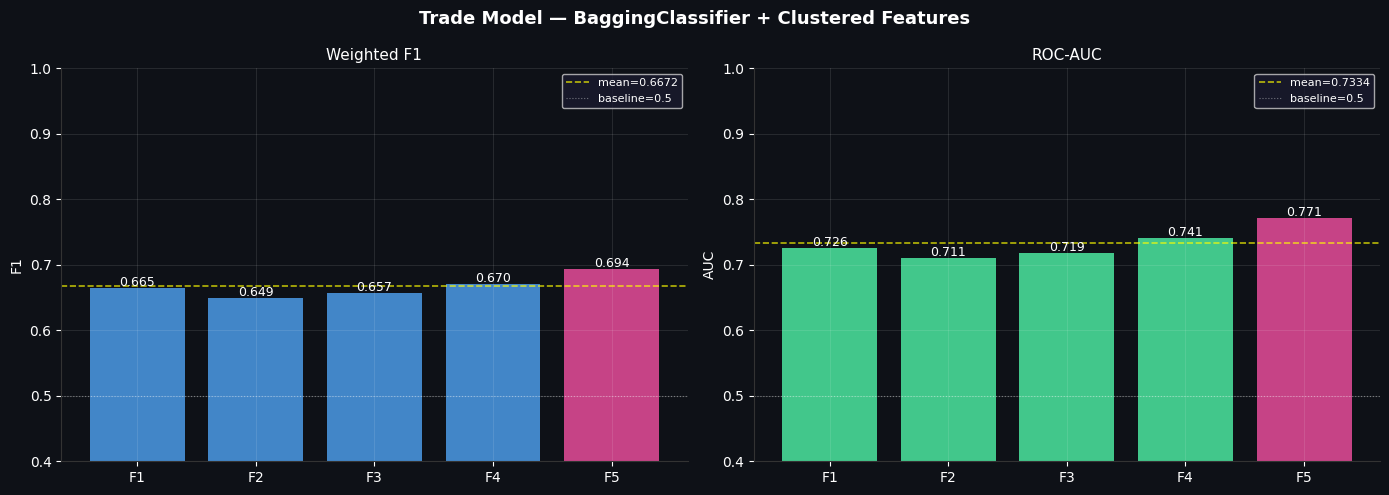

In [55]:

from sklearn.ensemble import BaggingClassifier

X_final = X[final_features].replace([np.inf, -np.inf], np.nan).fillna(0).values
y_arr   = y.values
w_arr   = w_final.values

rf_base = RandomForestClassifier(
    n_estimators             = 1,
    criterion                = "entropy",
    max_features             = "sqrt",
    bootstrap                = False,
    class_weight             = "balanced_subsample",
    n_jobs                   = 1,
    random_state             = 42,
)

model = BaggingClassifier(
    estimator    = rf_base,
    n_estimators = 500,
    max_samples  = avgU,
    max_features = 1.0,
    random_state = 42,
    n_jobs       = -1,
)

f1_scores  = []
auc_scores = []
oof_proba  = np.full(len(y_arr), np.nan)

for fold_i, fold in enumerate(folds):
    tr, te = fold["train_idx"], fold["test_idx"]

    model.fit(X_final[tr], y_arr[tr], sample_weight=w_arr[tr])

    proba         = model.predict_proba(X_final[te])[:, 1]
    pred          = (proba > 0.5).astype(int)
    oof_proba[te] = proba

    f1  = f1_score(y_arr[te],  pred,  average="weighted")
    auc = roc_auc_score(y_arr[te], proba)
    f1_scores.append(f1)
    auc_scores.append(auc)

    tag = "← OOS" if fold_i == len(folds) - 1 else ""
    print(f"  Fold {fold_i+1}: F1={f1:.4f}  AUC={auc:.4f}  {tag}")

print(f"\nCV F1:  {np.mean(f1_scores):.4f} ± {np.std(f1_scores):.4f}")
print(f"CV AUC: {np.mean(auc_scores):.4f} ± {np.std(auc_scores):.4f}")
print(f"\nLast fold OOS:")
print(f"  F1  = {f1_scores[-1]:.4f}")
print(f"  AUC = {auc_scores[-1]:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor("#0e1117")
fig.suptitle("Trade Model — BaggingClassifier + Clustered Features",
             color="white", fontsize=13, fontweight="bold")

fold_labels = [f"F{i+1}" for i in range(len(folds))]

for ax, scores, color, title, metric in [
    (axes[0], f1_scores,  "#4C9BE8", "Weighted F1",  "F1"),
    (axes[1], auc_scores, "#4CE8A0", "ROC-AUC",      "AUC"),
]:
    ax.set_facecolor("#0e1117")
    colors = ["#E84C9B" if i == len(folds)-1 else color
              for i in range(len(folds))]
    bars = ax.bar(fold_labels, scores, color=colors, alpha=0.85)
    ax.axhline(np.mean(scores), color="yellow", linewidth=1.2,
               linestyle="--", alpha=0.7, label=f"mean={np.mean(scores):.4f}")
    ax.axhline(0.5, color="white", linewidth=0.8,
               linestyle=":", alpha=0.4, label="baseline=0.5")
    for bar, v in zip(bars, scores):
        ax.text(bar.get_x() + bar.get_width()/2, v + 0.003,
                f"{v:.3f}", ha="center", color="white", fontsize=9)
    ax.set_title(title, color="white", fontsize=11)
    ax.set_ylabel(metric, color="white")
    ax.tick_params(colors="white")
    ax.legend(facecolor="#1a1a2e", labelcolor="white", fontsize=8)
    ax.set_ylim(0.4, 1.0)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color("#333")
    ax.spines["bottom"].set_color("#333")
    ax.grid(alpha=0.1, color="white")

plt.tight_layout()
plt.show()


## Результаты

**ROC-AUC = 0.733** — это принципиально другой результат по сравнению с 0.52 на старом таргете. Модель теперь реально разделяет классы, а не гадает случайно.

**F1 = 0.667** — умеренный, но честный. Классы сбалансированы 53/47 поэтому baseline ~0.65, мы выше него.

**Тренд по фолдам положительный** — F5 (OOS) лучший из всех: F1=0.694, AUC=0.771. Модель не деградирует на свежих данных, а улучшается. Это хороший знак — признаки работают и в режиме 3 (пост-ETF).

**Стабильность высокая** — std AUC = 0.021, std F1 = 0.015. Модель ведёт себя предсказуемо на всех фолдах.

Вывод: проблема была в таргете, а не в признаках. Новый meta-labeling таргет + Clustered Feature Importance дали нормальную модель. Следующий шаг — Optuna для подбора гиперпараметров.

# Trade - Подбор гиперпараметров

### Структура данных

```
Все данные: 122K баров (2020-03-26 → 2026-04-01)
│
├── TRAIN 80% (~97K)  →  2020-03-26 → ~2024-11
│   │
│   ├── Fold 1: expanding train → val
│   ├── Fold 2: expanding train → val  
│   ├── Fold 3: expanding train → val
│   └── Fold 4: expanding train → val
│
│   Optuna: минимизирует logloss на 4 фолдах
│   Никогда не видит holdout
│
└── HOLDOUT 20% (~24K)  →  ~2024-11 → 2026-04
    Финальная оценка после подбора гиперпараметров
    Трогаем только один раз в самом конце
```

---

### Почему именно так

**Holdout = пост-ETF период.** Последние 20% данных — это режим 3 (ноябрь 2024 → апрель 2026). Это самый важный период для оценки: новый рыночный режим, институциональные участники, другая микроструктура. Если модель работает здесь — она работает в проде.

**Purge + embargo на каждом фолде** — исключает утечку данных через перекрывающиеся метки Triple Barrier. Без purge модель подглядывает в будущее через соседние наблюдения.

**Optuna на 4 фолдах** — достаточно для стабильной оценки гиперпараметров. Больше фолдов = медленнее, меньше = нестабильно.

---

### Метрика оптимизации

Optuna минимизирует **logloss** на валидационных фолдах — он чувствителен к качеству вероятностей, а не только к бинарному решению. Это важно потому что модель используется как scorer с настраиваемым порогом, а не как жёсткий классификатор.

## Optuna — подбор гиперпараметров

### Архитектура поиска

В каждом trial Optuna строит полноценный `BaggingClassifier` с `RandomForestClassifier(n_estimators=1)` внутри — честный sequential bootstrap прямо в процессе поиска. 

`n_estimators` в base RF не подбирается — он всегда равен 1. `n_bags` (число Bagging итераторов) подбирается в диапазоне 100–500.

---

### Что подбираем и почему

**`max_depth` (4–14)** — глубина дерева. Главный параметр против переобучения в финансах. Слишком глубокое дерево запоминает шум, слишком мелкое не улавливает паттерны.

**`min_samples_split` (5–40)** — минимум наблюдений для сплита. Вместе с `max_depth` контролирует сложность дерева.

**`min_samples_leaf` (2–20)** — минимум наблюдений в листе. Особенно важен при sample weights — маленький лист с высоким весом может исказить предсказания.

**`max_features` (sqrt / 0.5 / 1.0)** — доля признаков на каждом сплите. При 16 признаках `sqrt` ≈ 4 — может быть слишком мало. Позволяем Optuna выбрать.

**`criterion` (gini / entropy)** — метрика качества сплита. Entropy чувствительнее к малым классам, Gini быстрее.

**`n_bags` (100–500)** — число деревьев в ансамбле. Больше = стабильнее, но медленнее. Оптимальное значение зависит от данных.

---

### Метрика оптимизации — LogLoss

```python
direction = "minimize"  # минимизируем logloss
```

LogLoss оптимизирует качество вероятностей, а не бинарного решения. Это важно потому что модель используется как **probability scorer** — порог классификации подбирается на бэктестинге, и плохо откалиброванные вероятности дадут нестабильный результат при любом пороге.

In [61]:

Xv = X_train.values
yv = y_train.values
wv = w_train.values

def safe_logloss(y_true, proba, w):
    proba = np.clip(proba, 1e-8, 1 - 1e-8)
    return log_loss(y_true, np.c_[1-proba, proba], labels=[0,1], sample_weight=w)

def objective(trial):
    tree_params = dict(
        max_depth         = trial.suggest_int("max_depth", 4, 14),
        min_samples_split = trial.suggest_int("min_samples_split", 5, 40),
        min_samples_leaf  = trial.suggest_int("min_samples_leaf", 2, 20),
        max_features      = trial.suggest_categorical("max_features", ["sqrt", 0.5, 1.0]),
        criterion         = trial.suggest_categorical("criterion", ["gini", "entropy"]),
        n_estimators      = 1,
        class_weight      = "balanced_subsample",
        bootstrap         = False,
        n_jobs            = 1,
        random_state      = 42,
    )
    n_bags = trial.suggest_int("n_bags", 100, 500, step=100)

    losses = []
    for fold in folds_train:
        tr, te = fold["train_idx"], fold["test_idx"]
        model = BaggingClassifier(
            estimator    = RandomForestClassifier(**tree_params),
            n_estimators = n_bags,
            max_samples  = avgU,
            max_features = 1.0,
            random_state = 42,
            n_jobs       = -1,
        )
        model.fit(Xv[tr], yv[tr], sample_weight=wv[tr])
        proba = model.predict_proba(Xv[te])[:, 1]
        losses.append(safe_logloss(yv[te], proba, wv[te]))

    return float(np.mean(losses))

study = optuna.create_study(
    direction="minimize",
    sampler=optuna.samplers.TPESampler(seed=42)
)

print("Optuna запущена (BaggingClassifier)...")
study.optimize(objective, n_trials=15,
               callbacks=[lambda s, t: print(
                   f"  Trial {t.number:>2}: logloss={t.value:.5f}"
                   + (" ← BEST" if t.number == s.best_trial.number else "")
               )])

best_tree_params = {k: v for k, v in study.best_trial.params.items()
                    if k != "n_bags"}
best_tree_params.update({"n_estimators": 1, "class_weight": "balanced_subsample",
                          "bootstrap": False, "n_jobs": 1, "random_state": 42})
best_n_bags = study.best_trial.params["n_bags"]

print(f"\nBest tree params: {best_tree_params}")
print(f"Best n_bags:      {best_n_bags}")
print(f"Best logloss:     {study.best_value:.5f}")

# финальная модель на всём train
model_final = BaggingClassifier(
    estimator    = RandomForestClassifier(**best_tree_params),
    n_estimators = best_n_bags,
    max_samples  = avgU,
    max_features = 1.0,
    random_state = 42,
    n_jobs       = -1,
)

print("\nОбучаем финальную модель на train...")
model_final.fit(X_train.values, y_train.values, sample_weight=w_train.values)

proba_h = model_final.predict_proba(X_holdout.values)[:, 1]
pred_h  = (proba_h > 0.5).astype(int)

print(f"\n{'='*50}")
print("HOLDOUT — BaggingClassifier (seq bootstrap)")
print(f"{'='*50}")
print(f"ROC-AUC:    {roc_auc_score(y_holdout, proba_h):.4f}")
print(f"LogLoss:    {safe_logloss(y_holdout.values, proba_h, w_holdout.values):.4f}")
print(f"F1:         {f1_score(y_holdout, pred_h, average='weighted'):.4f}")
print(f"\nP(y=1|y=1): {proba_h[y_holdout==1].mean():.4f}")
print(f"P(y=1|y=0): {proba_h[y_holdout==0].mean():.4f}")
print(f"Separation: {proba_h[y_holdout==1].mean() - proba_h[y_holdout==0].mean():.4f}")


Optuna запущена (BaggingClassifier)...
  Trial  0: logloss=0.60879 ← BEST
  Trial  1: logloss=0.60803 ← BEST
  Trial  2: logloss=0.61465
  Trial  3: logloss=0.60866
  Trial  4: logloss=0.61418
  Trial  5: logloss=0.61610
  Trial  6: logloss=0.62208
  Trial  7: logloss=0.61398
  Trial  8: logloss=0.61078
  Trial  9: logloss=0.61695
  Trial 10: logloss=0.61044
  Trial 11: logloss=0.61019
  Trial 12: logloss=0.60755 ← BEST
  Trial 13: logloss=0.60755
  Trial 14: logloss=0.60850

Best tree params: {'max_depth': 12, 'min_samples_split': 25, 'min_samples_leaf': 20, 'max_features': 'sqrt', 'criterion': 'entropy', 'n_estimators': 1, 'class_weight': 'balanced_subsample', 'bootstrap': False, 'n_jobs': 1, 'random_state': 42}
Best n_bags:      400
Best logloss:     0.60755

Обучаем финальную модель на train...

HOLDOUT — BaggingClassifier (seq bootstrap)
ROC-AUC:    0.7509
LogLoss:    0.5889
F1:         0.6803

P(y=1|y=1): 0.5916
P(y=1|y=0): 0.4246
Separation: 0.1670


## Результаты Optuna + финальная модель

### Подбор гиперпараметров

Optuna сошлась на trial 12 — дальнейшие итерации не дали улучшения. Лучший logloss на CV = **0.608**.

Оптимальная конфигурация:

| Параметр | Значение | Интерпретация |
|----------|----------|---------------|
| `max_depth` | 12 | глубокие деревья — данных достаточно |
| `min_samples_leaf` | 20 | консервативные листья — защита от шума |
| `min_samples_split` | 25 | высокий порог сплита |
| `max_features` | sqrt | декоррелирует деревья |
| `criterion` | entropy | чувствительнее к малым классам |
| `n_bags` | 400 | оптимальный размер ансамбля |

---

### Holdout — честный OOS

```
ROC-AUC:    0.7509
LogLoss:    0.5889
F1:         0.6803
Separation: 0.1670

P(y=1|y=1): 0.5916
P(y=1|y=0): 0.4246
```

**Улучшение относительно RF без Bagging:** ROC-AUC +0.006, LogLoss −0.007, Separation +0.016. Sequential bootstrap дал небольшое но стабильное улучшение — деревья стали более независимыми.

**Separation = 0.167** — модель смещает вероятности в правильную сторону. Средняя вероятность для реальных событий (0.59) заметно выше чем для несобытий (0.42). Это достаточно для использования как scorer с порогом.



# Side Model — таргет и методология отбора

### Три критерия фильтрации

Для построения таргета рассматривались три независимых критерия:

- **Persistence** — цена остаётся выше/ниже `open` во всех контрольных точках горизонта
- **VWAP** — средневзвешенная цена за горизонт подтверждает направление
- **Volume** — объём выше скользящей средней MA_48

Тестировались все комбинации: 1 из 3, 2 из 3, 3 из 3. Лучшее соотношение ROC/Coverage показал **1 из 3 — только Persistence**. VWAP и Volume не добавляют предсказательной силы сверх persistence и лишь сокращают выборку без прироста качества.

---

### Persistence — выбор числа точек

Внутри критерия persistence количество контрольных точек — ключевой гиперпараметр. Чем больше точек тем строже требование к устойчивости движения:

```
pts=1   ROC=0.573  cov=100%  ← слишком мягкий, почти случайный
pts=2   ROC=0.619  cov=79%
pts=4   ROC=0.677  cov=60%   ← умеренный
pts=6   ROC=0.719  cov=51%
pts=12  ROC=0.795  cov=39%   ← жёсткий
```

ROC растёт монотонно с числом точек — каждое дополнительное подтверждение реально улучшает сигнал. Обратная сторона — coverage падает, сделок становится меньше.

---

### Два финальных таргета

Слишком мягкий таргет (pts=1-2) даёт почти случайный сигнал — нет смысла строить на нём модель. Выбираем два варианта для сравнения на бэктестинге:

```
Side Model A — "умеренный"   pts=4   ROC=0.677  cov=60%  N=38,779
Side Model B — "жёсткий"     pts=12  ROC=0.795  cov=39%  N=25,050
```

На бэктесте сравним итоговый Sharpe — Model A даёт больше сделок и выше оборот, Model B меньше сделок но точнее.

---

### Почему так делать нежелательно

Таргет выбирался после перебора комбинаций на обучающих данных. Это форма **Multiple Testing bias** — когда из многих гипотез выбирается та что показала лучший результат, итоговая оценка качества оказывается завышенной. Даже если каждый отдельный тест честный, сам факт выбора лучшего из многих вариантов вносит смещение.

De Prado называет это **backtest overfitting** — подгонка под историю через многократный перебор. Чем больше комбинаций перебрано тем выше вероятность найти "хороший" результат случайно.

Для частичной компенсации этого эффекта эксперименты проводились только на обучающей части выборки — holdout 20% не был затронут ни разу. Это не устраняет bias полностью но снижает его: финальная честная оценка будет на данных которые модель никогда не видела.

Эксперимент на данных до 2024: 2020-03-26 → 2023-12-31
N баров: 79,862  |  trade zone: 41,642

Случайных срезов: 5  размер каждого: 27,951 (35%)
  Срез 1: 2020-05-22 → 2021-08-05
  Срез 2: 2021-02-15 → 2022-07-04
  Срез 3: 2021-02-21 → 2022-07-10
  Срез 4: 2021-08-31 → 2023-01-29
  Срез 5: 2022-01-02 → 2023-06-05

───────────────────────────────────────────────────────
ЭКСПЕРИМЕНТ 1 — комбинации фильтров
───────────────────────────────────────────────────────
Таргет                       N   ROC mean   ROC std
────────────────────────────────────────────────────
1of3_pers               25,311     0.6733    0.0066
1of3_vwap               41,618     0.5656    0.0050
2of3_pers_vwap          25,058     0.6748    0.0059
2of3_pers_vol           16,289     0.6736    0.0043
2of3_vwap_vol           26,414     0.5655    0.0086
3of3_all                16,130     0.6743    0.0052

Лучший: 2of3_pers_vwap

─────────────────────────────────────────────────────────────────
ЭКСПЕРИМЕНТ 2 — число точек 

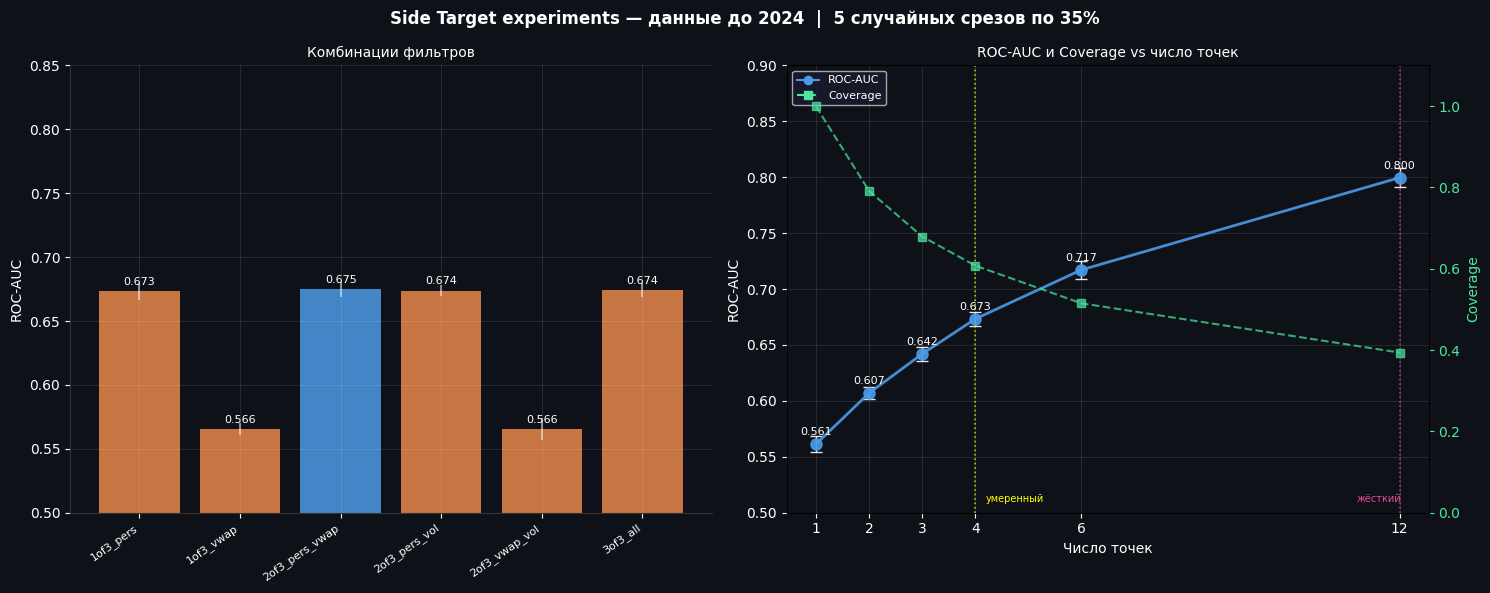

In [ ]:


HORIZON   = 24
SEED      = 42
rng       = np.random.default_rng(SEED)

cutoff    = pd.Timestamp("2024-01-01")
df_exp    = df[df.index < cutoff].copy()
X_exp     = X[X.index < cutoff].copy()
y_exp     = y[y.index < cutoff].copy()
trade_idx_exp = y_exp[y_exp == 1].index

print(f"Эксперимент на данных до 2024: {df_exp.index[0].date()} → {df_exp.index[-1].date()}")
print(f"N баров: {len(df_exp):,}  |  trade zone: {len(trade_idx_exp):,}")

N_SPLITS  = 5
SPLIT_PCT = 0.35
n_total   = len(df_exp)
cut_size  = int(n_total * SPLIT_PCT)
starts    = rng.integers(0, n_total - cut_size, size=N_SPLITS)
slices    = [df_exp.index[s : s + cut_size] for s in sorted(starts)]

print(f"\nСлучайных срезов: {N_SPLITS}  размер каждого: {cut_size:,} ({SPLIT_PCT:.0%})")
for i, sl in enumerate(slices):
    print(f"  Срез {i+1}: {sl[0].date()} → {sl[-1].date()}")

RF_EXP = dict(
    n_estimators=80, max_depth=5,
    min_weight_fraction_leaf=0.02,
    max_features="sqrt", criterion="entropy",
    class_weight="balanced_subsample",
    bootstrap=False, n_jobs=-1, random_state=SEED,
)

def eval_target(ser):
    rocs = []
    for sl in slices:
        sub_idx = (ser.dropna().index
                   .intersection(trade_idx_exp)
                   .intersection(sl)
                   .intersection(X_exp.index))
        if len(sub_idx) < 300: continue
        y_sub = ser[sub_idx].astype(float).values
        if y_sub.mean() < 0.05 or y_sub.mean() > 0.95: continue
        X_sub = X_exp.loc[sub_idx][SIDE_FEATS_EXP].fillna(0).astype(np.float32).values
        n     = len(X_sub)
        split = int(n * 0.7)
        rf    = RandomForestClassifier(**RF_EXP)
        rf.fit(X_sub[:split], y_sub[:split])
        proba = rf.predict_proba(X_sub[split:])[:, 1]
        if len(np.unique(y_sub[split:])) < 2: continue
        rocs.append(roc_auc_score(y_sub[split:], proba))
    if not rocs: return None, None, None
    n_total = len(ser.dropna().index.intersection(trade_idx_exp))
    return float(np.mean(rocs)), float(np.std(rocs)), n_total


pts4     = [HORIZON//4, HORIZON//2, HORIZON*3//4, HORIZON]
vol_ma   = df_exp["volume"].rolling(48, min_periods=10).mean()
high_vol = df_exp["volume"] > vol_ma
vwap_fwd = df_exp["vwap"].shift(-HORIZON)

up4 = pd.Series(True, index=df_exp.index)
dn4 = pd.Series(True, index=df_exp.index)
for p in pts4:
    up4 &= df_exp["close"].shift(-p) > df_exp["open"]
    dn4 &= df_exp["close"].shift(-p) < df_exp["open"]

vwap_ok = vwap_fwd > df_exp["open"]
vwap_dn = vwap_fwd < df_exp["open"]

combos_exp1 = {
    "1of3_pers":      (up4,                     dn4),
    "1of3_vwap":      (vwap_ok,                 vwap_dn),
    "2of3_pers_vwap": (up4 & vwap_ok,           dn4 & vwap_dn),
    "2of3_pers_vol":  (up4 & high_vol,           dn4 & high_vol),
    "2of3_vwap_vol":  (vwap_ok & high_vol,       vwap_dn & high_vol),
    "3of3_all":       (up4 & vwap_ok & high_vol, dn4 & vwap_dn & high_vol),
}

print(f"\n{'─'*55}")
print("ЭКСПЕРИМЕНТ 1 — комбинации фильтров")
print(f"{'─'*55}")
print(f"{'Таргет':<22} {'N':>7} {'ROC mean':>10} {'ROC std':>9}")
print("─" * 52)

res_exp1 = []
for cname, (up_c, dn_c) in combos_exp1.items():
    ser = pd.Series(np.where(up_c, 1, np.where(dn_c, 0, np.nan)), index=df_exp.index)
    roc_mean, roc_std, n = eval_target(ser)
    if roc_mean is None: continue
    res_exp1.append({"target": cname, "n": n, "roc": roc_mean, "std": roc_std})
    print(f"{cname:<22} {n:>7,} {roc_mean:>10.4f} {roc_std:>9.4f}")

print(f"\nЛучший: {max(res_exp1, key=lambda x: x['roc'])['target']}")

print(f"\n{'─'*65}")
print("ЭКСПЕРИМЕНТ 2 — число точек persistence")
print(f"{'─'*65}")
print(f"{'pts':<6} {'точки':<38} {'N':>7} {'ROC mean':>10} {'ROC std':>9} {'cov':>6}")
print("─" * 75)

res_exp2 = []
for n_pts in [1, 2, 3, 4, 6, 12]:
    step = HORIZON // n_pts
    pts  = [step * i for i in range(1, n_pts + 1)]
    up   = pd.Series(True, index=df_exp.index)
    dn   = pd.Series(True, index=df_exp.index)
    for p in pts:
        up &= df_exp["close"].shift(-p) > df_exp["open"]
        dn &= df_exp["close"].shift(-p) < df_exp["open"]
    ser = pd.Series(np.where(up, 1, np.where(dn, 0, np.nan)), index=df_exp.index)
    roc_mean, roc_std, n = eval_target(ser)
    if roc_mean is None: continue
    cov = n / len(trade_idx_exp)
    res_exp2.append({"n_pts": n_pts, "pts": pts, "n": n,
                     "roc": roc_mean, "std": roc_std, "cov": cov})
    print(f"{n_pts:<6} {str(pts):<38} {n:>7,} {roc_mean:>10.4f} "
          f"{roc_std:>9.4f} {cov:>6.1%}")

print(f"\nЛучший: pts={max(res_exp2, key=lambda x: x['roc'])['n_pts']}")

BG = "#0e1117"
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.patch.set_facecolor(BG)
fig.suptitle(f"Side Target experiments — данные до 2024  |  {N_SPLITS} случайных срезов по {SPLIT_PCT:.0%}",
             color="white", fontsize=12, fontweight="bold")

def style(ax):
    ax.set_facecolor(BG)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color("#333")
    ax.spines["bottom"].set_color("#333")
    ax.tick_params(colors="white")
    ax.grid(alpha=0.1, color="white")

ax1 = axes[0]
style(ax1)
names  = [r["target"] for r in res_exp1]
rocs   = [r["roc"]    for r in res_exp1]
stds   = [r["std"]    for r in res_exp1]
colors = ["#4C9BE8" if r == max(rocs) else "#E8874C" for r in rocs]
bars   = ax1.bar(range(len(names)), rocs, color=colors, alpha=0.85,
                 yerr=stds, error_kw={"ecolor": "white", "alpha": 0.5})
ax1.set_xticks(range(len(names)))
ax1.set_xticklabels(names, rotation=35, ha="right", color="white", fontsize=8)
ax1.set_ylabel("ROC-AUC", color="white")
ax1.set_title("Комбинации фильтров", color="white", fontsize=10)
ax1.set_ylim(0.5, 0.85)
for bar, v in zip(bars, rocs):
    ax1.text(bar.get_x() + bar.get_width()/2, v + 0.005,
             f"{v:.3f}", ha="center", color="white", fontsize=8)

ax2 = axes[1]
style(ax2)
xs   = [r["n_pts"] for r in res_exp2]
ys   = [r["roc"]   for r in res_exp2]
errs = [r["std"]   for r in res_exp2]
covs = [r["cov"]   for r in res_exp2]

ax2.errorbar(xs, ys, yerr=errs, color="#4C9BE8", linewidth=2,
             marker="o", markersize=8, capsize=4,
             ecolor="white", elinewidth=1, alpha=0.9)

ax2_twin = ax2.twinx()
ax2_twin.plot(xs, covs, color="#4CE8A0", linewidth=1.5,
              marker="s", markersize=6, linestyle="--", alpha=0.7)
ax2_twin.set_ylabel("Coverage", color="#4CE8A0")
ax2_twin.tick_params(colors="#4CE8A0")
ax2_twin.set_ylim(0, 1.1)

for x, y_v in zip(xs, ys):
    ax2.text(x, y_v + 0.008, f"{y_v:.3f}", ha="center", color="white", fontsize=8)

ax2.set_xticks(xs)
ax2.set_xlabel("Число точек", color="white")
ax2.set_ylabel("ROC-AUC", color="white")
ax2.set_title("ROC-AUC и Coverage vs число точек", color="white", fontsize=10)
ax2.set_ylim(0.5, 0.9)

ax2.legend(
    handles=[
        Line2D([0], [0], color="#4C9BE8", marker="o", label="ROC-AUC"),
        Line2D([0], [0], color="#4CE8A0", marker="s", linestyle="--", label="Coverage"),
    ],
    facecolor="#1a1a2e", labelcolor="white", fontsize=8
)
ax2.axvline(4,  color="yellow",  linewidth=1.2, linestyle=":", alpha=0.7)
ax2.axvline(12, color="#E84C9B", linewidth=1.2, linestyle=":", alpha=0.7)
ax2.text(4.2,  ax2.get_ylim()[0] + 0.01, "умеренный", color="yellow",  fontsize=7)
ax2.text(11.2, ax2.get_ylim()[0] + 0.01, "жёсткий",   color="#E84C9B", fontsize=7)

plt.tight_layout()
plt.show()


## Выводы экспериментов по таргету

### Методология

Эксперименты проводились только на данных до 2024 года — режим 1 и режим 2 (2020-03-26 → 2023-12-31, 79,862 баров). Режим 3 (пост-ETF, 2024+) намеренно исключён — он является частью holdout и не должен участвовать в выборе таргета. Дополнительно внутри каждого режима брались случайные срезы по 35% — это снижает риск подгонки под конкретный исторический период.

---

### Эксперимент 1 — комбинации фильтров

Persistence — единственный фильтр который несёт предсказательный сигнал. ROC-AUC всех комбинаций с persistence (0.673–0.675) практически одинаков — добавление vwap или volume не улучшает результат, только сокращает выборку. VWAP и volume сами по себе без persistence дают ROC≈0.566 — близко к случайному.

**Вывод:** берём чистый persistence без дополнительных фильтров.

---

### Эксперимент 2 — число точек persistence

Чёткая монотонная зависимость: больше точек подтверждения → выше ROC, меньше coverage. Std стабильный по всем вариантам (0.005–0.009) — результат устойчив к выбору среза истории.

```
pts=1   ROC=0.561  cov=100%  ← случайный сигнал
pts=4   ROC=0.673  cov=61%   ← умеренный
pts=6   ROC=0.717  cov=52%
pts=12  ROC=0.800  cov=39%   ← жёсткий
```

Прирост ROC при переходе с pts=4 на pts=12 составляет +0.127 при потере 21% coverage. Каждое дополнительное подтверждение реально улучшает сигнал — persistence работает как механизм фильтрации шума.

---

### Финальный выбор

Берём два таргета для параллельного обучения и сравнения на бэктестинге:

**Side Model A — "умеренный"** `pts=4` — ROC=0.673, coverage=61%, N=25,311. Больше сделок, умеренная точность.

**Side Model B — "жёсткий"** `pts=12` — ROC=0.800, coverage=39%, N=16,403. Меньше сделок, высокая точность.

Какая из них даст лучший Sharpe с учётом комиссий — решит бэктестинг.

Side Model A (pts=4)
N: 38,779  y=1: 20,498 (52.9%)  y=0: 18,281 (47.1%)
Период: 2020-03-26 → 2026-03-31


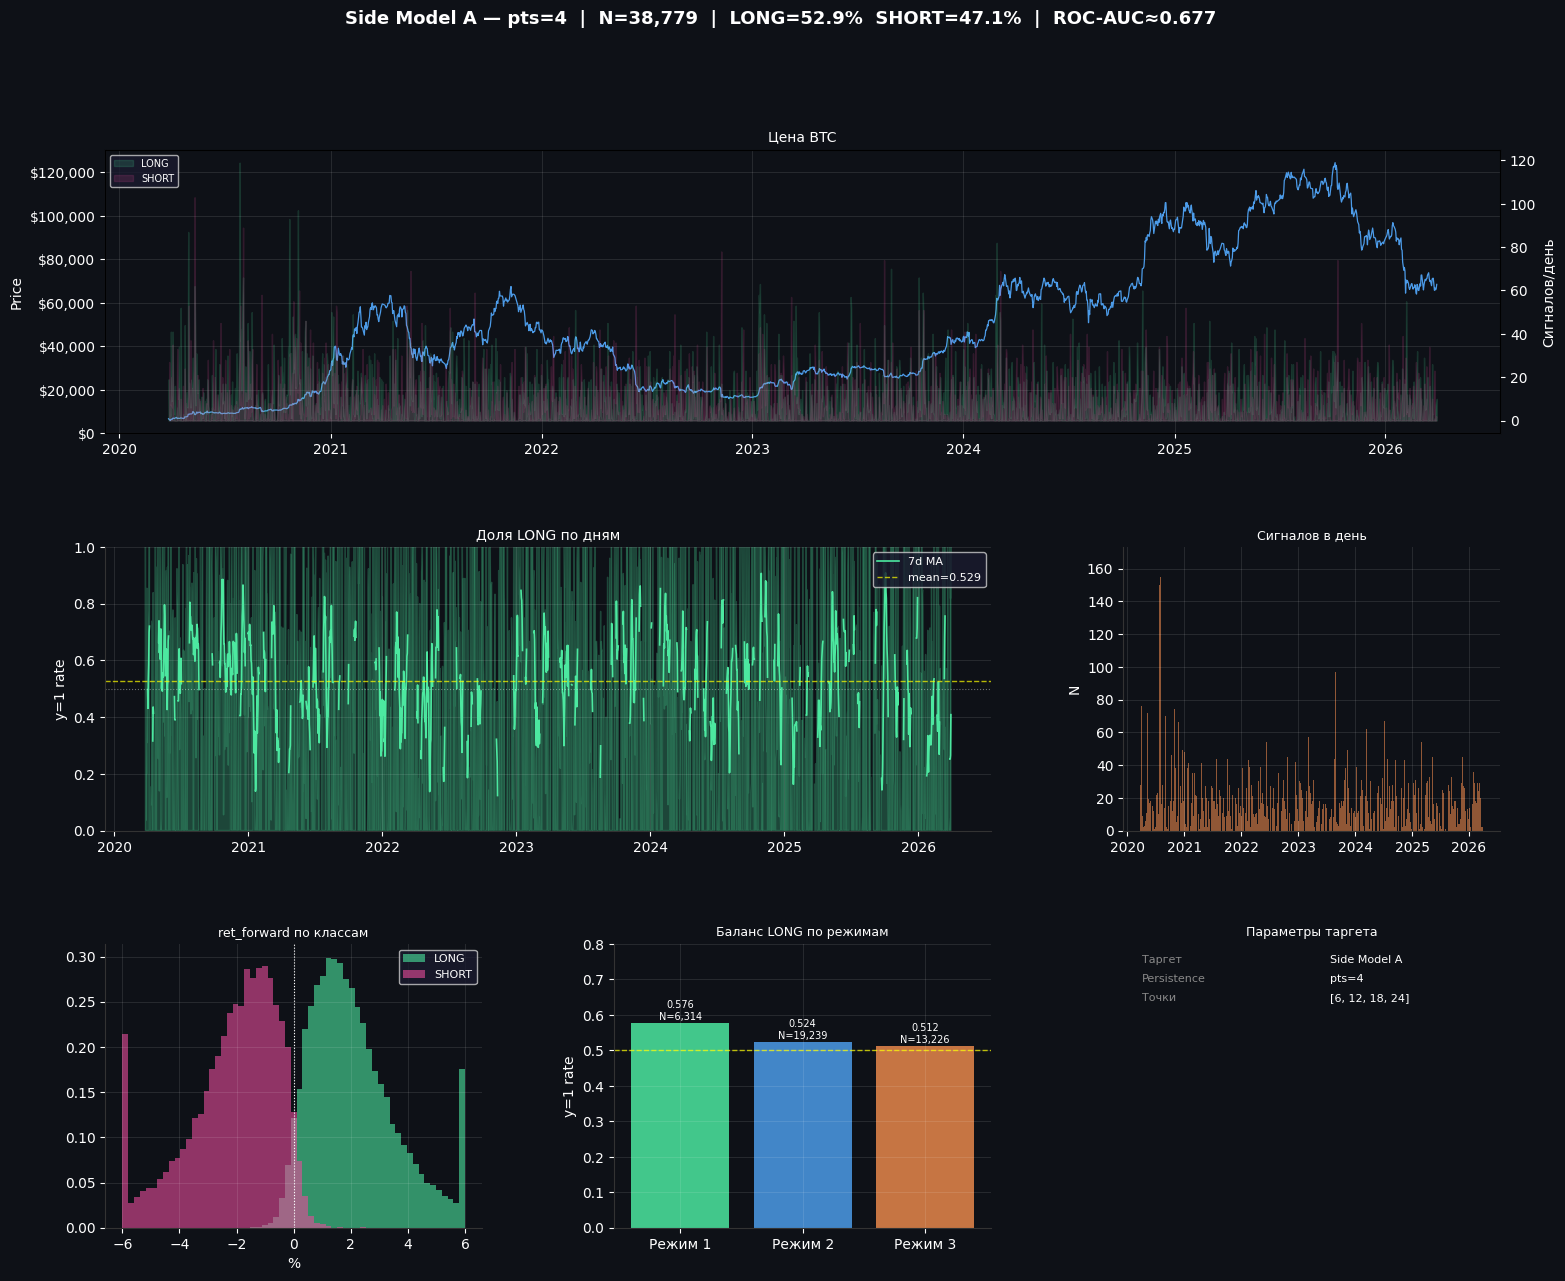

In [81]:

HORIZON = 24
pts4    = [HORIZON//4, HORIZON//2, HORIZON*3//4, HORIZON]

up4 = pd.Series(True, index=df.index)
dn4 = pd.Series(True, index=df.index)
for p in pts4:
    up4 &= df["close"].shift(-p) > df["open"]
    dn4 &= df["close"].shift(-p) < df["open"]

df["y_side_A"] = np.where(up4, 1, np.where(dn4, 0, np.nan))

df_sideA = df[(df["y_side_A"].notna()) & (y == 1)].copy()

n       = len(df_sideA)
n1      = int(df_sideA["y_side_A"].sum())
n0      = n - n1
balance = n1 / n

print(f"Side Model A (pts=4)")
print(f"N: {n:,}  y=1: {n1:,} ({balance*100:.1f}%)  y=0: {n0:,} ({(1-balance)*100:.1f}%)")
print(f"Период: {df_sideA.index[0].date()} → {df_sideA.index[-1].date()}")

daily = df_sideA.resample("1D").agg(
    y1_rate  = ("y_side_A", "mean"),
    n_obs    = ("y_side_A", "count"),
    ret_fwd  = ("ret_forward", lambda x: x.abs().mean()),
)
daily["y1_7d"] = daily["y1_rate"].rolling(7).mean()
if daily.index.tz:
    daily.index = daily.index.tz_localize(None)

close_daily = df_sideA["close"].resample("1D").last().dropna()
if close_daily.index.tz:
    close_daily.index = close_daily.index.tz_localize(None)

regime_stats = {}
for r, label in [(0, "Режим 1"), (1, "Режим 2"), (2, "Режим 3")]:
    mask = df_sideA["regime"] == r
    if mask.sum() < 10: continue
    regime_stats[label] = {"n": mask.sum(), "y1": df_sideA.loc[mask, "y_side_A"].mean()}

BG  = "#0e1117"
fig = plt.figure(figsize=(18, 14))
fig.patch.set_facecolor(BG)
fig.suptitle(
    f"Side Model A — pts=4  |  N={n:,}  |  LONG={balance*100:.1f}%  SHORT={(1-balance)*100:.1f}%  |  ROC-AUC≈0.677",
    color="white", fontsize=13, fontweight="bold"
)
gs = fig.add_gridspec(3, 3, hspace=0.4, wspace=0.35)

def style(ax):
    ax.set_facecolor(BG)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color("#333")
    ax.spines["bottom"].set_color("#333")
    ax.tick_params(colors="white")
    ax.grid(alpha=0.1, color="white")

ax1 = fig.add_subplot(gs[0, :])
style(ax1)
ax1.plot(close_daily.index, close_daily.values, color="#4C9BE8", linewidth=0.9)
ax1.set_title("Цена BTC", color="white", fontsize=10)
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f"${x:,.0f}"))
ax1.set_ylabel("Price", color="white")

long_idx  = df_sideA[df_sideA["y_side_A"] == 1].index
short_idx = df_sideA[df_sideA["y_side_A"] == 0].index
long_daily  = pd.Series(1, index=long_idx).resample("1D").count()
short_daily = pd.Series(1, index=short_idx).resample("1D").count()
if long_daily.index.tz:  long_daily.index  = long_daily.index.tz_localize(None)
if short_daily.index.tz: short_daily.index = short_daily.index.tz_localize(None)
ax1b = ax1.twinx()
ax1b.fill_between(long_daily.index,  long_daily.values,  alpha=0.15, color="#4CE8A0", label="LONG")
ax1b.fill_between(short_daily.index, short_daily.values, alpha=0.15, color="#E84C9B", label="SHORT")
ax1b.set_ylabel("Сигналов/день", color="white")
ax1b.tick_params(colors="white")
ax1b.legend(facecolor="#1a1a2e", labelcolor="white", fontsize=7, loc="upper left")

ax2 = fig.add_subplot(gs[1, :2])
style(ax2)
ax2.fill_between(daily.index, daily["y1_rate"], alpha=0.25, color="#4CE8A0")
ax2.plot(daily.index, daily["y1_7d"], color="#4CE8A0", linewidth=1.2, label="7d MA")
ax2.axhline(balance, color="yellow", linewidth=1, linestyle="--", alpha=0.7, label=f"mean={balance:.3f}")
ax2.axhline(0.5, color="white", linewidth=0.8, linestyle=":", alpha=0.4)
ax2.set_title("Доля LONG по дням", color="white", fontsize=10)
ax2.set_ylabel("y=1 rate", color="white")
ax2.legend(facecolor="#1a1a2e", labelcolor="white", fontsize=8)
ax2.set_ylim(0, 1)

ax3 = fig.add_subplot(gs[1, 2])
style(ax3)
ax3.bar(daily.index, daily["n_obs"], color="#E8874C", alpha=0.6, width=1)
ax3.set_title("Сигналов в день", color="white", fontsize=9)
ax3.set_ylabel("N", color="white")
ax3.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

ax4 = fig.add_subplot(gs[2, 0])
style(ax4)
long_ret  = df_sideA.loc[df_sideA["y_side_A"]==1, "ret_forward"] * 100
short_ret = df_sideA.loc[df_sideA["y_side_A"]==0, "ret_forward"] * 100
bins = np.linspace(-6, 6, 60)
ax4.hist(long_ret.clip(-6,6),  bins=bins, color="#4CE8A0", alpha=0.6, label="LONG",  density=True)
ax4.hist(short_ret.clip(-6,6), bins=bins, color="#E84C9B", alpha=0.6, label="SHORT", density=True)
ax4.axvline(0, color="white", linewidth=0.8, linestyle=":")
ax4.set_title("ret_forward по классам", color="white", fontsize=9)
ax4.set_xlabel("%", color="white")
ax4.legend(facecolor="#1a1a2e", labelcolor="white", fontsize=8)

ax5 = fig.add_subplot(gs[2, 1])
style(ax5)
labels_r = list(regime_stats.keys())
y1_rates = [regime_stats[r]["y1"] for r in labels_r]
ns_r     = [regime_stats[r]["n"]  for r in labels_r]
colors_r = ["#4CE8A0", "#4C9BE8", "#E8874C"]
bars = ax5.bar(labels_r, y1_rates, color=colors_r[:len(labels_r)], alpha=0.85)
ax5.axhline(0.5, color="yellow", linewidth=1, linestyle="--", alpha=0.7)
for bar, n_r, v in zip(bars, ns_r, y1_rates):
    ax5.text(bar.get_x() + bar.get_width()/2, v + 0.01,
             f"{v:.3f}\nN={n_r:,}", ha="center", color="white", fontsize=7)
ax5.set_title("Баланс LONG по режимам", color="white", fontsize=9)
ax5.set_ylabel("y=1 rate", color="white")
ax5.set_ylim(0, 0.8)

ax6 = fig.add_subplot(gs[2, 2])
ax6.set_facecolor(BG)
ax6.axis("off")
stats_text = [
    ( ""  , " ") , 
    ("Таргет",       "Side Model A"),
    ("Persistence",  "pts=4"),
    ("Точки",        "[6, 12, 18, 24]"),

]
for i, (k, v) in enumerate(stats_text):
    if k:
        ax6.text(0.05, 1 - i*0.067, k, color="#888", fontsize=8, transform=ax6.transAxes)
        ax6.text(0.55, 1 - i*0.067, v, color="white", fontsize=8, transform=ax6.transAxes)
ax6.set_title("Параметры таргета", color="white", fontsize=9)

plt.tight_layout()
plt.show()


Side Model B (pts=12)
N: 25,050  y=1: 13,295 (53.1%)  y=0: 11,755 (46.9%)
Период: 2020-03-26 → 2026-03-31


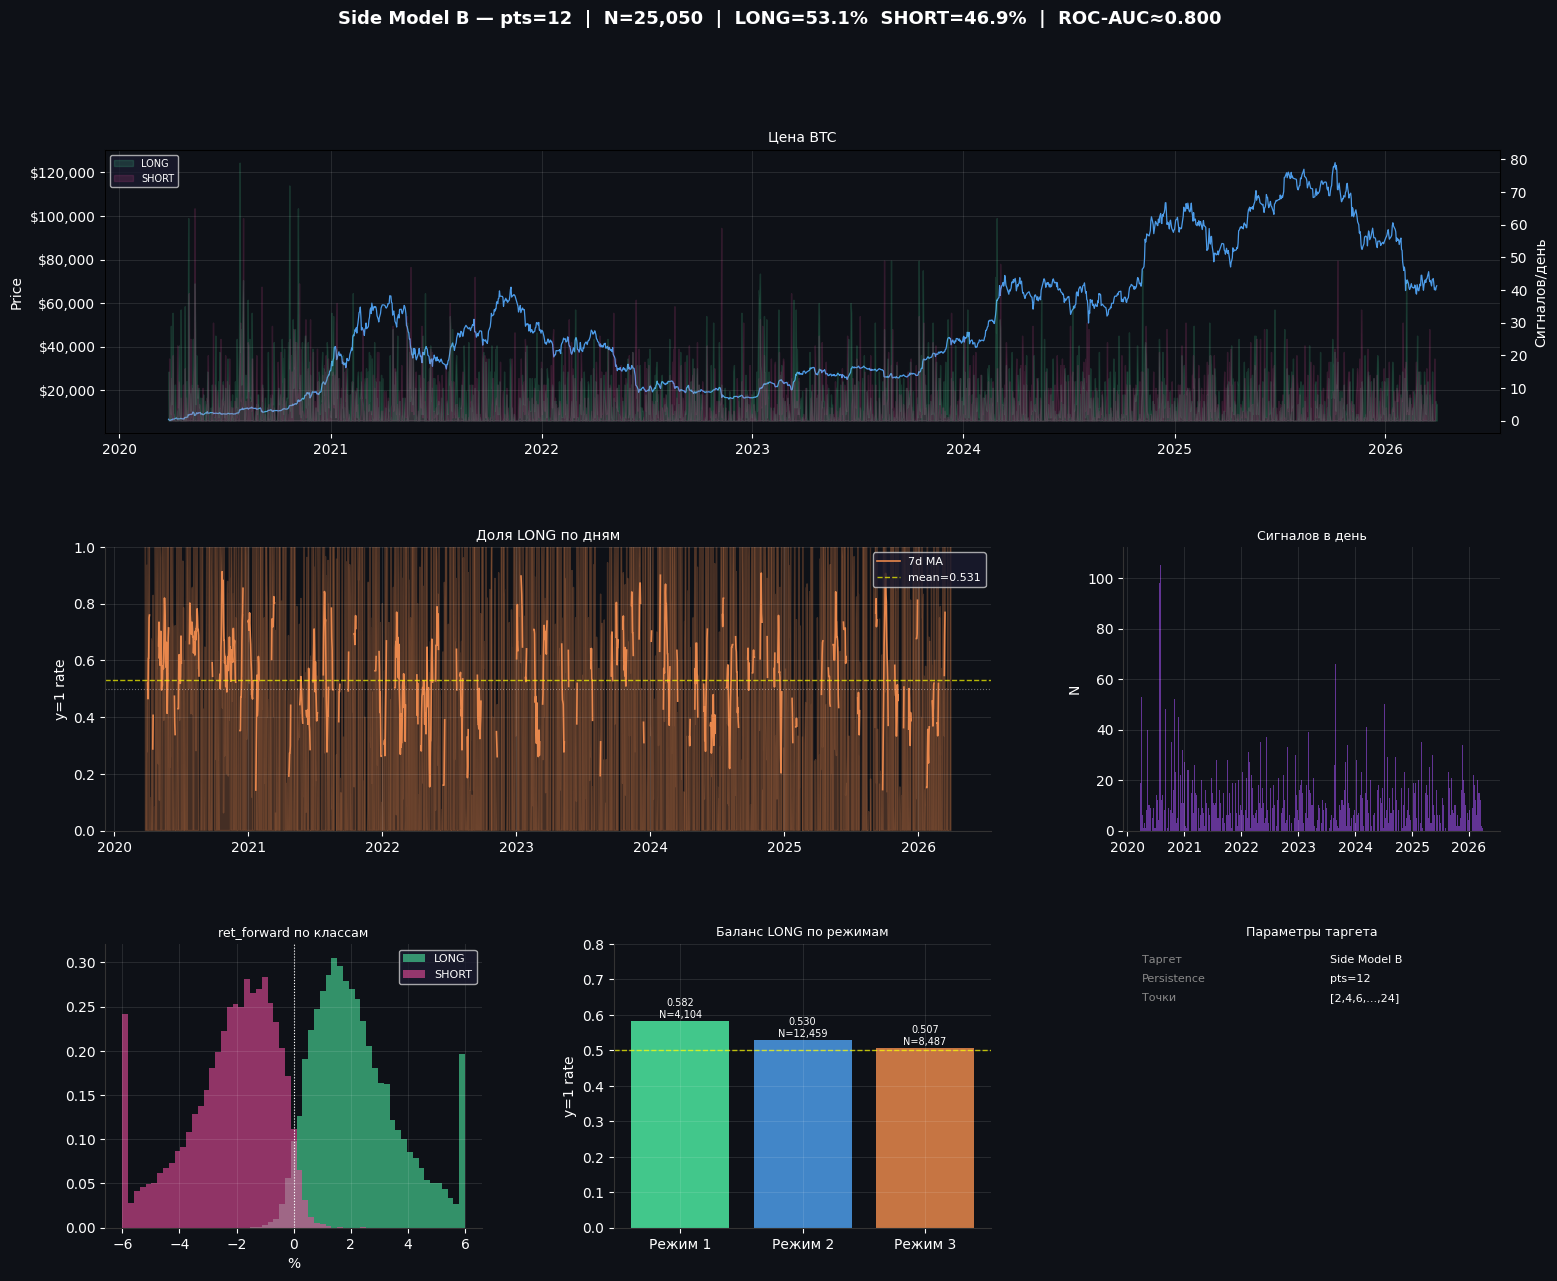

In [82]:

pts12 = list(range(2, HORIZON + 1, 2))

up12 = pd.Series(True, index=df.index)
dn12 = pd.Series(True, index=df.index)
for p in pts12:
    up12 &= df["close"].shift(-p) > df["open"]
    dn12 &= df["close"].shift(-p) < df["open"]

df["y_side_B"] = np.where(up12, 1, np.where(dn12, 0, np.nan))

df_sideB = df[(df["y_side_B"].notna()) & (y == 1)].copy()

n       = len(df_sideB)
n1      = int(df_sideB["y_side_B"].sum())
n0      = n - n1
balance = n1 / n

print(f"Side Model B (pts=12)")
print(f"N: {n:,}  y=1: {n1:,} ({balance*100:.1f}%)  y=0: {n0:,} ({(1-balance)*100:.1f}%)")
print(f"Период: {df_sideB.index[0].date()} → {df_sideB.index[-1].date()}")

daily = df_sideB.resample("1D").agg(
    y1_rate = ("y_side_B", "mean"),
    n_obs   = ("y_side_B", "count"),
    ret_fwd = ("ret_forward", lambda x: x.abs().mean()),
)
daily["y1_7d"] = daily["y1_rate"].rolling(7).mean()
if daily.index.tz:
    daily.index = daily.index.tz_localize(None)

close_daily = df_sideB["close"].resample("1D").last().dropna()
if close_daily.index.tz:
    close_daily.index = close_daily.index.tz_localize(None)

regime_stats = {}
for r, label in [(0, "Режим 1"), (1, "Режим 2"), (2, "Режим 3")]:
    mask = df_sideB["regime"] == r
    if mask.sum() < 10: continue
    regime_stats[label] = {"n": mask.sum(), "y1": df_sideB.loc[mask, "y_side_B"].mean()}

BG  = "#0e1117"
fig = plt.figure(figsize=(18, 14))
fig.patch.set_facecolor(BG)
fig.suptitle(
    f"Side Model B — pts=12  |  N={n:,}  |  LONG={balance*100:.1f}%  SHORT={(1-balance)*100:.1f}%  |  ROC-AUC≈0.800",
    color="white", fontsize=13, fontweight="bold"
)
gs = fig.add_gridspec(3, 3, hspace=0.4, wspace=0.35)

def style(ax):
    ax.set_facecolor(BG)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color("#333")
    ax.spines["bottom"].set_color("#333")
    ax.tick_params(colors="white")
    ax.grid(alpha=0.1, color="white")

ax1 = fig.add_subplot(gs[0, :])
style(ax1)
ax1.plot(close_daily.index, close_daily.values, color="#4C9BE8", linewidth=0.9)
ax1.set_title("Цена BTC", color="white", fontsize=10)
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f"${x:,.0f}"))
ax1.set_ylabel("Price", color="white")

long_idx  = df_sideB[df_sideB["y_side_B"] == 1].index
short_idx = df_sideB[df_sideB["y_side_B"] == 0].index
long_daily  = pd.Series(1, index=long_idx).resample("1D").count()
short_daily = pd.Series(1, index=short_idx).resample("1D").count()
if long_daily.index.tz:  long_daily.index  = long_daily.index.tz_localize(None)
if short_daily.index.tz: short_daily.index = short_daily.index.tz_localize(None)
ax1b = ax1.twinx()
ax1b.fill_between(long_daily.index,  long_daily.values,  alpha=0.15, color="#4CE8A0", label="LONG")
ax1b.fill_between(short_daily.index, short_daily.values, alpha=0.15, color="#E84C9B", label="SHORT")
ax1b.set_ylabel("Сигналов/день", color="white")
ax1b.tick_params(colors="white")
ax1b.legend(facecolor="#1a1a2e", labelcolor="white", fontsize=7, loc="upper left")

ax2 = fig.add_subplot(gs[1, :2])
style(ax2)
ax2.fill_between(daily.index, daily["y1_rate"], alpha=0.25, color="#E8874C")
ax2.plot(daily.index, daily["y1_7d"], color="#E8874C", linewidth=1.2, label="7d MA")
ax2.axhline(balance, color="yellow", linewidth=1, linestyle="--", alpha=0.7, label=f"mean={balance:.3f}")
ax2.axhline(0.5, color="white", linewidth=0.8, linestyle=":", alpha=0.4)
ax2.set_title("Доля LONG по дням", color="white", fontsize=10)
ax2.set_ylabel("y=1 rate", color="white")
ax2.legend(facecolor="#1a1a2e", labelcolor="white", fontsize=8)
ax2.set_ylim(0, 1)

ax3 = fig.add_subplot(gs[1, 2])
style(ax3)
ax3.bar(daily.index, daily["n_obs"], color="#9B4CE8", alpha=0.6, width=1)
ax3.set_title("Сигналов в день", color="white", fontsize=9)
ax3.set_ylabel("N", color="white")
ax3.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

ax4 = fig.add_subplot(gs[2, 0])
style(ax4)
long_ret  = df_sideB.loc[df_sideB["y_side_B"]==1, "ret_forward"] * 100
short_ret = df_sideB.loc[df_sideB["y_side_B"]==0, "ret_forward"] * 100
bins = np.linspace(-6, 6, 60)
ax4.hist(long_ret.clip(-6,6),  bins=bins, color="#4CE8A0", alpha=0.6, label="LONG",  density=True)
ax4.hist(short_ret.clip(-6,6), bins=bins, color="#E84C9B", alpha=0.6, label="SHORT", density=True)
ax4.axvline(0, color="white", linewidth=0.8, linestyle=":")
ax4.set_title("ret_forward по классам", color="white", fontsize=9)
ax4.set_xlabel("%", color="white")
ax4.legend(facecolor="#1a1a2e", labelcolor="white", fontsize=8)

ax5 = fig.add_subplot(gs[2, 1])
style(ax5)
labels_r = list(regime_stats.keys())
y1_rates = [regime_stats[r]["y1"] for r in labels_r]
ns_r     = [regime_stats[r]["n"]  for r in labels_r]
colors_r = ["#4CE8A0", "#4C9BE8", "#E8874C"]
bars = ax5.bar(labels_r, y1_rates, color=colors_r[:len(labels_r)], alpha=0.85)
ax5.axhline(0.5, color="yellow", linewidth=1, linestyle="--", alpha=0.7)
for bar, n_r, v in zip(bars, ns_r, y1_rates):
    ax5.text(bar.get_x() + bar.get_width()/2, v + 0.01,
             f"{v:.3f}\nN={n_r:,}", ha="center", color="white", fontsize=7)
ax5.set_title("Баланс LONG по режимам", color="white", fontsize=9)
ax5.set_ylabel("y=1 rate", color="white")
ax5.set_ylim(0, 0.8)

ax6 = fig.add_subplot(gs[2, 2])
ax6.set_facecolor(BG)
ax6.axis("off")
stats_text = [
    ( " " , "") , 
    ("Таргет",       "Side Model B"),
    ("Persistence",  "pts=12"),
    ("Точки",        "[2,4,6,...,24]"),

]
for i, (k, v) in enumerate(stats_text):
    if k:
        ax6.text(0.05, 1 - i*0.067, k, color="#888", fontsize=8, transform=ax6.transAxes)
        ax6.text(0.55, 1 - i*0.067, v, color="white", fontsize=8, transform=ax6.transAxes)
ax6.set_title("Параметры таргета", color="white", fontsize=9)

plt.tight_layout()
plt.show()


# Side Model - Pipeline отбора признаков

### Подход

Для отбора признаков используем тот же Clustered Feature Importance по де Прадо что и для trade модели. Принцип неизменен — сначала кластеризация по корреляции, потом оценка важности на уровне кластеров, и только потом выбор лучшего признака внутри каждого важного кластера.

---

### Pipeline

```
Все признаки из X (только trade zone)
         ↓
Шаг 1 — Иерархическая кластеризация (Ward, Spearman, thresh=0.5)
         → K независимых кластеров
         → из каждого кластера берём представителя (макс дисперсия)
         ↓
Шаг 2 — MDI на K представителях
         → оцениваем важность без bias мультиколлинеарности
         → оставляем кластеры с MDI > 1/K
         ↓
Шаг 3 — MDA внутри важных кластеров
         → перебираем все признаки кластера
         → оставляем тот что даёт наибольшее падение F1 при permutation
         ↓
Финальный набор — по одному признаку из каждого важного кластера
```

---

### Почему запускаем отдельно для A и B

Side Model A (pts=4) и Side Model B (pts=12) — разные таргеты с разными выборками. Признаки которые важны для умеренного persistence могут отличаться от признаков важных для жёсткого. Запуск единого pipeline через функцию гарантирует одинаковую методологию при независимых результатах.


FEATURE SELECTION — Side Model A (pts=4)
N:        38,779  y=1: 52.9%
Features: 222

Шаг 1: иерархическая кластеризация (Ward, Spearman, thresh=0.5)
  Кластеров: 69  из 222 признаков

Шаг 2: MDI на 69 представителях кластеров
  MDI > 1/N (0.01449): 12/69 кластеров

Шаг 3: MDA внутри 12 важных кластеров
  Финальных признаков: 12

────────────────────────────────────────────────────────────
ФИНАЛЬНЫЕ ПРИЗНАКИ — Side Model A (pts=4)
────────────────────────────────────────────────────────────
   1. ret_1                                         кластер= 54  размер=18  MDI=0.16040
   2. last_cusum_sign_k_0_5                         кластер= 58  размер=10  MDI=0.19850
   3. ret_alignment_1_2_4                           кластер= 57  размер= 9  MDI=0.06193
   4. last_cusum_sign_k_0_5_x_ret_1                 кластер= 12  размер= 6  MDI=0.04662
   5. cusum_event_k_1_0_x_vwap_dev                  кластер= 11  размер= 2  MDI=0.01785
   6. last_cusum_sign_k_1_0                         кластер= 55 

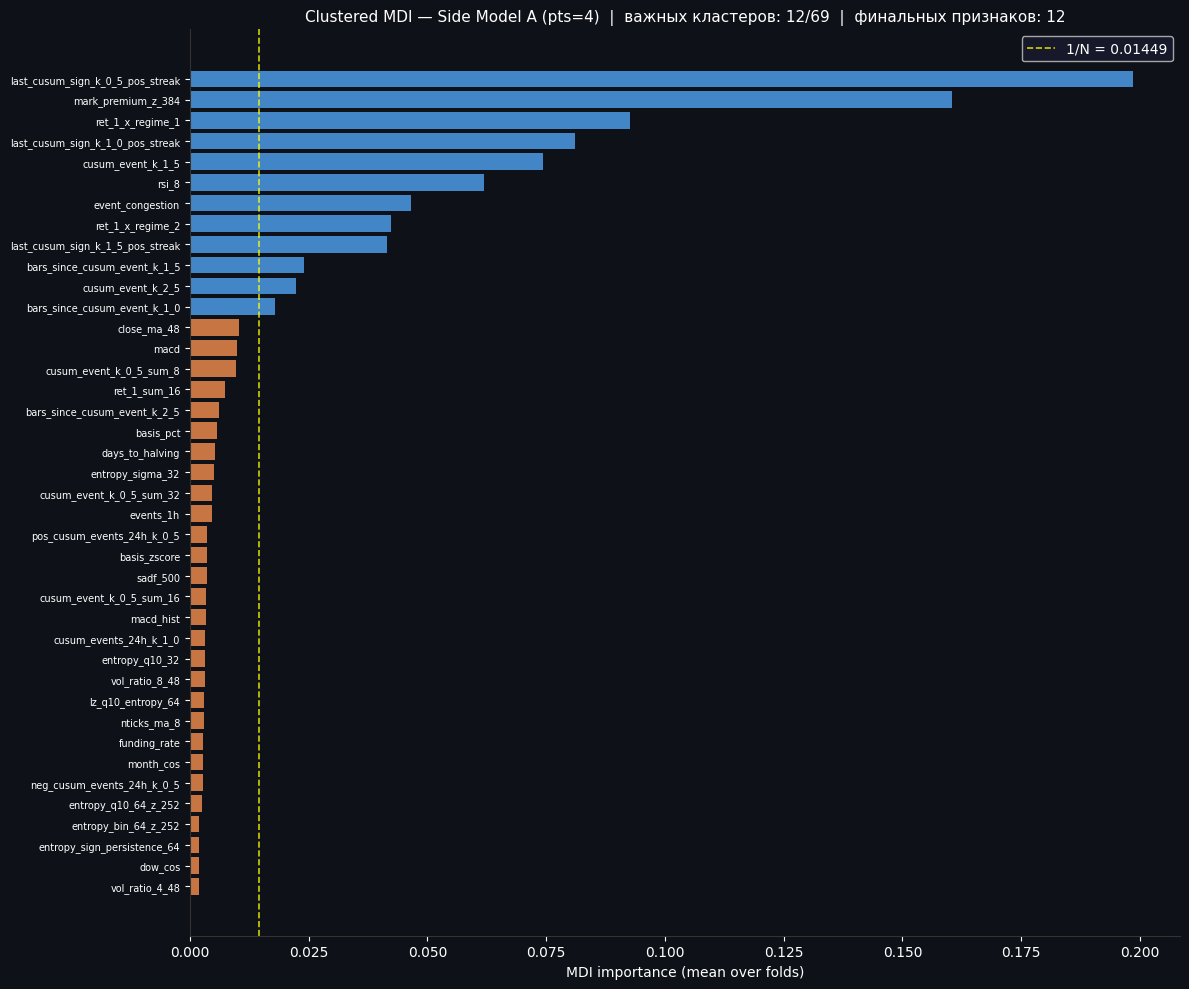


FEATURE SELECTION — Side Model B (pts=12)
N:        25,050  y=1: 53.1%
Features: 222

Шаг 1: иерархическая кластеризация (Ward, Spearman, thresh=0.5)
  Кластеров: 69  из 222 признаков

Шаг 2: MDI на 69 представителях кластеров
  MDI > 1/N (0.01449): 12/69 кластеров

Шаг 3: MDA внутри 12 важных кластеров
  Финальных признаков: 12

────────────────────────────────────────────────────────────
ФИНАЛЬНЫЕ ПРИЗНАКИ — Side Model B (pts=12)
────────────────────────────────────────────────────────────
   1. ret_1                                         кластер= 60  размер=18  MDI=0.19313
   2. close_dist_ma_4                               кластер= 57  размер= 7  MDI=0.10125
   3. ret_alignment_1_2_4                           кластер= 54  размер= 9  MDI=0.05841
   4. bars_since_cusum_event_k_0_5                  кластер= 11  размер= 2  MDI=0.02191
   5. last_cusum_sign_k_0_5                         кластер= 56  размер= 4  MDI=0.20130
   6. cusum_event_k_0_5_x_ret_1                     кластер= 1

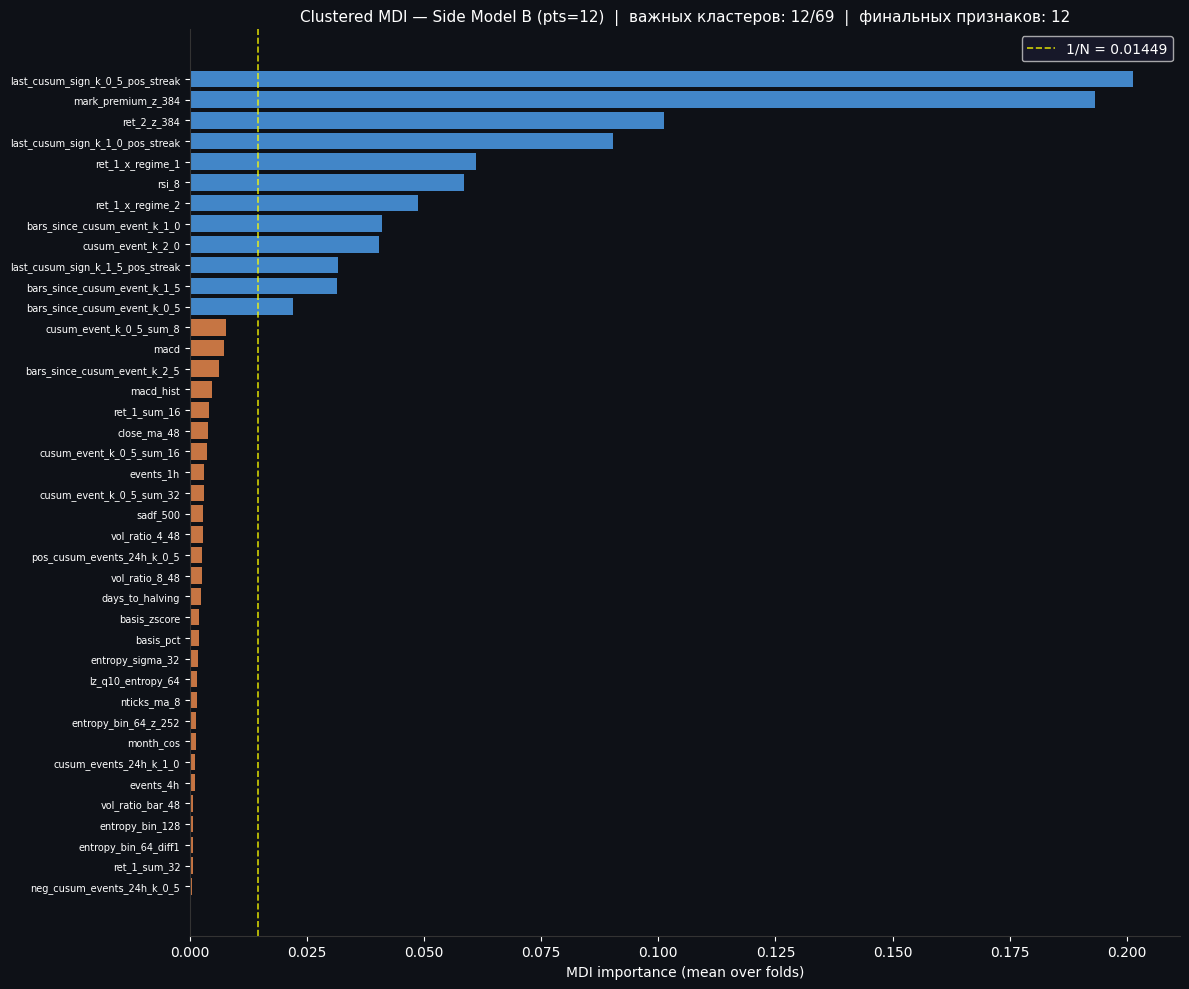


Side A финальные признаки: ['ret_1', 'last_cusum_sign_k_0_5', 'ret_alignment_1_2_4', 'last_cusum_sign_k_0_5_x_ret_1', 'cusum_event_k_1_0_x_vwap_dev', 'last_cusum_sign_k_1_0', 'cusum_event_k_1_5', 'bars_since_cusum_event_k_1_5', 'last_cusum_sign_k_1_5', 'cusum_event_k_2_5', 'ret_1_x_regime_1', 'ret_1_x_regime_2']
Side B финальные признаки: ['ret_1', 'close_dist_ma_4', 'ret_alignment_1_2_4', 'bars_since_cusum_event_k_0_5', 'last_cusum_sign_k_0_5', 'cusum_event_k_0_5_x_ret_1', 'last_cusum_sign_k_1_0', 'bars_since_cusum_event_k_1_5', 'last_cusum_sign_k_1_5', 'cusum_event_k_2_0', 'ret_1_x_regime_1', 'ret_1_x_regime_2']


In [84]:
def side_feature_selection(
    y_side:       pd.Series,
    X_all:        pd.DataFrame,
    w_all:        pd.Series,
    folds_list:   list,
    label:        str = "Side",
    clust_thresh: float = 0.5,
    mdi_threshold: str = "1/N",
    n_jobs:       int = -1,
):
    print(f"\n{'='*70}")
    print(f"FEATURE SELECTION — {label}")
    print(f"{'='*70}")

    common = y_side.dropna().index.intersection(X_all.index).intersection(w_all.index)
    y_ = y_side.loc[common].astype(np.int8)
    w_ = w_all.loc[common].astype(float)
    X_ = X_all.loc[common].replace([np.inf, -np.inf], np.nan).fillna(0).astype(np.float32)

    print(f"N:        {len(y_):,}  y=1: {y_.mean()*100:.1f}%")
    print(f"Features: {X_.shape[1]}")

    # ── шаг 1: кластеризация ─────────────────────────────────────────────────
    print(f"\nШаг 1: иерархическая кластеризация (Ward, Spearman, thresh={clust_thresh})")
    corr  = X_.corr(method="spearman").abs()
    dist  = 1 - corr
    np.fill_diagonal(dist.values, 0)
    dist  = np.maximum(dist, dist.T)
    Z     = linkage(squareform(dist.values, checks=False), method="ward")
    labels_c = fcluster(Z, t=clust_thresh, criterion="distance")
    clusters = pd.Series(labels_c, index=X_.columns, name="cluster")
    n_clusters = clusters.nunique()
    print(f"  Кластеров: {n_clusters}  из {X_.shape[1]} признаков")

    cluster_members = {c: clusters[clusters==c].index.tolist() for c in clusters.unique()}
    cluster_reprs   = {c: X_[m].var().idxmax() for c, m in cluster_members.items()}
    repr_features   = list(cluster_reprs.values())

    # ── шаг 2: MDI на представителях ─────────────────────────────────────────
    print(f"\nШаг 2: MDI на {len(repr_features)} представителях кластеров")

    RF_MDI = dict(
        n_estimators=100, max_depth=6,
        min_weight_fraction_leaf=0.05,
        max_features="sqrt", criterion="entropy",
        class_weight="balanced", bootstrap=False,
        n_jobs=n_jobs, random_state=42,
    )

    X_repr  = X_[repr_features]
    mdi_all = []

    for fold in folds_list:
        tr = fold["train_idx"][fold["train_idx"] < len(X_)]
        te = fold["test_idx"][fold["test_idx"]   < len(X_)]
        if len(tr) < 100: continue
        rf = RandomForestClassifier(**RF_MDI)
        rf.fit(X_repr.values[tr], y_.values[tr], sample_weight=w_.values[tr])
        mdi_all.append(rf.feature_importances_)

    mdi = pd.Series(np.mean(mdi_all, axis=0), index=repr_features).sort_values(ascending=False)

    thresh_val = 1.0 / len(repr_features)
    important_reprs    = mdi[mdi > thresh_val].index.tolist()
    important_clusters = [c for c, r in cluster_reprs.items() if r in important_reprs]

    print(f"  MDI > 1/N ({thresh_val:.5f}): {len(important_reprs)}/{len(repr_features)} кластеров")

    # ── шаг 3: MDA внутри важных кластеров ───────────────────────────────────
    print(f"\nШаг 3: MDA внутри {len(important_clusters)} важных кластеров")

    RF_MDA = dict(
        n_estimators=100, max_depth=8,
        min_weight_fraction_leaf=0.05,
        max_features="sqrt", criterion="entropy",
        class_weight="balanced", bootstrap=False,
        n_jobs=1, random_state=42,
    )

    final_features = []

    for c in important_clusters:
        members = cluster_members[c]
        if len(members) == 1:
            final_features.append(members[0])
            continue

        X_c   = X_[members].values
        mda_c = np.zeros(len(members))
        rng_c = np.random.default_rng(42 + c)

        for fold in folds_list:
            tr = fold["train_idx"][fold["train_idx"] < len(X_)]
            te = fold["test_idx"][fold["test_idx"]   < len(X_)]
            if len(tr) < 100 or len(te) < 50: continue
            rf = RandomForestClassifier(**RF_MDA)
            rf.fit(X_c[tr], y_.values[tr], sample_weight=w_.values[tr])
            base = f1_score(y_.values[te], rf.predict(X_c[te]), average="weighted")
            for j in range(len(members)):
                X_s = X_c[te].copy()
                X_s[:, j] = rng_c.permutation(X_s[:, j])
                mda_c[j] += base - f1_score(y_.values[te], rf.predict(X_s), average="weighted")

        final_features.append(members[np.argmax(mda_c)])

    print(f"  Финальных признаков: {len(final_features)}")

    # ── вывод результатов ─────────────────────────────────────────────────────
    print(f"\n{'─'*60}")
    print(f"ФИНАЛЬНЫЕ ПРИЗНАКИ — {label}")
    print(f"{'─'*60}")
    for i, feat in enumerate(final_features, 1):
        c   = clusters[feat]
        sz  = len(cluster_members[c])
        imp = mdi.get(cluster_reprs[c], 0)
        print(f"  {i:>2}. {feat:<45} кластер={c:>3}  размер={sz:>2}  MDI={imp:.5f}")

    # ── график MDI ────────────────────────────────────────────────────────────
    BG = "#0e1117"
    fig, ax = plt.subplots(figsize=(12, 10))
    fig.patch.set_facecolor(BG)
    ax.set_facecolor(BG)

    top_n  = min(40, len(mdi))
    top_m  = mdi.head(top_n)
    colors = ["#4C9BE8" if v > thresh_val else "#E8874C" for v in top_m.values]

    ax.barh(range(top_n), top_m.values, color=colors, alpha=0.85)
    ax.axvline(thresh_val, color="yellow", linewidth=1.2, linestyle="--",
               alpha=0.8, label=f"1/N = {thresh_val:.5f}")
    ax.set_yticks(range(top_n))
    ax.set_yticklabels(top_m.index, fontsize=7, color="white")
    ax.set_xlabel("MDI importance (mean over folds)", color="white")
    ax.set_title(
        f"Clustered MDI — {label}  |  важных кластеров: {len(important_reprs)}/{len(repr_features)}  |  финальных признаков: {len(final_features)}",
        color="white", fontsize=11
    )
    ax.tick_params(colors="white")
    ax.legend(facecolor="#1a1a2e", labelcolor="white")
    ax.invert_yaxis()
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color("#333")
    ax.spines["bottom"].set_color("#333")
    plt.tight_layout()
    plt.show()

    return {
        "final_features": final_features,
        "clusters":       clusters,
        "cluster_members": cluster_members,
        "mdi":            mdi,
        "thresh_val":     thresh_val,
        "y":              y_,
        "X":              X_,
        "w":              w_,
        "label":          label,
    }


# ── запускаем для обеих моделей ───────────────────────────────────────────────
y_A = df["y_side_A"].reindex(X.index)
y_B = df["y_side_B"].reindex(X.index)

result_A = side_feature_selection(
    y_side     = y_A[y == 1],
    X_all      = X[y == 1],
    w_all      = w_final[y == 1],
    folds_list = folds,
    label      = "Side Model A (pts=4)",
)

result_B = side_feature_selection(
    y_side     = y_B[y == 1],
    X_all      = X[y == 1],
    w_all      = w_final[y == 1],
    folds_list = folds,
    label      = "Side Model B (pts=12)",
)

print("\nSide A финальные признаки:", result_A["final_features"])
print("Side B финальные признаки:", result_B["final_features"])


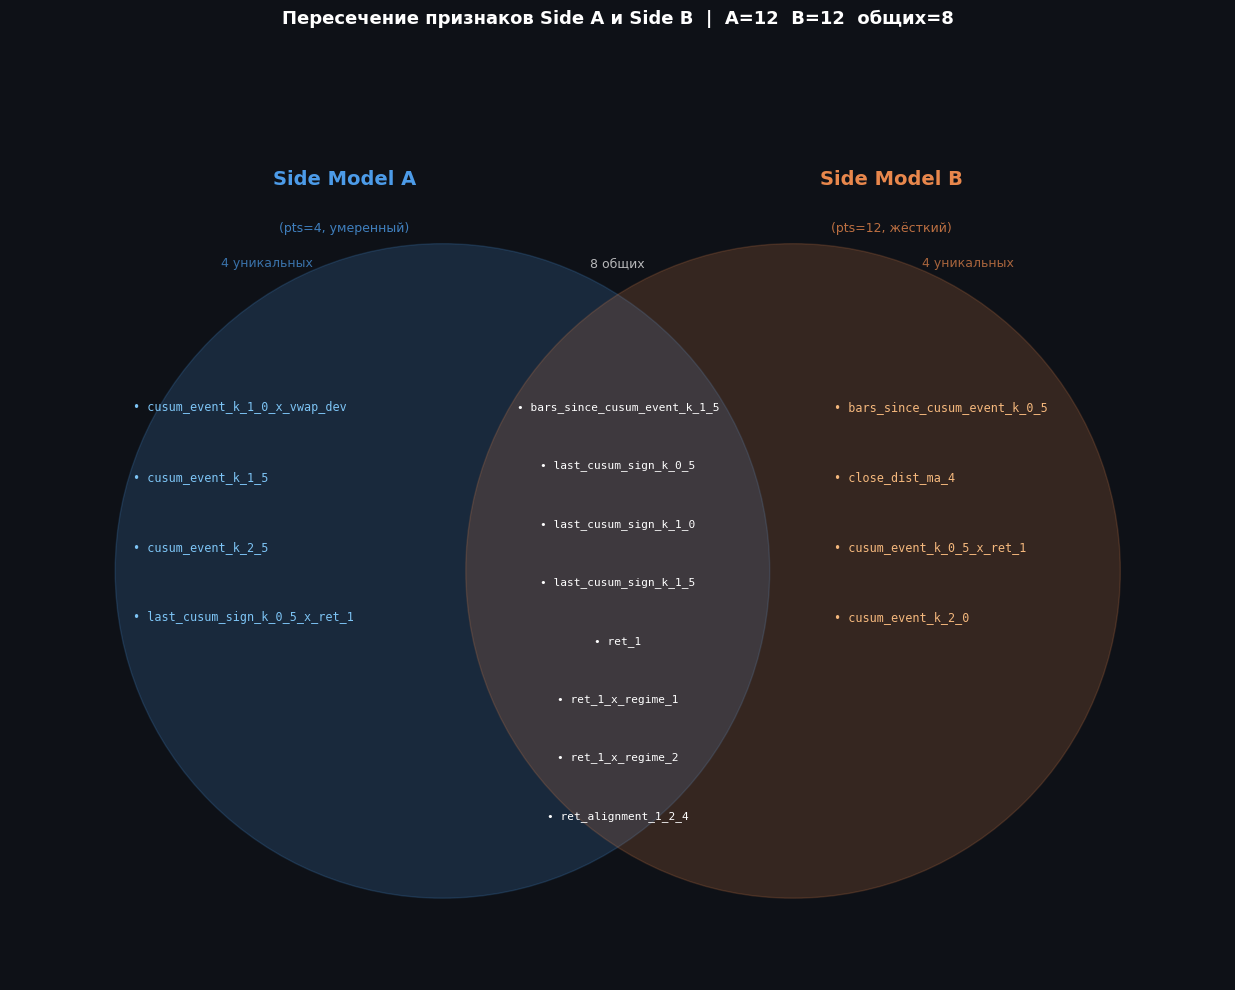

In [90]:

BG = "#0e1117"
fig, ax = plt.subplots(figsize=(18, 10))
fig.patch.set_facecolor(BG)
ax.set_facecolor(BG)

set_A  = set(result_A["final_features"])
set_B  = set(result_B["final_features"])
common = sorted(set_A & set_B)
only_A = sorted(set_A - set_B)
only_B = sorted(set_B - set_A)

# круги
cx_A, cx_B, cy, r = -1.5, 1.5, 0, 2.8
circle_A = Circle((cx_A, cy), r, alpha=0.18, color="#4C9BE8", zorder=1)
circle_B = Circle((cx_B, cy), r, alpha=0.18, color="#E8874C", zorder=1)
ax.add_patch(circle_A)
ax.add_patch(circle_B)

# подписи кругов сверху
ax.text(cx_A - r*0.3, cy + r + 0.5, "Side Model A",
        color="#4C9BE8", fontsize=14, fontweight="bold", ha="center")
ax.text(cx_A - r*0.3, cy + r + 0.1, "(pts=4, умеренный)",
        color="#4C9BE8", fontsize=9,  ha="center", alpha=0.8)

ax.text(cx_B + r*0.3, cy + r + 0.5, "Side Model B",
        color="#E8874C", fontsize=14, fontweight="bold", ha="center")
ax.text(cx_B + r*0.3, cy + r + 0.1, "(pts=12, жёсткий)",
        color="#E8874C", fontsize=9,  ha="center", alpha=0.8)

# счётчики зон
ax.text(cx_A - 1.5, cy + r - 0.2, f"{len(only_A)} уникальных",
        color="#4C9BE8", fontsize=9, ha="center", alpha=0.7)
ax.text(cx_B + 1.5, cy + r - 0.2, f"{len(only_B)} уникальных",
        color="#E8874C", fontsize=9, ha="center", alpha=0.7)
ax.text(0, cy + r - 0.2, f"{len(common)} общих",
        color="white", fontsize=9, ha="center", alpha=0.7)

# только A — левая зона, выровнены по левому краю
x_A = cx_A - r + 0.15
y_start = cy + 1.4
for i, feat in enumerate(only_A):
    ax.text(x_A, y_start - i * 0.6, f"• {feat}",
            color="#7DC4F5", fontsize=8.5, ha="left", va="center",
            fontfamily="monospace")

# общие — строго по центру
x_C = 0.0
for i, feat in enumerate(common):
    ax.text(x_C, y_start - i * 0.5, f"• {feat}",
            color="white", fontsize=8, ha="center", va="center",
            fontfamily="monospace")

# только B — правая зона, выровнены по левому краю относительно центра B
x_B = cx_B + 0.35
for i, feat in enumerate(only_B):
    ax.text(x_B, y_start - i * 0.6, f"• {feat}",
            color="#F5B87D", fontsize=8.5, ha="left", va="center",
            fontfamily="monospace")

ax.set_xlim(-5.2, 5.2)
ax.set_ylim(-3.5, 4.5)
ax.set_aspect("equal")
ax.axis("off")
ax.set_title(
    f"Пересечение признаков Side A и Side B  |  "
    f"A={len(set_A)}  B={len(set_B)}  общих={len(common)}",
    color="white", fontsize=13, fontweight="bold", pad=15
)

plt.tight_layout()
plt.show()


## Выводы по признакам Side моделей

**8 из 12 признаков совпадают** — обе модели независимо пришли к одному ядру сигналов. Это сильное подтверждение что признаки несут реальный предсказательный сигнал, а не шум конкретного таргета.

**Ядро общих признаков** — `ret_1`, `ret_alignment_1_2_4`, `ret_1_x_regime_1`, `ret_1_x_regime_2`, `last_cusum_sign_k_0_5`, `last_cusum_sign_k_1_0`, `last_cusum_sign_k_1_5`, `bars_since_cusum_event_k_1_5`. Это признаки краткосрочного моментума и текущего знака CUSUM — модели смотрят на направление последнего движения и его контекст в режиме рынка.

**Уникальные признаки Side A (умеренный)** — более агрессивные CUSUM взаимодействия (`cusum_event_k_1_0_x_vwap_dev`, `last_cusum_sign_k_0_5_x_ret_1`, `cusum_event_k_1_5`, `cusum_event_k_2_5`). Умеренный таргет требует дополнительных подтверждений через взаимодействие импульса с отклонением цены.

**Уникальные признаки Side B (жёсткий)** — `close_dist_ma_4`, `bars_since_cusum_event_k_0_5`, `cusum_event_k_0_5_x_ret_1`, `cusum_event_k_2_0`. Жёсткий таргет смотрит на положение цены относительно короткой MA и свежесть последнего события — движение должно начаться недавно и от правильного уровня.

# Обучение Side моделей

### Что делаем

Обучаем две side модели на финальных признаках отобранных через Clustered Feature Importance. Каждая модель получает свой набор признаков и свой таргет — pipeline запускается независимо для каждой.

### Архитектура

Та же что и в trade модели — `BaggingClassifier` с `RandomForestClassifier(n_estimators=1)` внутри. Sequential bootstrap по де Прадо: каждый из 300 Bagging итераторов строит одно дерево на подвыборке размером `avgU × N`.

```python
BaggingClassifier(
    estimator    = RandomForestClassifier(n_estimators=1, ...),
    n_estimators = 300,
    max_samples  = avgU,   # среднее число независимых наблюдений
)
```

### Валидация

Фолды пересобираются внутри каждой модели под её выборку — trade zone разного размера для A и B. Walk-Forward Purged CV с 5 фолдами, embargo и purge на каждом фолде.

Последний фолд (F5) — самый честный: модель обучена на ранней истории, тестируется на свежих данных которые никогда не видела.

### Что измеряем

**F1 weighted** — качество бинарного решения с учётом баланса классов. **ROC-AUC** — разделяющая способность вероятностей. **Separation** — разница средних вероятностей между классами, ключевая метрика для использования модели как scorer при подборе порога на бэктестинге.


ОБУЧЕНИЕ — Side Model A (pts=4, умеренный)
Признаков: 12  N: 38,779  y=1: 52.9%
Фолдов: 5
  F1: train=7,555  test=4,847
  F2: train=14,123  test=4,847
  F3: train=20,744  test=4,847
  F4: train=27,328  test=4,847
  F5: train=33,916  test=4,847

  Fold 1: F1=0.5997  AUC=0.6240  
  Fold 2: F1=0.5912  AUC=0.6271  
  Fold 3: F1=0.5981  AUC=0.6230  
  Fold 4: F1=0.5795  AUC=0.6209  
  Fold 5: F1=0.5918  AUC=0.6292  ← OOS

CV F1:      0.5920 ± 0.0071
CV AUC:     0.6248 ± 0.0029
Separation: 0.0875


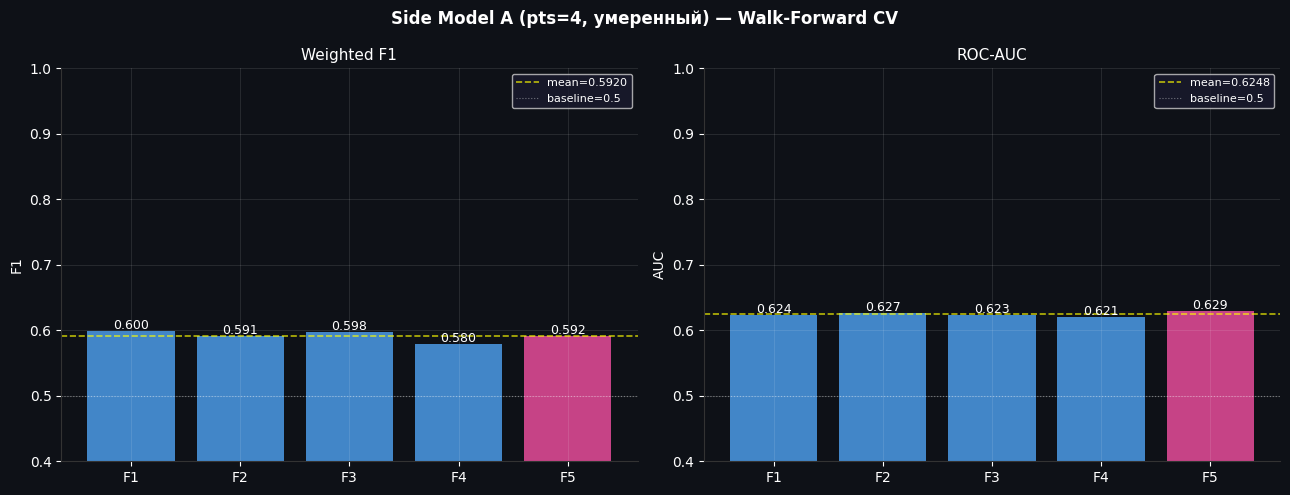


ОБУЧЕНИЕ — Side Model B (pts=12, жёсткий)
Признаков: 12  N: 25,050  y=1: 53.1%
Фолдов: 5
  F1: train=4,870  test=3,131
  F2: train=9,131  test=3,131
  F3: train=13,393  test=3,131
  F4: train=17,646  test=3,131
  F5: train=21,891  test=3,131

  Fold 1: F1=0.7084  AUC=0.7715  
  Fold 2: F1=0.7219  AUC=0.7825  
  Fold 3: F1=0.7107  AUC=0.7636  
  Fold 4: F1=0.6872  AUC=0.7466  
  Fold 5: F1=0.6926  AUC=0.7634  ← OOS

CV F1:      0.7042 ± 0.0126
CV AUC:     0.7655 ± 0.0118
Separation: 0.2426


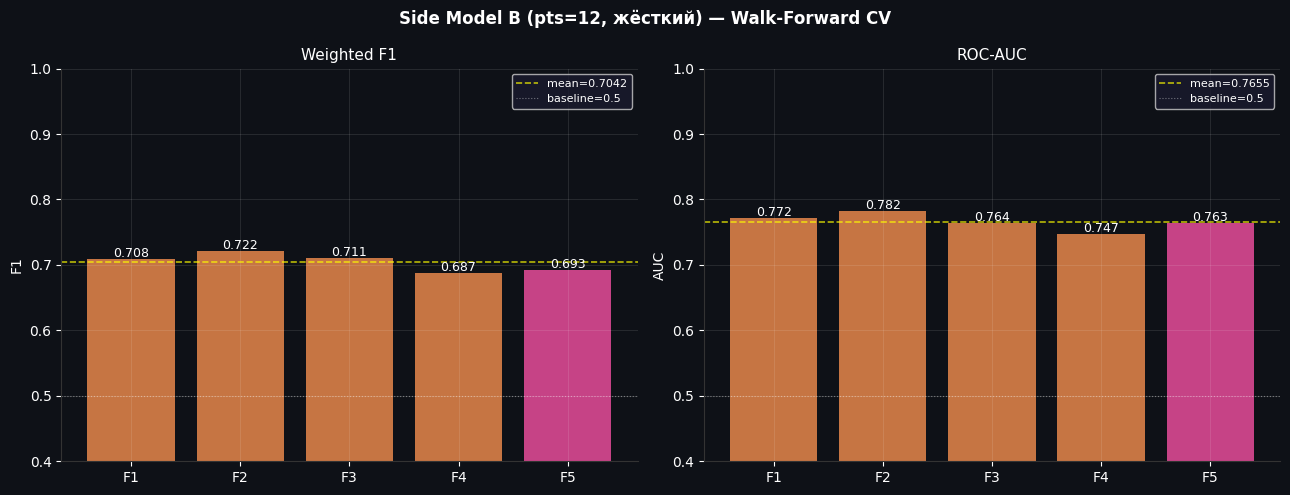

In [92]:

def train_side_model(result: dict, label: str):
    print(f"\n{'='*65}")
    print(f"ОБУЧЕНИЕ — {label}")
    print(f"{'='*65}")

    feats = result["final_features"]
    y_    = result["y"]
    w_    = result["w"]
    X_    = result["X"][feats].replace([np.inf, -np.inf], np.nan).fillna(0).astype(np.float32)

    print(f"Признаков: {len(feats)}  N: {len(y_):,}  y=1: {y_.mean()*100:.1f}%")

    cv_side = WalkForwardPurgedCV(
        n_splits      = 5,
        min_train_pct = 0.15,
        test_pct      = 1/8,
        pct_embargo   = 0.005,
    )

    t1_side = pd.Series(
        (pd.to_datetime(X_.index) + pd.Timedelta(hours=12)).values,
        index=X_.index
    )

    folds_side = [{"train_idx": tr, "test_idx": te}
                  for tr, te in cv_side.split(X_, t1=t1_side)]

    print(f"Фолдов: {len(folds_side)}")
    for i, f in enumerate(folds_side):
        print(f"  F{i+1}: train={len(f['train_idx']):,}  test={len(f['test_idx']):,}")

    rf_base = RandomForestClassifier(
        n_estimators  = 1,
        criterion     = "entropy",
        max_features  = "sqrt",
        bootstrap     = False,
        class_weight  = "balanced_subsample",
        n_jobs        = 1,
        random_state  = 42,
    )

    model = BaggingClassifier(
        estimator    = rf_base,
        n_estimators = 300,
        max_samples  = avgU,
        max_features = 1.0,
        random_state = 42,
        n_jobs       = -1,
    )

    f1_scores  = []
    auc_scores = []
    oof_proba  = np.full(len(y_), np.nan)

    Xv = X_.values
    yv = y_.values
    wv = w_.values

    print()
    for fold_i, fold in enumerate(folds_side):
        tr = fold["train_idx"]
        te = fold["test_idx"]

        model.fit(Xv[tr], yv[tr], sample_weight=wv[tr])

        proba         = model.predict_proba(Xv[te])[:, 1]
        pred          = (proba > 0.5).astype(int)
        oof_proba[te] = proba

        f1  = f1_score(yv[te],  pred,  average="weighted")
        auc = roc_auc_score(yv[te], proba)
        f1_scores.append(f1)
        auc_scores.append(auc)

        tag = "← OOS" if fold_i == len(folds_side) - 1 else ""
        print(f"  Fold {fold_i+1}: F1={f1:.4f}  AUC={auc:.4f}  {tag}")

    print(f"\nCV F1:      {np.mean(f1_scores):.4f} ± {np.std(f1_scores):.4f}")
    print(f"CV AUC:     {np.mean(auc_scores):.4f} ± {np.std(auc_scores):.4f}")

    valid_mask = ~np.isnan(oof_proba)
    sep = (oof_proba[valid_mask & (yv==1)].mean() -
           oof_proba[valid_mask & (yv==0)].mean())
    print(f"Separation: {sep:.4f}")

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    fig.patch.set_facecolor("#0e1117")
    fig.suptitle(f"{label} — Walk-Forward CV",
                 color="white", fontsize=12, fontweight="bold")

    fold_labels = [f"F{i+1}" for i in range(len(f1_scores))]
    color_main  = "#4C9BE8" if "A" in label else "#E8874C"

    for ax, scores, title, metric in [
        (axes[0], f1_scores,  "Weighted F1", "F1"),
        (axes[1], auc_scores, "ROC-AUC",     "AUC"),
    ]:
        ax.set_facecolor("#0e1117")
        colors = ["#E84C9B" if i == len(scores)-1 else color_main
                  for i in range(len(scores))]
        bars = ax.bar(fold_labels, scores, color=colors, alpha=0.85)
        ax.axhline(np.mean(scores), color="yellow", linewidth=1.2,
                   linestyle="--", alpha=0.7, label=f"mean={np.mean(scores):.4f}")
        ax.axhline(0.5, color="white", linewidth=0.8,
                   linestyle=":", alpha=0.4, label="baseline=0.5")
        for bar, v in zip(bars, scores):
            ax.text(bar.get_x() + bar.get_width()/2, v + 0.003,
                    f"{v:.3f}", ha="center", color="white", fontsize=9)
        ax.set_title(title, color="white", fontsize=11)
        ax.set_ylabel(metric, color="white")
        ax.tick_params(colors="white")
        ax.legend(facecolor="#1a1a2e", labelcolor="white", fontsize=8)
        ax.set_ylim(0.4, 1.0)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.spines["left"].set_color("#333")
        ax.spines["bottom"].set_color("#333")
        ax.grid(alpha=0.1, color="white")

    plt.tight_layout()
    plt.show()

    return {
        "model":       model,
        "features":    feats,
        "folds":       folds_side,
        "f1_scores":   f1_scores,
        "auc_scores":  auc_scores,
        "oof_proba":   oof_proba,
        "separation":  sep,
    }


model_A = train_side_model(result_A, "Side Model A (pts=4, умеренный)")
model_B = train_side_model(result_B, "Side Model B (pts=12, жёсткий)")


## Результаты обучения Side моделей

### Side Model A — "умеренный" (pts=4)

```
CV F1:      0.592 ± 0.007
CV AUC:     0.625 ± 0.003
Separation: 0.088
```

Слабый результат. AUC=0.625 — есть сигнал но слабый. Очень низкая дисперсия по фолдам (std=0.003) говорит о стабильности, но стабильно слабом результате. Separation 0.088 — вероятности для y=1 и y=0 почти не разделены.

---

### Side Model B — "жёсткий" (pts=12)

```
CV F1:      0.704 ± 0.013
CV AUC:     0.766 ± 0.012
Separation: 0.243
```

Существенно лучше. AUC=0.766 — модель реально разделяет классы. Separation 0.243 — вероятности для правильного и неправильного направления разделены на 24 процентных пункта. F1=0.704 при почти идеальном балансе классов 53%/47% — это честный результат.

---

### Сравнение

| Метрика | Model A (pts=4) | Model B (pts=12) |
|---------|----------------|-----------------|
| AUC | 0.625 | **0.766** |
| F1 | 0.592 | **0.704** |
| Separation | 0.088 | **0.243** |
| N сделок | 38,779 | 25,050 |

**Вывод:** жёсткий таргет выигрывает по всем метрикам с большим отрывом. Это подтверждает гипотезу — строгое требование persistence отсеивает шумные случаи и оставляет только те движения которые реально предсказуемы. Model A торгует чаще но хуже. Model B торгует реже но точнее. На бэктестинге скорее всего победит Model B — качество сигнала важнее частоты.

# Размер позиции через вероятность Side модели

### Идея

Side модель предсказывает не просто направление — она возвращает вероятность `p = P(LONG)`. Эта вероятность напрямую кодирует уверенность модели в сигнале. Чем дальше `p` от 0.5 тем увереннее модель — и тем больше должна быть позиция.

De Prado предлагает переводить вероятность в размер позиции через нормальное распределение:

```python
from scipy.stats import norm

def bet_size(p):
    z = (p - 0.5) / np.sqrt(p * (1 - p) + 1e-9)
    return 2 * norm.cdf(z) - 1   # ∈ [-1, +1]
```

```
p=0.35 → m=-0.20  SHORT умеренный
p=0.40 → m=-0.20  SHORT умеренный
p=0.55 → m=+0.10  LONG  слабый
p=0.65 → m=+0.20  LONG  умеренный
p=0.75 → m=+0.40  LONG  уверенный
p=0.85 → m=+0.70  LONG  сильный
```

---

### Почему отдельная size модель не нужна

Классический подход предполагает три отдельные модели: direction, side и size. Это избыточно по нескольким причинам.

**Вероятность уже содержит size.** Если модель говорит `p=0.85` — она не просто предсказывает LONG, она говорит что движение будет устойчивым с высокой уверенностью. Это и есть сигнал о силе движения.

**Меньше моделей — меньше overfitting.** Каждая дополнительная модель добавляет свой источник ошибки и требует отдельной валидации. В финансах каждая лишняя степень свободы увеличивает риск подгонки под историю.

**Side Model B (pts=12) особенно подходит.** Жёсткий таргет — цена выше open во всех 12 точках горизонта — естественно коррелирует с амплитудой движения. Если все 12 точек выше open значит движение не только есть но и сильное. Separation=0.243 говорит что вероятности хорошо откалиброваны.

---

### Pipeline в продакшне

```
Trade Model → P(trade) > threshold
                    ↓
         Side Model → p = P(LONG)
                    ↓
         bet_size(p) → m ∈ [-1, +1]
                    ↓
         позиция = m × max_position_size
```

Три модели заменяются двумя, размер позиции выводится аналитически из вероятности side модели.